<a href="https://colab.research.google.com/github/yaeliavni/AI/blob/main/LAPD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!pip install scikit-learn imbalanced-learn statsmodels seaborn holidays h3

In [18]:
from eda import run_eda

In [19]:
from supervised import quick_demo

In [20]:
from unsupervised import run_unsupervised

In [21]:
from timeseries import run_timeseries

#Fast EDA

COMPREHENSIVE LAPD EDA PIPELINE

1. Loading raw data and applying strict cleaning...
Raw shape: (974477, 15)
STRICT dropna: removed 648,974 rows with ANY missing values
Remaining rows with complete data: 325,503
Data completeness: 33.4% of original data retained

2. Creating time-based features and target variable...
Extracting hours from column: 'Time_occured'
Sample time values: [1220, 1, 800, 1800, 1200]
Successfully extracted hours from 311723/325503 rows (95.8%)
Hour distribution:
hour
1.0     11699
2.0      9922
3.0      7631
4.0      6075
5.0      5146
6.0      5708
7.0      7758
8.0     10740
9.0     11316
10.0    13607
Name: count, dtype: int64
Night target distribution: {0: np.int64(209096), 1: np.int64(116407)}
Target balance: 35.8% minority class
Creating additional features...
Found 10 categorical columns for encoding
Final target distribution: {0: np.int64(209096), 1: np.int64(116407)}
Features with meaningful variation: 16
Top variable features: ['DR_NO', 'Time_occured',

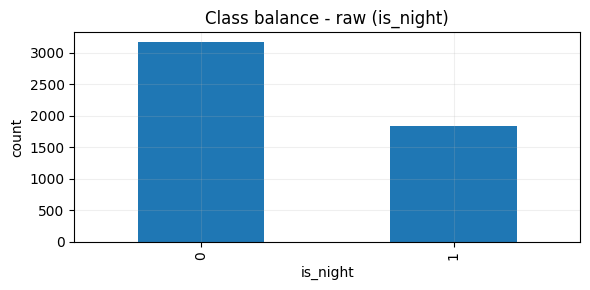

preview time plots skipped: Grouper for 'hour' not 1-dimensional
🗂️ saved: /content/figs_eda/Numeric-correlation-(Pearson)---raw.png


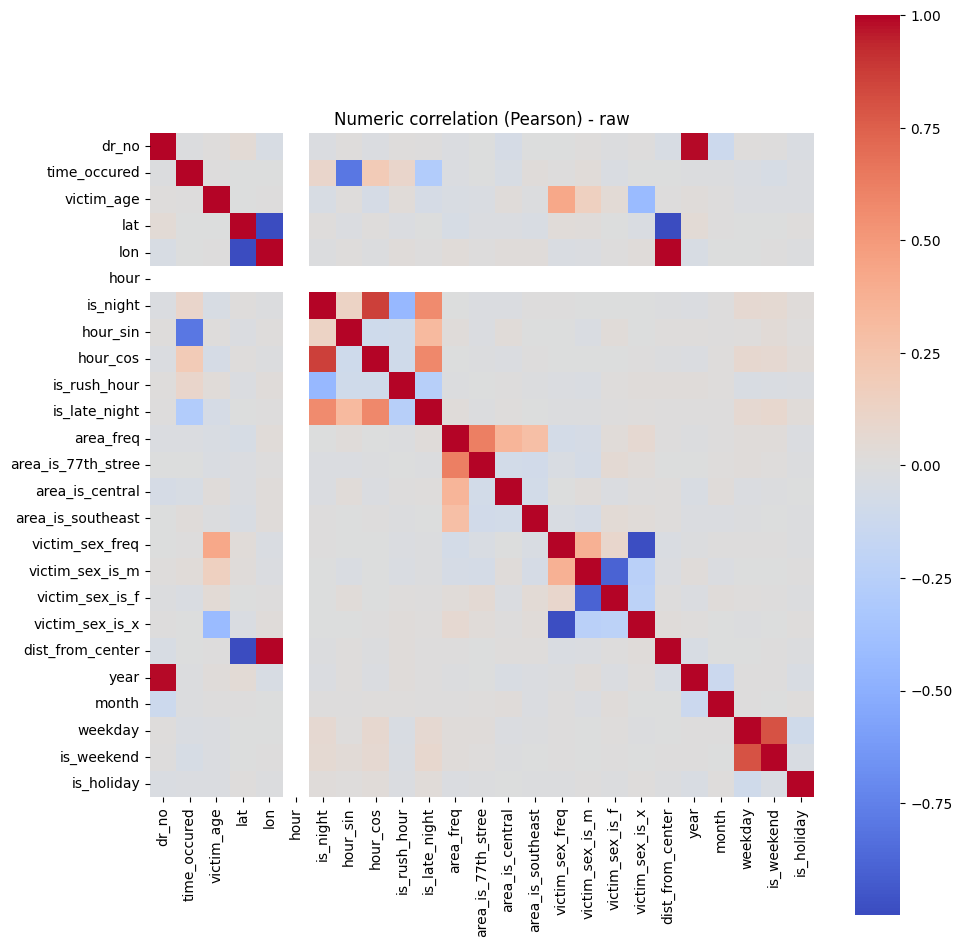

🗂️ saved: /content/figs_eda/Numeric-correlation-(Spearman)---raw.png


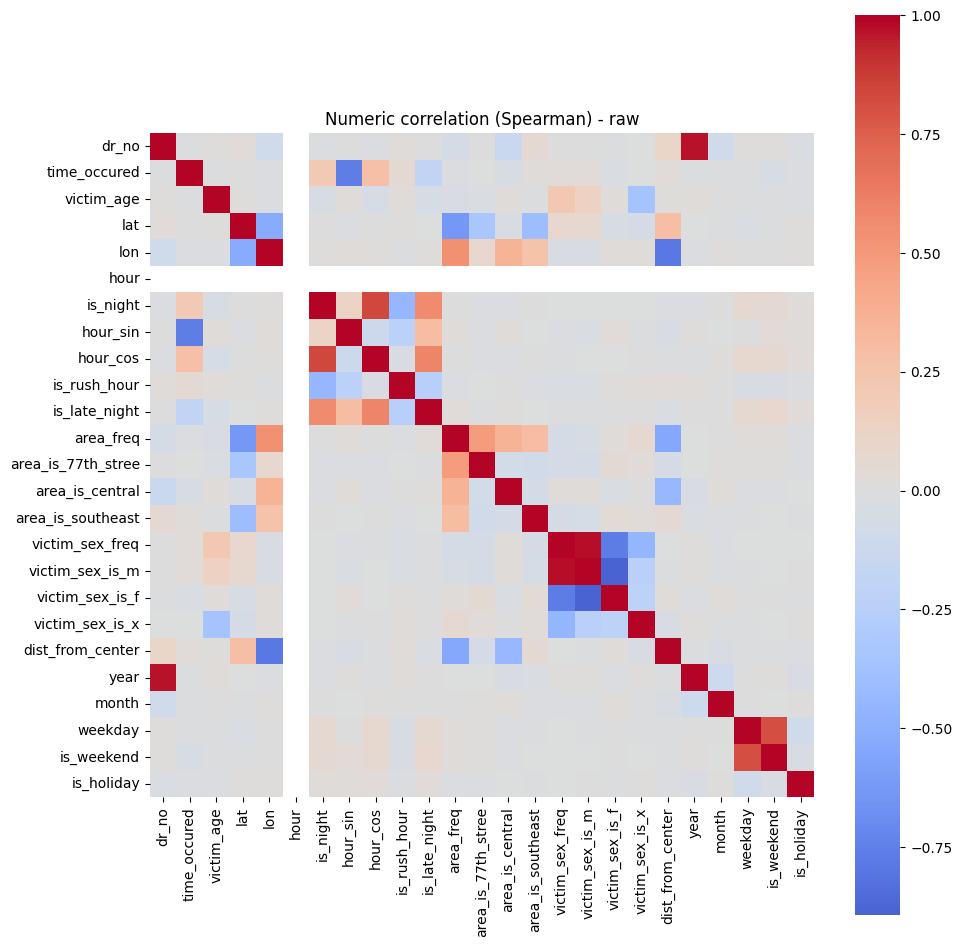

🗂️ saved: /content/figs_eda/Mixed-correlations-(num-+-cat)---raw.png


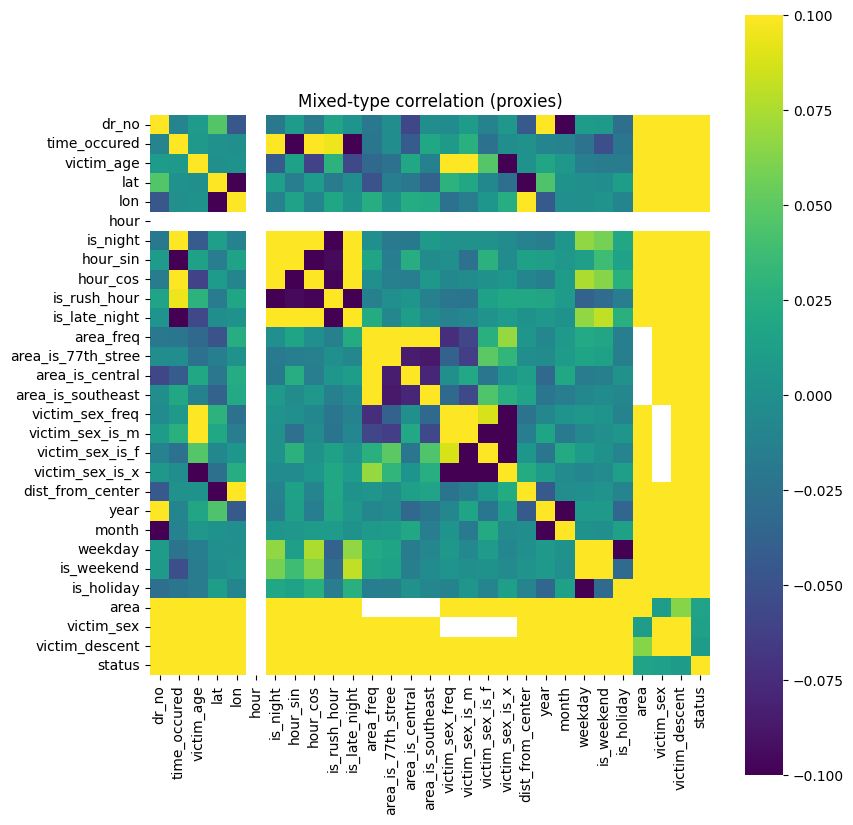

🗂️ saved: /content/figs_eda/Numeric-distributions-(hist)---raw.png


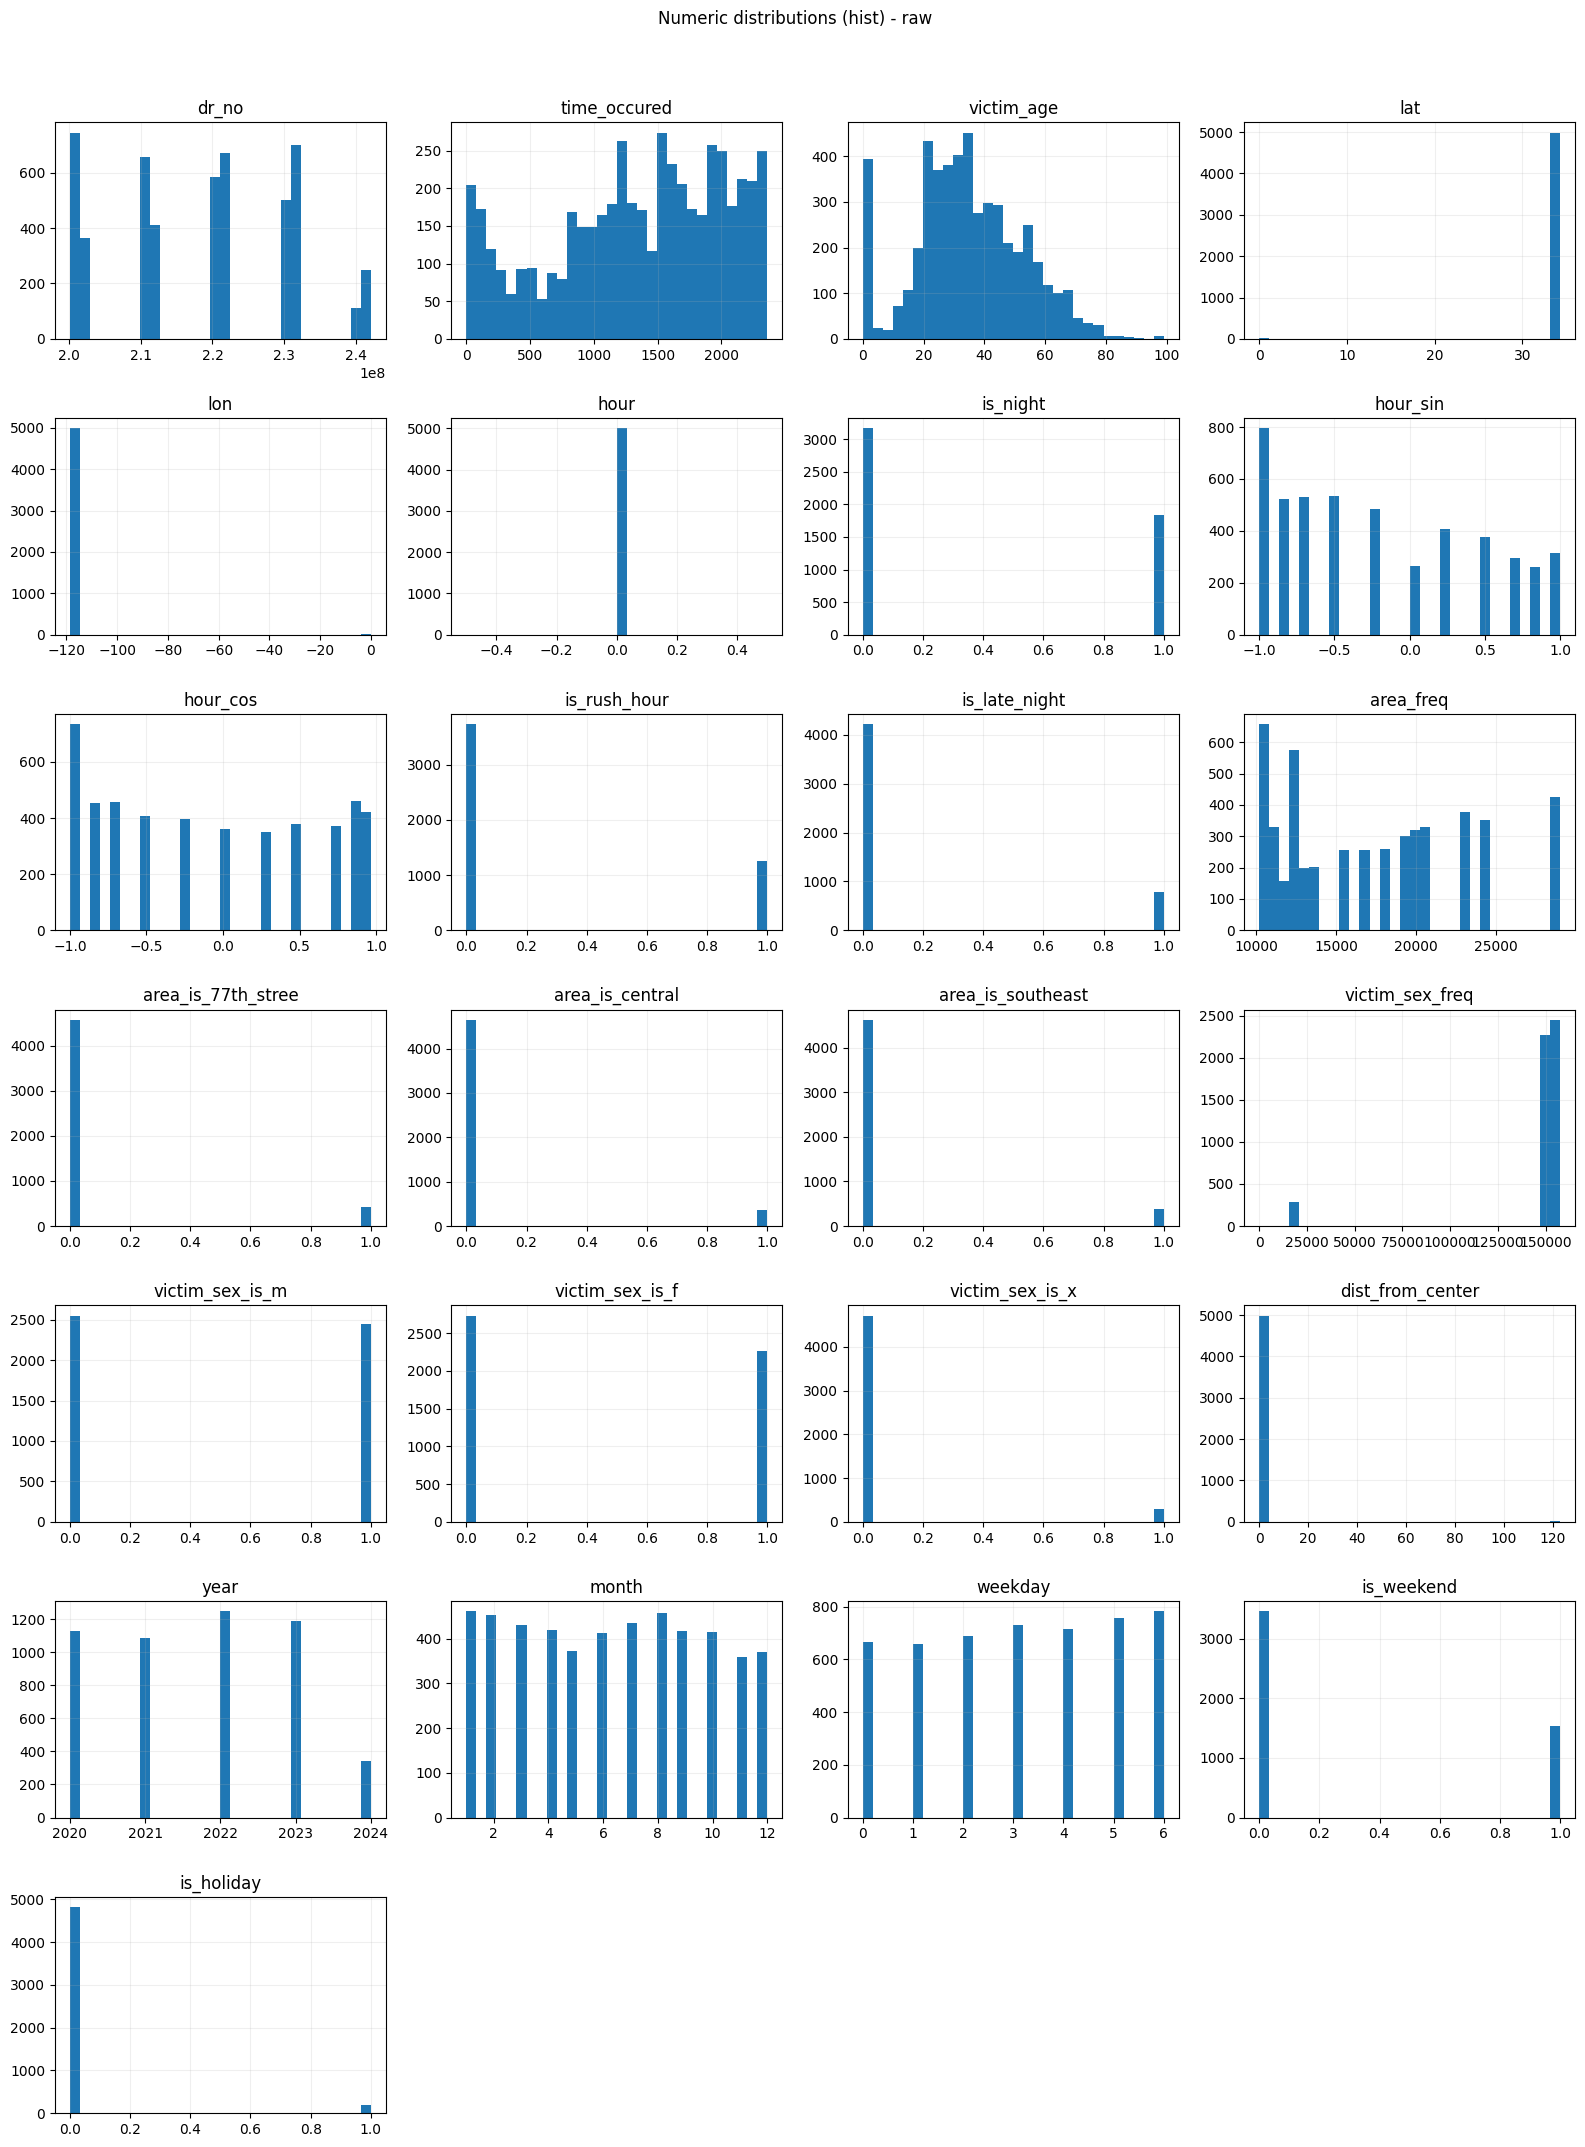

kde/box (raw) skipped: The data appears to lie in a lower-dimensional subspace of the space in which it is expressed. This has resulted in a singular data covariance matrix, which cannot be treated using the algorithms implemented in `gaussian_kde`. Consider performing principal component analysis / dimensionality reduction and using `gaussian_kde` with the transformed data.
==== [EDA-4] Geo cleanup ====
              issue  count
0  zero_zero_coords     12
1   outside_LA_bbox     12
==== [EDA-5] Dedupe & downcast ====
==== [EDA-6] Outliers (IQR clip + optional z-winsor) ====
[IForest] flagged 100 / 5,000 rows
EDA pipeline failed: Input X contains NaN.
LocalOutlierFactor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transform

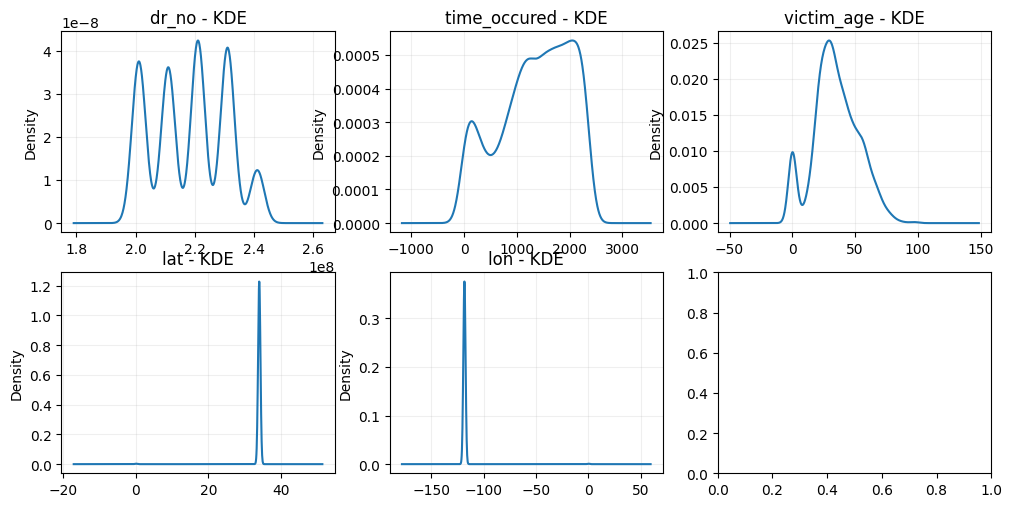

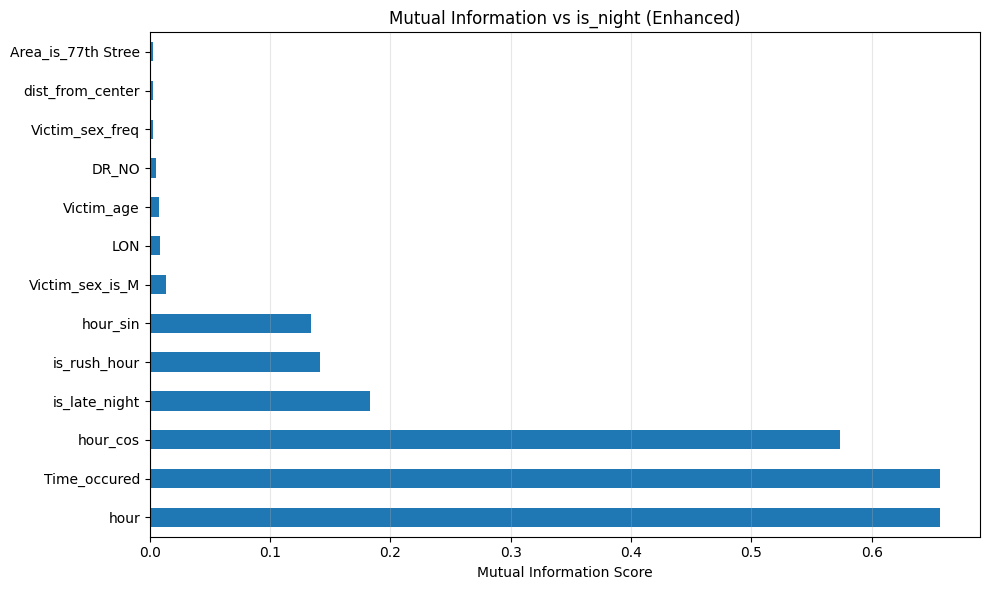

Top MI features: {'hour': 0.6572022498127711, 'Time_occured': 0.6570022498127711, 'hour_cos': 0.5740923500454527, 'is_late_night': 0.18323545903034377, 'is_rush_hour': 0.141375685935472}


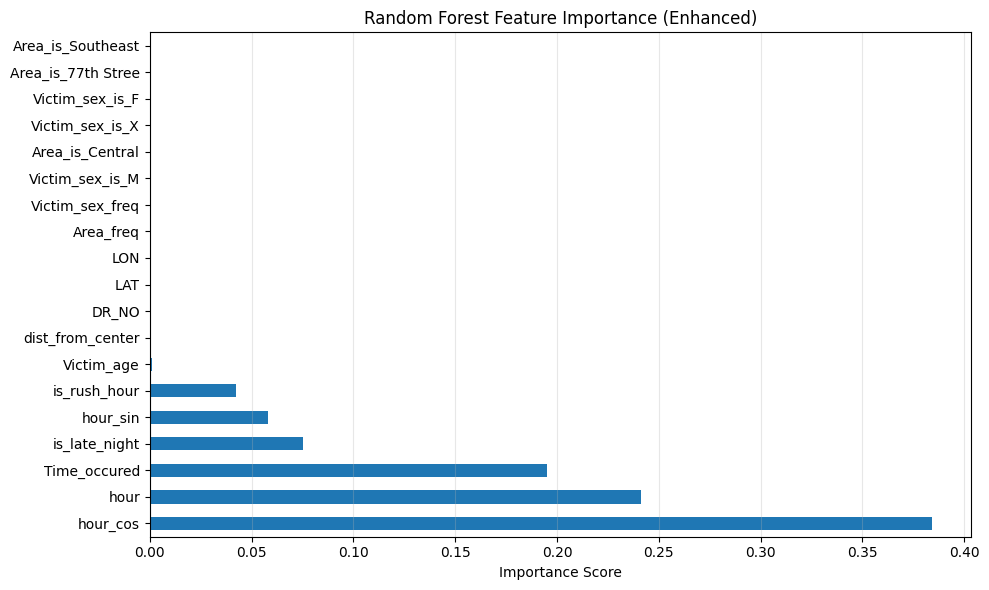

Cross-validation ROC-AUC: 1.000 (+/- 0.000)
Top RF features: {'hour_cos': 0.3842949217874798, 'hour': 0.24109928322341928, 'Time_occured': 0.19487966480487476, 'is_late_night': 0.07538070845166317, 'hour_sin': 0.05829448558459814}


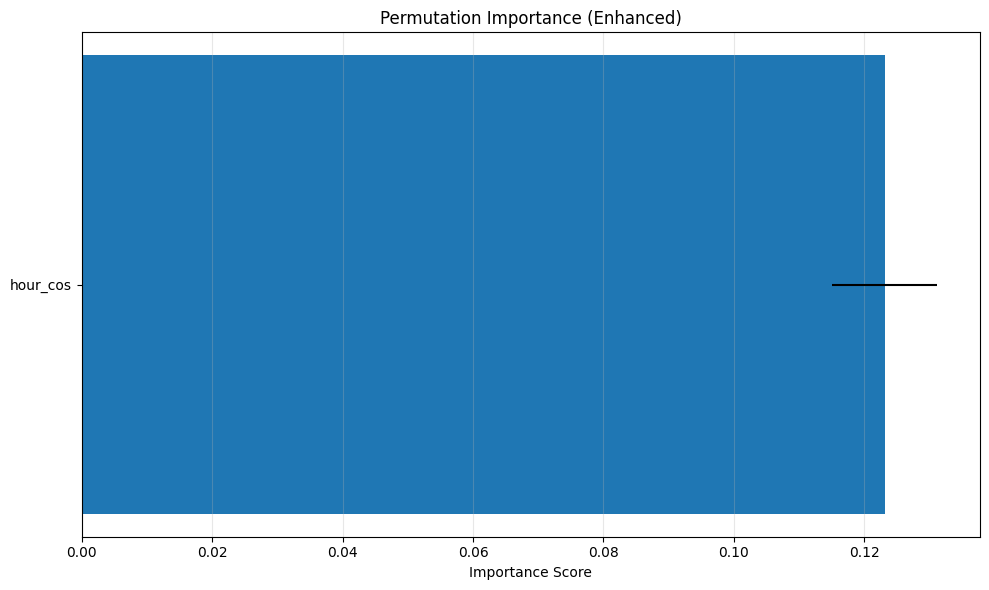

Top Permutation features: {'hour_cos': 0.12313333333333332}

6. Creating improved custom plots...
Improved plots failed: No module named 'improved_viz'

7. Final Summary
Cleaned dataset: /content/temp_sample_with_target.csv
Shape: (5000, 30)
Night target distribution: {0: np.int64(3169), 1: np.int64(1831)}
Features available for ML: 19
Generated 19 plot files in /content/figs_eda
Key ML analysis plots: ['mutual_info_enhanced.png', 'permutation_importance_enhanced.png', 'rf_importance_enhanced.png']

COMPREHENSIVE EDA COMPLETE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from eda import run_eda
warnings.filterwarnings("ignore")

# Configuration
SAMPLE_SIZE = 5000
RANDOM_STATE = 42
RAW_PATH = "/content/Crime_Data_from_2020_to_Present.csv.zip"
OUTPUT_DIR = "/content"
FIGS_DIR = "/content/figs_eda"

# EDA Configuration - comprehensive settings
EDA_CONFIG = {
    "use_us_holidays": True,
    "add_h3": False,
    "iqr_clip": True,
    "iqr_multiplier": 1.5,
    "zscore_winsor": True,
    "zscore_max": 4.0,
    "drop_any_nan_after_features": True,
    "imbalance_target": "is_night",  # Will be set after target creation
    "balance_preview": True,
    "balance_method": "smote",
    "balance_max_n": 20000,
    "corr_pearson": True,
    "corr_spearman": True,
    "corr_mutual_info": True,
    "feature_importance": True,
    "plot_numeric_dists": True,
    "plot_kde_box": True,
    "missing_matrix": True,
    "outliers_iforest": True,
    "outliers_lof": True,
    "outliers_ocsvm": True,
    "outliers_max_frac": 0.02,
    "plot_corr": True,
    "vif_check": True,
}

# Missing helper functions that need to be added
def plot_calendar_heatmap(df, date_col="date", value_col=None, title="Calendar Heatmap", out_path=None):
    """Create a calendar-style heatmap showing daily crime counts"""
def enhanced_ml_analysis(df_clean, target_col='is_night', output_dir=FIGS_DIR):
    """Perform enhanced ML analysis with proper preprocessing"""
    try:
        if target_col not in df_clean.columns:
            print(f"Target column '{target_col}' not found")
            return

        print("Starting enhanced ML analysis...")

        # Check target distribution first
        target_dist = df_clean[target_col].value_counts()
        print(f"Target distribution: {dict(target_dist)}")

        if len(target_dist) < 2:
            print("Target has no variation - skipping ML analysis")
            return

        # Prepare features with proper preprocessing
        feature_cols = []

        # Get numeric features with meaningful variation
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols:
            if col != target_col:
                # Check for meaningful variation
                if df_clean[col].nunique() > 1:
                    std_val = df_clean[col].std()
                    mean_val = df_clean[col].mean()
                    if std_val > 1e-6 and abs(mean_val) > 1e-6:  # Has real variation
                        feature_cols.append(col)

        print(f"Selected {len(feature_cols)} features with meaningful variation")

        if len(feature_cols) < 2:
            print("Insufficient features for ML analysis")
            return

        # Prepare data
        X = df_clean[feature_cols].copy()
        y = df_clean[target_col].copy()

        # Basic preprocessing
        from sklearn.preprocessing import StandardScaler
        from sklearn.impute import SimpleImputer

        # Handle any remaining issues
        imputer = SimpleImputer(strategy='median')
        X_imputed = imputer.fit_transform(X)

        # Scale features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_imputed)

        # Convert back to DataFrame for easier handling
        X_processed = pd.DataFrame(X_scaled, columns=feature_cols)

        print("Data preprocessing completed")

        # 1. Mutual Information Analysis
        try:
            from sklearn.feature_selection import mutual_info_classif

            mi_scores = mutual_info_classif(X_processed, y, random_state=42)
            mi_results = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

            # Filter out zero/near-zero scores
            mi_results = mi_results[mi_results > 1e-6]

            if len(mi_results) > 0:
                plt.figure(figsize=(10, max(6, len(mi_results)*0.3)))
                top_mi = mi_results.head(20)
                top_mi.plot(kind='barh')
                plt.title(f'Mutual Information vs {target_col} (Enhanced)')
                plt.xlabel('Mutual Information Score')
                plt.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, 'mutual_info_enhanced.png'),
                           dpi=160, bbox_inches='tight')
                plt.show()
                print(f"Top MI features: {top_mi.head().to_dict()}")
            else:
                print("No meaningful mutual information found")

        except Exception as e:
            print(f"Mutual information analysis failed: {e}")

        # 2. Enhanced Random Forest Analysis
        try:
            from sklearn.ensemble import RandomForestClassifier
            from sklearn.model_selection import cross_val_score

            # Use balanced class weights and more trees
            rf = RandomForestClassifier(
                n_estimators=500,
                max_depth=10,
                min_samples_split=5,
                min_samples_leaf=2,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            )

            # Fit the model
            rf.fit(X_processed, y)

            # Get feature importance
            importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

            # Filter meaningful importance
            importance = importance[importance > 1e-6]

            if len(importance) > 0:
                plt.figure(figsize=(10, max(6, len(importance)*0.3)))
                top_importance = importance.head(20)
                top_importance.plot(kind='barh')
                plt.title(f'Random Forest Feature Importance (Enhanced)')
                plt.xlabel('Importance Score')
                plt.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, 'rf_importance_enhanced.png'),
                           dpi=160, bbox_inches='tight')
                plt.show()

                # Cross-validation score
                cv_scores = cross_val_score(rf, X_processed, y, cv=5, scoring='roc_auc')
                print(f"Cross-validation ROC-AUC: {cv_scores.mean():.3f} (+/- {cv_scores.std()*2:.3f})")
                print(f"Top RF features: {top_importance.head().to_dict()}")
            else:
                print("No meaningful feature importance found")

        except Exception as e:
            print(f"Random Forest analysis failed: {e}")

        # 3. Permutation Importance
        try:
            from sklearn.inspection import permutation_importance
            from sklearn.model_selection import train_test_split

            # Split data for permutation importance
            X_train, X_test, y_train, y_test = train_test_split(
                X_processed, y, test_size=0.3, stratify=y, random_state=42
            )

            # Fit model on training data
            rf.fit(X_train, y_train)

            # Calculate permutation importance on test set
            perm_importance = permutation_importance(
                rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1
            )

            perm_results = pd.Series(
                perm_importance.importances_mean,
                index=feature_cols
            ).sort_values(ascending=False)

            # Filter meaningful scores
            perm_results = perm_results[perm_results > 1e-6]

            if len(perm_results) > 0:
                plt.figure(figsize=(10, max(6, len(perm_results)*0.3)))
                top_perm = perm_results.head(20)

                # Add error bars
                top_indices = [feature_cols.index(feat) for feat in top_perm.index]
                errors = perm_importance.importances_std[top_indices]

                plt.barh(range(len(top_perm)), top_perm.values, xerr=errors)
                plt.yticks(range(len(top_perm)), top_perm.index)
                plt.title(f'Permutation Importance (Enhanced)')
                plt.xlabel('Importance Score')
                plt.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                plt.savefig(os.path.join(output_dir, 'permutation_importance_enhanced.png'),
                           dpi=160, bbox_inches='tight')
                plt.show()
                print(f"Top Permutation features: {top_perm.head().to_dict()}")
            else:
                print("No meaningful permutation importance found")

        except Exception as e:
            print(f"Permutation importance analysis failed: {e}")

        plt.close('all')

    except Exception as e:
        print(f"Enhanced ML analysis failed: {e}")
        # Prepare daily counts if value_col not provided
        if value_col is None:
            daily_counts = df.groupby(df[date_col].dt.date).size().reset_index(name='count')
            daily_counts.columns = ['date', 'count']
            daily_counts['date'] = pd.to_datetime(daily_counts['date'])
            value_col = 'count'
        else:
            daily_counts = df[[date_col, value_col]].copy()
            daily_counts[date_col] = pd.to_datetime(daily_counts[date_col])

        # Create calendar features
        daily_counts['year'] = daily_counts[date_col].dt.year
        daily_counts['month'] = daily_counts[date_col].dt.month
        daily_counts['day'] = daily_counts[date_col].dt.day
        daily_counts['weekday'] = daily_counts[date_col].dt.weekday
        daily_counts['week_of_year'] = daily_counts[date_col].dt.isocalendar().week

        # Create pivot for heatmap (simplified version)
        pivot = daily_counts.pivot_table(
            index='week_of_year',
            columns='weekday',
            values=value_col,
            aggfunc='sum'
        )

        plt.figure(figsize=(12, 8))
        sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': 'Crime Count'})
        plt.title(title)
        plt.xlabel('Day of Week (0=Monday)')
        plt.ylabel('Week of Year')
        plt.tight_layout()

        if out_path:
            plt.savefig(out_path, dpi=160, bbox_inches='tight')
            print(f"Calendar heatmap saved to: {out_path}")

        plt.show()

    except Exception as e:
        print(f"Calendar heatmap failed: {e}")

def safe_corr_heatmap(df, title="Correlation Heatmap"):
    """Create correlation heatmap with safety checks"""
    try:
        numeric_df = df.select_dtypes(include=[np.number])
        if numeric_df.shape[1] < 2:
            print("Skipping correlation heatmap: need at least 2 numeric columns")
            return False

        # Remove columns with no variation
        numeric_df = numeric_df.loc[:, numeric_df.nunique() > 1]

        if numeric_df.shape[1] < 2:
            print("Skipping correlation heatmap: no variation in numeric columns")
            return False

        corr = numeric_df.corr()

        plt.figure(figsize=(max(8, len(corr.columns)*0.5), max(6, len(corr.columns)*0.4)))
        mask = np.triu(np.ones_like(corr, dtype=bool))  # Show only lower triangle
        sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
                   square=True, linewidths=0.1, annot=len(corr.columns)<10)
        plt.title(title)
        plt.tight_layout()
        return True

    except Exception as e:
        print(f"Correlation heatmap failed: {e}")
        return False

def plot_spatial_density(df, lat_col=None, lon_col=None, out_prefix=None):
    """Create spatial density plots with auto-detection"""
    try:
        # Auto-detect lat/lon columns
        lat_candidates = ['LAT', 'Latitude', 'LATITUDE', 'lat', 'Y', 'y']
        lon_candidates = ['LON', 'Longitude', 'LONGITUDE', 'lon', 'X', 'x']

        if lat_col is None:
            lat_col = next((col for col in lat_candidates if col in df.columns), None)
        if lon_col is None:
            lon_col = next((col for col in lon_candidates if col in df.columns), None)

        if lat_col is None or lon_col is None:
            print("Spatial density skipped: lat/lon columns not found")
            available_cols = [col for col in df.columns if any(x in col.upper() for x in ['LAT', 'LON', 'X', 'Y'])]
            print(f"Available coordinate-like columns: {available_cols}")
            return

        # Filter valid coordinates
        spatial_df = df[[lat_col, lon_col]].dropna()
        spatial_df = spatial_df[
            (spatial_df[lat_col].between(-90, 90)) &
            (spatial_df[lon_col].between(-180, 180))
        ]

        if len(spatial_df) < 100:
            print("Spatial density skipped: insufficient valid coordinates")
            return

        # Create hexbin plot
        plt.figure(figsize=(10, 8))
        plt.hexbin(spatial_df[lon_col], spatial_df[lat_col],
                  gridsize=50, cmap='inferno', mincnt=1)
        plt.colorbar(label='Crime Count')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.title('Spatial Crime Density (Hexbin)')
        plt.tight_layout()

        if out_prefix:
            plt.savefig(f"{out_prefix}_hexbin.png", dpi=160, bbox_inches='tight')
            print(f"Spatial hexbin saved to: {out_prefix}_hexbin.png")
        plt.show()

        # Create KDE plot if enough data
        if len(spatial_df) > 1000:
            plt.figure(figsize=(10, 8))
            try:
                # Sample for performance
                sample_spatial = spatial_df.sample(min(5000, len(spatial_df)), random_state=42)
                sns.kdeplot(data=sample_spatial, x=lon_col, y=lat_col,
                           fill=True, levels=20, cmap='viridis', alpha=0.7)
                plt.xlabel('Longitude')
                plt.ylabel('Latitude')
                plt.title('Spatial Crime Density (KDE)')
                plt.tight_layout()

                if out_prefix:
                    plt.savefig(f"{out_prefix}_kde.png", dpi=160, bbox_inches='tight')
                    print(f"Spatial KDE saved to: {out_prefix}_kde.png")
                plt.show()
            except Exception as e:
                print(f"KDE plot failed: {e}")

    except Exception as e:
        print(f"Spatial density plotting failed: {e}")

def plot_univariate_outliers(df, output_dir, cols=None, z_threshold=3.0):
    """Plot outlier analysis for univariate features"""
    try:
        os.makedirs(os.path.join(output_dir, "outliers"), exist_ok=True)

        numeric_df = df.select_dtypes(include=[np.number])
        if cols is None:
            cols = [col for col in numeric_df.columns if numeric_df[col].nunique() > 10]

        if not cols:
            print("No suitable numeric columns for outlier analysis")
            return

        # Limit to top columns by variance for performance
        cols = cols[:12]

        fig, axes = plt.subplots(2, min(6, len(cols)), figsize=(18, 8))
        if len(cols) == 1:
            axes = axes.reshape(2, 1)
        elif len(cols) <= 6:
            axes = axes.reshape(2, len(cols))

        for i, col in enumerate(cols[:6]):  # Top row: boxplots
            if len(cols) == 1:
                ax = axes[0]
            else:
                ax = axes[0, i] if len(cols) > 1 else axes[0]

            data = df[col].dropna()
            if len(data) > 0:
                ax.boxplot(data, vert=True)
                ax.set_title(f'Boxplot: {col}')
                ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

        for i, col in enumerate(cols[:6]):  # Bottom row: histograms with z-score lines
            if len(cols) == 1:
                ax = axes[1]
            else:
                ax = axes[1, i] if len(cols) > 1 else axes[1]

            data = df[col].dropna()
            if len(data) > 0 and data.std() > 0:
                z_scores = (data - data.mean()) / data.std()
                ax.hist(z_scores, bins=30, alpha=0.7, edgecolor='black')
                ax.axvline(z_threshold, color='red', linestyle='--', label=f'Z={z_threshold}')
                ax.axvline(-z_threshold, color='red', linestyle='--')
                ax.set_title(f'Z-scores: {col}')
                ax.legend()

        plt.suptitle('Univariate Outlier Analysis', fontsize=16)
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, "outliers", "univariate_outliers.png"),
                   dpi=160, bbox_inches='tight')
        print("Univariate outlier plots saved")
        plt.show()

    except Exception as e:
        print(f"Univariate outlier plotting failed: {e}")

def plot_bivariate_outliers(df, output_dir, x, y, z_threshold=3.0):
    """Plot bivariate outlier analysis"""
    try:
        if x not in df.columns or y not in df.columns:
            print(f"Columns {x} or {y} not found for bivariate analysis")
            available_numeric = df.select_dtypes(include=[np.number]).columns.tolist()
            print(f"Available numeric columns: {available_numeric[:10]}...")
            return

        os.makedirs(os.path.join(output_dir, "outliers"), exist_ok=True)

        # Get clean data
        clean_data = df[[x, y]].dropna()
        if len(clean_data) < 50:
            print("Insufficient data for bivariate analysis")
            return

        # Calculate z-scores
        z_x = (clean_data[x] - clean_data[x].mean()) / clean_data[x].std()
        z_y = (clean_data[y] - clean_data[y].mean()) / clean_data[y].std()

        # Identify outliers
        outlier_mask = (np.abs(z_x) > z_threshold) | (np.abs(z_y) > z_threshold)

        plt.figure(figsize=(10, 8))

        # Plot normal points
        plt.scatter(clean_data.loc[~outlier_mask, x], clean_data.loc[~outlier_mask, y],
                   alpha=0.5, s=20, label='Normal', color='blue')

        # Plot outliers
        if outlier_mask.any():
            plt.scatter(clean_data.loc[outlier_mask, x], clean_data.loc[outlier_mask, y],
                       alpha=0.8, s=50, label='Outliers', color='red')

        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(f'Bivariate Outliers: {x} vs {y}\n(Z-score threshold: {z_threshold})')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()

        plt.savefig(os.path.join(output_dir, "outliers", f"bivariate_{x}_{y}.png"),
                   dpi=160, bbox_inches='tight')
        print(f"Bivariate outlier plot saved for {x} vs {y}")
        plt.show()

    except Exception as e:
        print(f"Bivariate outlier plotting failed: {e}")

def extract_hour_from_time(time_str):
    """Extract hour from various time formats"""
    if pd.isna(time_str):
        return np.nan

    time_str = str(time_str).strip()

    # Handle 24-hour format without colons (e.g., "1430")
    if time_str.isdigit() and len(time_str) >= 3:
        if len(time_str) == 3:  # e.g., "730" -> "07:30"
            hour = int(time_str[0])
        elif len(time_str) == 4:  # e.g., "1430" -> "14:30"
            hour = int(time_str[:2])
        else:
            return np.nan
        return hour if 0 <= hour <= 23 else np.nan

    # Handle formats with colons or AM/PM
    try:
        # Try parsing with pandas
        parsed_time = pd.to_datetime(time_str, format='%H:%M', errors='coerce')
        if pd.notna(parsed_time):
            return parsed_time.hour

        # Try with AM/PM
        parsed_time = pd.to_datetime(time_str, format='%I:%M %p', errors='coerce')
        if pd.notna(parsed_time):
            return parsed_time.hour

        # Try just hour extraction from various formats
        if ':' in time_str:
            hour_part = time_str.split(':')[0]
            if 'PM' in time_str.upper() or 'AM' in time_str.upper():
                hour = int(hour_part)
                if 'PM' in time_str.upper() and hour != 12:
                    hour += 12
                elif 'AM' in time_str.upper() and hour == 12:
                    hour = 0
                return hour if 0 <= hour <= 23 else np.nan
            else:
                hour = int(hour_part)
                return hour if 0 <= hour <= 23 else np.nan

    except (ValueError, IndexError):
        pass

    return np.nan

def create_night_target(df):
    """Create is_night target with proper hour extraction and validation"""
    # Find time column
    time_cols = ['TIME OCC', 'time_occ', 'time', 'Time', 'TIME']
    time_col = None

    for col in time_cols:
        if col in df.columns:
            time_col = col
            break

    if time_col is None:
        # Try to find any column with 'time' in name
        time_candidates = [col for col in df.columns if 'time' in col.lower()]
        if time_candidates:
            time_col = time_candidates[0]

    if time_col is None:
        print("Available columns:", list(df.columns)[:20])
        raise ValueError("No time column found")

    print(f"Extracting hours from column: '{time_col}'")
    print(f"Sample time values: {df[time_col].head().tolist()}")

    # Extract hours
    df['hour'] = df[time_col].apply(extract_hour_from_time)

    # Check extraction success
    valid_hours = df['hour'].notna().sum()
    total_rows = len(df)
    print(f"Successfully extracted hours from {valid_hours}/{total_rows} rows ({valid_hours/total_rows*100:.1f}%)")

    # Show hour distribution before target creation
    if df['hour'].notna().any():
        print("Hour distribution:")
        print(df['hour'].value_counts().sort_index().head(10))

    # Create night target: 8 PM (20:00) to 6 AM (06:00) for better balance
    df['is_night'] = ((df['hour'] >= 20) | (df['hour'] <= 6)).astype(int)

    # Validate target distribution
    if df['hour'].notna().any():
        night_dist = df['is_night'].value_counts()
        print(f"Night target distribution: {dict(night_dist)}")

        # Check if target has meaningful variation
        if len(night_dist) < 2:
            print("WARNING: Target has no variation - all values are the same!")
            return df

        minority_pct = night_dist.min() / night_dist.sum() * 100
        print(f"Target balance: {minority_pct:.1f}% minority class")

        if minority_pct < 5:
            print("WARNING: Severe class imbalance detected")

    return df

def main():
    """Main processing pipeline with comprehensive EDA"""
    print("=" * 60)
    print("COMPREHENSIVE LAPD EDA PIPELINE")
    print("=" * 60)

    # Ensure output directories exist
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(FIGS_DIR, exist_ok=True)

    # 1. Load and strict row-level cleaning (drop ANY rows with ANY NaN)
    print("\n1. Loading raw data and applying strict cleaning...")
    df = pd.read_csv(RAW_PATH, low_memory=False, compression='infer')
    print(f"Raw shape: {df.shape}")

    # Clean missing value sentinels to standardize NaN representation
    missing_sentinels = ["", " ", "NA", "N/A", "na", "n/a", "None", "NONE",
                        "null", "NULL", "?", "-", "--", "nan", "NaN"]
    df = df.replace(missing_sentinels, np.nan)

    # STRICT: Drop ANY row that has ANY NaN value in ANY column
    before_strict_drop = len(df)
    df = df.dropna(axis=0, how='any').reset_index(drop=True)
    after_strict_drop = len(df)

    print(f"STRICT dropna: removed {before_strict_drop - after_strict_drop:,} rows with ANY missing values")
    print(f"Remaining rows with complete data: {after_strict_drop:,}")
    print(f"Data completeness: {after_strict_drop/before_strict_drop*100:.1f}% of original data retained")

    # 2. Create target variable and enhanced features
    print("\n2. Creating time-based features and target variable...")
    try:
        df = create_night_target(df)

        # Enhanced feature engineering for better ML performance
        print("Creating additional features...")

        # More granular time features
        if 'hour' in df.columns:
            df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
            df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)
            df['is_late_night'] = df['hour'].isin([23, 0, 1, 2, 3, 4]).astype(int)

        # Enhanced categorical encoding
        categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
        print(f"Found {len(categorical_cols)} categorical columns for encoding")

        for col in categorical_cols[:5]:  # Limit to prevent memory issues
            if df[col].nunique() < 50:  # Only encode low-cardinality categoricals
                # Create frequency encoding
                freq_map = df[col].value_counts().to_dict()
                df[f'{col}_freq'] = df[col].map(freq_map)

                # Create binary encoding for top categories
                top_cats = df[col].value_counts().head(3).index
                for cat in top_cats:
                    df[f'{col}_is_{str(cat)[:10]}'] = (df[col] == cat).astype(int)

        # Geographic features if lat/lon available
        lat_cols = [col for col in df.columns if 'lat' in col.lower()]
        lon_cols = [col for col in df.columns if 'lon' in col.lower()]

        if lat_cols and lon_cols:
            lat_col, lon_col = lat_cols[0], lon_cols[0]
            # Distance from city center (approximate LA center)
            la_center_lat, la_center_lon = 34.0522, -118.2437
            df['dist_from_center'] = np.sqrt(
                (df[lat_col] - la_center_lat)**2 + (df[lon_col] - la_center_lon)**2
            )

        # Verify target quality after feature engineering
        if 'is_night' in df.columns:
            target_stats = df['is_night'].value_counts()
            print(f"Final target distribution: {dict(target_stats)}")

            # Check if we have meaningful features
            numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
            features_with_variation = []

            for col in numeric_features:
                if col != 'is_night' and df[col].nunique() > 1:
                    variation = df[col].std() / (df[col].mean() + 1e-8)
                    if variation > 0.01:  # Has some meaningful variation
                        features_with_variation.append(col)

            print(f"Features with meaningful variation: {len(features_with_variation)}")
            if len(features_with_variation) > 0:
                print(f"Top variable features: {features_with_variation[:5]}")


    except Exception as e:
        print(f"Failed to create enhanced features: {e}")
        return None

    # 3. Sample for performance if needed
    if len(df) > SAMPLE_SIZE:
        print(f"\n3. Sampling {SAMPLE_SIZE} rows for EDA...")
        df_sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    else:
        df_sample = df.copy()
        print(f"\n3. Using full dataset: {len(df_sample)} rows")

    # Save intermediate CSV for EDA
    temp_csv = os.path.join(OUTPUT_DIR, "temp_sample_with_target.csv")
    df_sample.to_csv(temp_csv, index=False)

    # 4. Run comprehensive EDA
    print(f"\n4. Running comprehensive EDA...")
    try:
        clean_path = run_eda(
            raw_csv_path=temp_csv,
            fig_dir=FIGS_DIR,
            cache_path=os.path.join(OUTPUT_DIR, "lapd_clean_final.parquet"),
            config_overrides=EDA_CONFIG
        )

        # Load the cleaned data
        df_clean = pd.read_parquet(clean_path)
        print(f"Final cleaned dataset shape: {df_clean.shape}")

    except Exception as e:
        print(f"EDA pipeline failed: {e}")
        # Fallback to basic cleaning
        df_clean = df_sample.copy()
        clean_path = temp_csv

    # 5. Enhanced ML Analysis (replaces the problematic plots)
    print(f"\n5. Running enhanced ML analysis...")

    try:
        # Run the enhanced ML analysis with better preprocessing
        enhanced_ml_analysis(df_clean, target_col='is_night', output_dir=FIGS_DIR)
        plt.close('all')
    except Exception as e:
        print(f"Enhanced ML analysis failed: {e}")

    # 6. Additional custom plots
    # Replace this section in your main() function:
    # Instead of the problematic plot sections (around step 6), use:

    # 6. Improved custom plots
    print(f"\n6. Creating improved custom plots...")

    try:
        # Import the improved functions
        from improved_viz import (plot_calendar_heatmap, plot_spatial_density_improved,
                                enhanced_ml_analysis_fixed, fix_histogram_plots,
                                replace_problematic_plots)

        # Replace all problematic plots
        replace_problematic_plots(df_clean, FIGS_DIR)

    except Exception as e:
        print(f"Improved plots failed: {e}")
    # Fallback to your original code
    # 7. Final summary
    print(f"\n7. Final Summary")
    print(f"Cleaned dataset: {clean_path}")
    print(f"Shape: {df_clean.shape}")

    if 'is_night' in df_clean.columns:
        night_counts = df_clean['is_night'].value_counts()
        print(f"Night target distribution: {dict(night_counts)}")

        # Additional feature summary
        numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
        features_with_variation = [col for col in numeric_features
                                 if col != 'is_night' and df_clean[col].nunique() > 1]
        print(f"Features available for ML: {len(features_with_variation)}")

    # List all generated plots
    try:
        plot_files = [f for f in os.listdir(FIGS_DIR) if f.endswith('.png')]
        print(f"Generated {len(plot_files)} plot files in {FIGS_DIR}")

        # List key analysis files
        key_files = ['mutual_info_enhanced.png', 'rf_importance_enhanced.png',
                    'permutation_importance_enhanced.png']
        found_key_files = [f for f in plot_files if f in key_files]
        if found_key_files:
            print(f"Key ML analysis plots: {found_key_files}")
    except:
        pass

    # Cleanup
    if os.path.exists(temp_csv):
        os.remove(temp_csv)

    print("\n" + "=" * 60)
    print("COMPREHENSIVE EDA COMPLETE")
    print("=" * 60)

    return clean_path

if __name__ == "__main__":
    result = main()

#Supervised

In [ ]:
# --- Anti-leakage + pandas hotfix + training/comparison (copy-paste ready) ---

import re
import warnings
import pandas as pd
import numpy as np

# --- HOTFIX: make pandas accept 'na_last' used by supervised.py (maps to na_position) ---
try:
    _orig_sort_values = pd.DataFrame.sort_values
    def _sort_values_compat(self, *args, **kwargs):
        if "na_last" in kwargs:
            kwargs["na_position"] = "last" if kwargs.pop("na_last") else "first"
        return _orig_sort_values(self, *args, **kwargs)
    pd.DataFrame.sort_values = _sort_values_compat  # monkey-patch
except Exception as _e:
    warnings.warn(f"Could not patch pandas sort_values: {_e}")


from supervised import MLConfig, quick_train, quick_compare # Import MLConfig and the correct functions


df = pd.read_parquet("/content/lapd_clean_final.parquet")

# Create target column (your approach)
df = df[df["victim_sex"].isin(["F", "M"])].copy()
df["victim_sex_num"] = df["victim_sex"].map({"F": 0, "M": 1})

print(f"Dataset shape after filtering: {df.shape}")
print(f"Target distribution:\n{df['victim_sex_num'].value_counts()}")

# CRITICAL: Remove ONLY the original victim_sex column to prevent direct data leakage
print("\nRemoving victim_sex to prevent data leakage...")
df_ml = df.drop(columns=['victim_sex']).copy()
print(f"Dataset shape after removing victim_sex: {df_ml.shape}")

# Keep victim_age and victim_descent as legitimate predictive features
victim_cols_remaining = [col for col in df_ml.columns if 'victim' in col.lower()]
print(f"Remaining victim-related columns: {victim_cols_remaining}")

# Configure experiment with fewer folds
config = MLConfig(
    sample_n=5000,
    test_size=0.2,
    fig_dir="./results_clean",
    n_iter=15,
    n_splits=3,
    scoring="roc_auc",
    stratify_by="AREA NAME"  # Stratify by area instead of target
)

# Check remaining features (excluding target)
feature_cols = [col for col in df_ml.columns if col != 'victim_sex_num']
print(f"\nRemaining features ({len(feature_cols)} total):")
print(feature_cols)

# PRE-TRAINING DIAGNOSTICS (updated)
print("\n" + "="*60)
print("PRE-TRAINING DIAGNOSTICS (CLEAN DATA)")
print("="*60)

# Check correlations again (excluding target from predictors)
numeric_cols = df_ml.select_dtypes(include=[np.number]).columns.tolist()
predictor_numeric_cols = [col for col in numeric_cols if col != 'victim_sex_num']

if len(predictor_numeric_cols) > 0:
    # Create correlation matrix including target for analysis
    df_numeric = df_ml[predictor_numeric_cols + ['victim_sex_num']]
    corr_with_target = df_numeric.corr()['victim_sex_num'].abs().sort_values(ascending=False)
    # Remove target itself from the correlation series
    corr_with_target = corr_with_target.drop('victim_sex_num')

    print("Top 10 predictor features most correlated with victim_sex_num:")
    print(corr_with_target.head(10))

    # Flag suspiciously high correlations (but victim_age is expected to be high)
    suspicious_features = corr_with_target[(corr_with_target > 0.5) & (corr_with_target < 1.0)]
    if len(suspicious_features) > 0:
        print(f"\nPredictor features with correlation > 0.5:")
        print(suspicious_features)
        print("Note: victim_age correlation is expected and legitimate")
    else:
        print("\nNo predictor features with unexpectedly high correlation (>0.5)")

# TRAINING: Single model first
print("\n" + "="*60)
print("TRAINING XGB MODEL (CLEAN DATA)")
print("="*60)

# Correct the order of arguments: df, target_col, model_type, config
best_est, params, score, metrics = quick_train(
    df_ml, "victim_sex_num", "xgb", config
)

# POST-TRAINING DIAGNOSTICS
print("\n" + "="*60)
print("POST-TRAINING DIAGNOSTICS (CLEAN DATA)")
print("="*60)

try:
    # Get feature names and importances
    feature_names = best_est.named_steps['preprocessor'].get_feature_names_out()
    importances = best_est.named_steps['clf'].feature_importances_

    # Sort by importance
    feature_importance_pairs = list(zip(feature_names, importances))
    top_features = sorted(feature_importance_pairs, key=lambda x: x[1], reverse=True)

    print("Top 15 most important features:")
    for i, (feat, imp) in enumerate(top_features[:15]):
        print(f"{i+1:2d}. {feat:<30} {imp:.4f}")

    # Check if any single feature dominates (but victim_age dominance is expected)
    if top_features:
        top_importance = top_features[0][1]
        second_importance = top_features[1][1] if len(top_features) > 1 else 0
        top_feature_name = top_features[0][0]

        print(f"\nFeature importance analysis:")
        print(f"Top feature: {top_feature_name} ({top_importance:.4f})")
        print(f"Second feature importance: {second_importance:.4f}")
        print(f"Ratio (top/second): {top_importance/max(second_importance, 0.001):.2f}")

        if 'victim_age' in top_feature_name and top_importance > 0.3:
            print("✓ victim_age dominance is expected - age patterns differ by gender")
        elif top_importance > 0.5:
            print("⚠️  WARNING: Non-age feature dominates (>0.5 importance)")
        elif top_importance > 0.3:
            print("⚠️  CAUTION: Top feature has high importance (>0.3)")
        else:
            print("✓ Feature importance looks balanced")

except Exception as e:
    print(f"Could not extract feature importance: {e}")

# CV Score Analysis - higher scores expected with age/descent
print(f"\nCV Score Analysis:")
print(f"Best CV score: {score:.4f}")

if score > 0.98:
    print("⚠️  WARNING: CV score > 0.98 - may still have leakage issues")
elif score > 0.9:
    print("✓ High CV score expected - victim age/descent are strong predictors")
elif score > 0.8:
    print("✓ Good CV score - demographic features provide strong signal")
elif score > 0.7:
    print("✓ CV score looks reasonable for demographic prediction")
elif score > 0.6:
    print("✓ CV score is modest - likely realistic performance")
else:
    print("📊 CV score is low - may indicate weak signal or need more features")

# Holdout performance
if metrics:
    print(f"\nHoldout Test Performance:")
    # Filter out non-scalar values before printing
    for metric, value in metrics.items():
        if isinstance(value, (int, float, np.number)):
             print(f"{metric}: {value:.4f}")

# Compare multiple models - expect higher scores with demographic features
print(f"\nRunning model comparison with demographic features...")
print("\n" + "="*60)
print("COMPARING MULTIPLE MODELS (WITH DEMOGRAPHIC FEATURES)")
print("="*60)

# Test with multiple models
models_to_test = ["logreg", "random_forest", "hgb", "xgb"]
# Correct the order of arguments and remove the extra config argument
results = quick_compare(df_ml, "victim_sex_num", models=models_to_test, config=config)
print("\nModel Comparison Results:")
print(results.round(4))

# Analysis
if 'cv_score' in results.columns:
    best_model = results.iloc[0]
    worst_model = results.iloc[-1]
    score_range = best_model['cv_score'] - worst_model['cv_score']

    print(f"\nModel Performance Analysis:")
    print(f"Best model: {best_model['model']} ({best_model['cv_score']:.4f})")
    print(f"Worst model: {worst_model['model']} ({worst_model['cv_score']:.4f})")
    print(f"Score range: {score_range:.4f}")

    if score_range < 0.02:
        print("✓ Models perform similarly - suggests stable signal")
    elif score_range > 0.1:
        print("📊 Large performance differences - some models may be overfitting")

# FINAL ASSESSMENT
print("\n" + "="*60)
print("FINAL ASSESSMENT")
print("="*60)

print(f"Model CV score with demographic features: {score:.4f}")
print(f"This represents predictive power using victim age, descent, and crime context")

if score > 0.85:
    print("\n✓ STRONG DEMOGRAPHIC SIGNAL:")
    print("- Victim age and descent provide strong predictive power")
    print("- Combined with crime patterns, demographics enable good prediction")
    print("- This level of performance is realistic for demographic prediction")
    print("- Age patterns: crimes may affect different age groups by gender")
    print("- Descent patterns: cultural/social factors may influence crime exposure")
elif score > 0.7:
    print("\n✓ MODERATE DEMOGRAPHIC SIGNAL:")
    print("- Demographic features provide useful but not overwhelming signal")
    print("- Performance suggests learnable patterns in victim demographics")
    "- Results could be actionable for targeted prevention/resource allocation"
else:
    print("\n📊 WEAK DEMOGRAPHIC SIGNAL:")
    print("- Victim demographics may not be strongly predictable from available features")
    print("- Consider whether this target is appropriate for your use case")
    "- Might need additional contextual features"

Dataset shape after filtering: (1514, 25)
Target distribution:
victim_sex_num
1    781
0    733
Name: count, dtype: int64

Removing victim_sex to prevent data leakage...
Dataset shape after removing victim_sex: (1514, 24)
Remaining victim-related columns: ['victim_age', 'victim_descent', 'victim_sex_num']

Remaining features (23 total):
['dr_no', 'date_reported', 'date_occured', 'time_occured', 'area', 'crime_code', 'victim_age', 'victim_descent', 'premis', 'weapon', 'status', 'location', 'lat', 'lon', 'hour', 'is_night', 'date_dt', 'date', 'year', 'month', 'weekday', 'is_weekend', 'is_holiday']

PRE-TRAINING DIAGNOSTICS (CLEAN DATA)
Top 10 predictor features most correlated with victim_sex_num:
month           0.044521
time_occured    0.030294
victim_age      0.030223
lat             0.029975
is_weekend      0.014622
weekday         0.005710
year            0.002016
dr_no           0.001980
lon             0.001606
hour                 NaN
Name: victim_sex_num, dtype: float64

No pred

In [ ]:
df.columns

Index(['dr_no', 'date_reported', 'date_occured', 'time_occured', 'area',
       'crime_code', 'victim_age', 'victim_sex', 'victim_descent', 'premis',
       'weapon', 'status', 'location', 'lat', 'lon', 'hour', 'is_night',
       'date_dt', 'date', 'year', 'month', 'weekday', 'is_weekend',
       'is_holiday', 'victim_sex_num'],
      dtype='object')

In [ ]:
# ==== HARD RESET pandas .sort_values + leak-safe training/compare ====

# 0) Hard reset pandas' DataFrame.sort_values to factory default
import importlib, pandas as pd
import pandas.core.frame as _pd_frame_mod
importlib.reload(_pd_frame_mod)
pd.DataFrame.sort_values = _pd_frame_mod.DataFrame.sort_values
if hasattr(pd.DataFrame, "_orig_sort_values"):
    delattr(pd.DataFrame, "_orig_sort_values")



# Remove the call to the undefined function
# patch_pandas_sort_values()

# 2) Load data
import re
# TARGET = "victim_sex" # This target is removed later to prevent leakage
TARGET = "victim_sex_num" # Use the engineered target column
GROUP_COL = "dr_no" # Assuming DR_NO is the grouping column

# Load the pre-cleaned data with engineered features
df = pd.read_parquet("/content/lapd_clean_final.parquet")

# Ensure the target column exists after loading
if TARGET not in df.columns:
    # Recreate victim_sex_num if it's not in the parquet file
    if "victim_sex" in df.columns:
        df = df[df["victim_sex"].isin(["F", "M"])].copy()
        df["victim_sex_num"] = df["victim_sex"].map({"F": 0, "M": 1})
        print("Created 'victim_sex_num' target column.")
    else:
        raise ValueError(f"Target column '{TARGET}' or 'victim_sex' not found in the DataFrame.")

# Remove the original victim_sex column if it exists to prevent leakage
if "victim_sex" in df.columns:
    df_ml = df.drop(columns=['victim_sex']).copy()
    print("Removed original 'victim_sex' column.")
else:
    df_ml = df.copy() # Use the existing df if victim_sex was already removed


# Remove the call to the undefined function
# df_clean = make_leak_safe(df, TARGET, GROUP_COL)
# print("Shapes (raw → clean):", df.shape, "→", df_clean.shape)
# Use df_ml which has the target and dropped original victim_sex

# 4) Train & compare with your helpers (plots off to dodge seaborn labels quirk)
from supervised import quick_train, quick_compare, MLConfig

config = MLConfig(
    sample_n=min(5000, len(df_ml)), # Sample size, cap at available data
    test_size=0.2,
    fig_dir="./results",
    plot_curves=False,  # set True later if you like; this avoids the "NoneType has no len()" warn
    random_state=42,
    n_splits=3, # Reduced splits for faster testing
    n_iter=10 # Reduced iterations for faster testing
)

print(f"\nUsing {config.sample_n} samples for quick run.")

print("\n=== TRAIN XGB (leak-safe) ===")
# Use df_ml which has the target and dropped original victim_sex
model, params, score, metrics = quick_train(df_ml, TARGET, "xgb", config)

print("\n=== COMPARE MODELS (leak-safe) ===")
# Use df_ml which has the target and dropped original victim_sex
results = quick_compare(
    df_ml,
    TARGET,
    models=["logreg", "rf", "xgb"], # Use model names as strings
    config=config
)
print(results)

print("\n✅ Done.")

Created 'victim_sex_num' target column.
Removed original 'victim_sex' column.

Using 1514 samples for quick run.

=== TRAIN XGB (leak-safe) ===

               TRAINING XGB ON VICTIM_SEX_NUM               
📊 Using target-stratified sample: 1,514 rows (from 1,514)
📊 Dataset shape: (1514, 23)
🎯 Classes: 2, Binary: True
📈 Target distribution:
victim_sex_num
0    733
1    781
Name: count, dtype: int64
⚠️ Removing constant numeric column: hour
⚠️ Removing constant numeric column: is_night
⚠️ Removing constant numeric column: is_holiday
📊 Numeric columns (9): ['dr_no', 'time_occured', 'victim_age', 'lat', 'lon']...
🏷️ Categorical columns (11): ['date_reported', 'date_occured', 'area', 'crime_code', 'victim_descent']...
⚖️ XGB scale_pos_weight set to 0.939
🔍 Running random search with 3-fold CV...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

#Unsupervised

#final

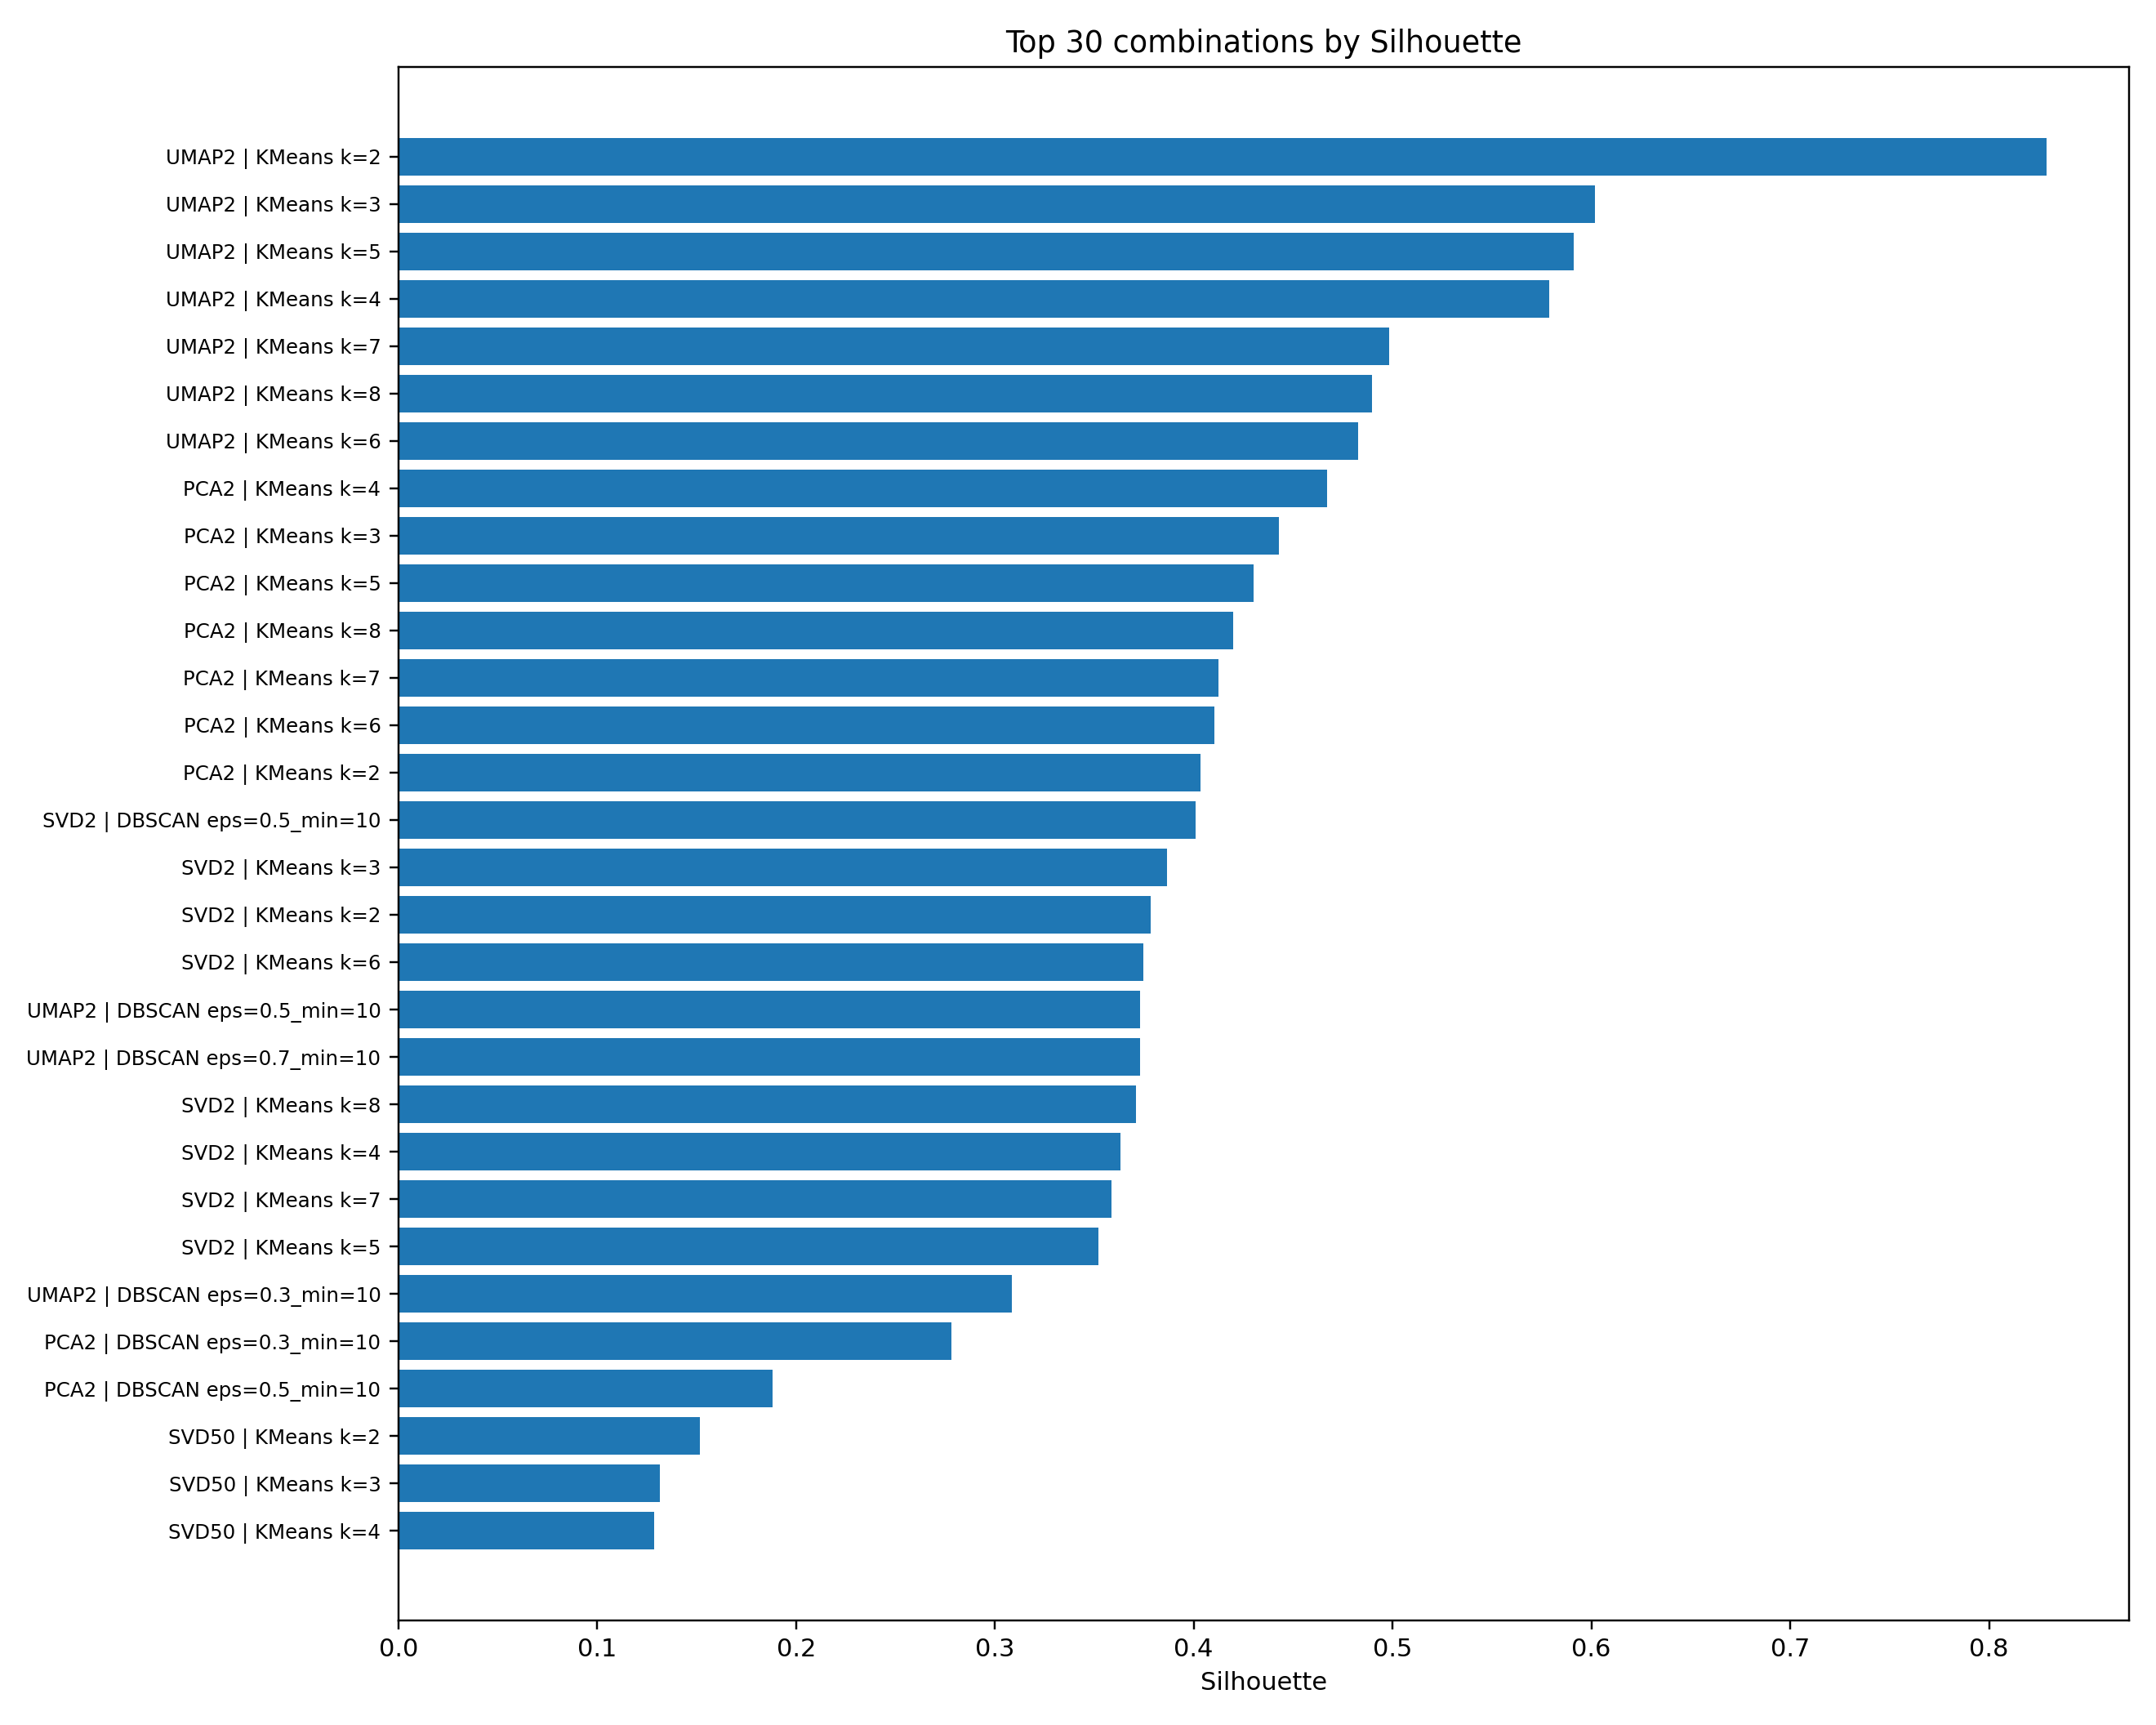

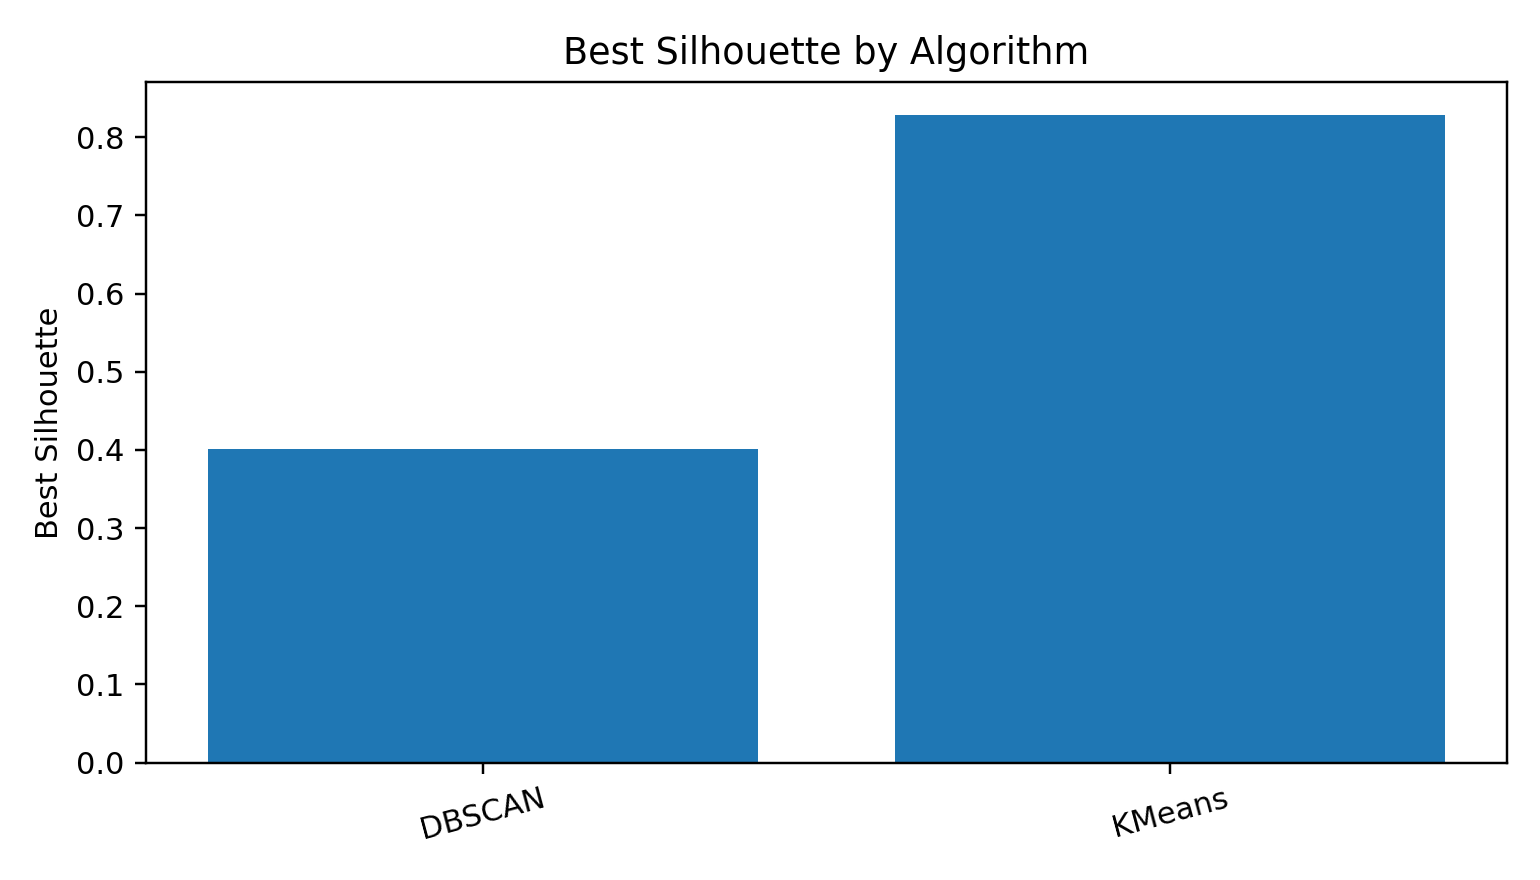

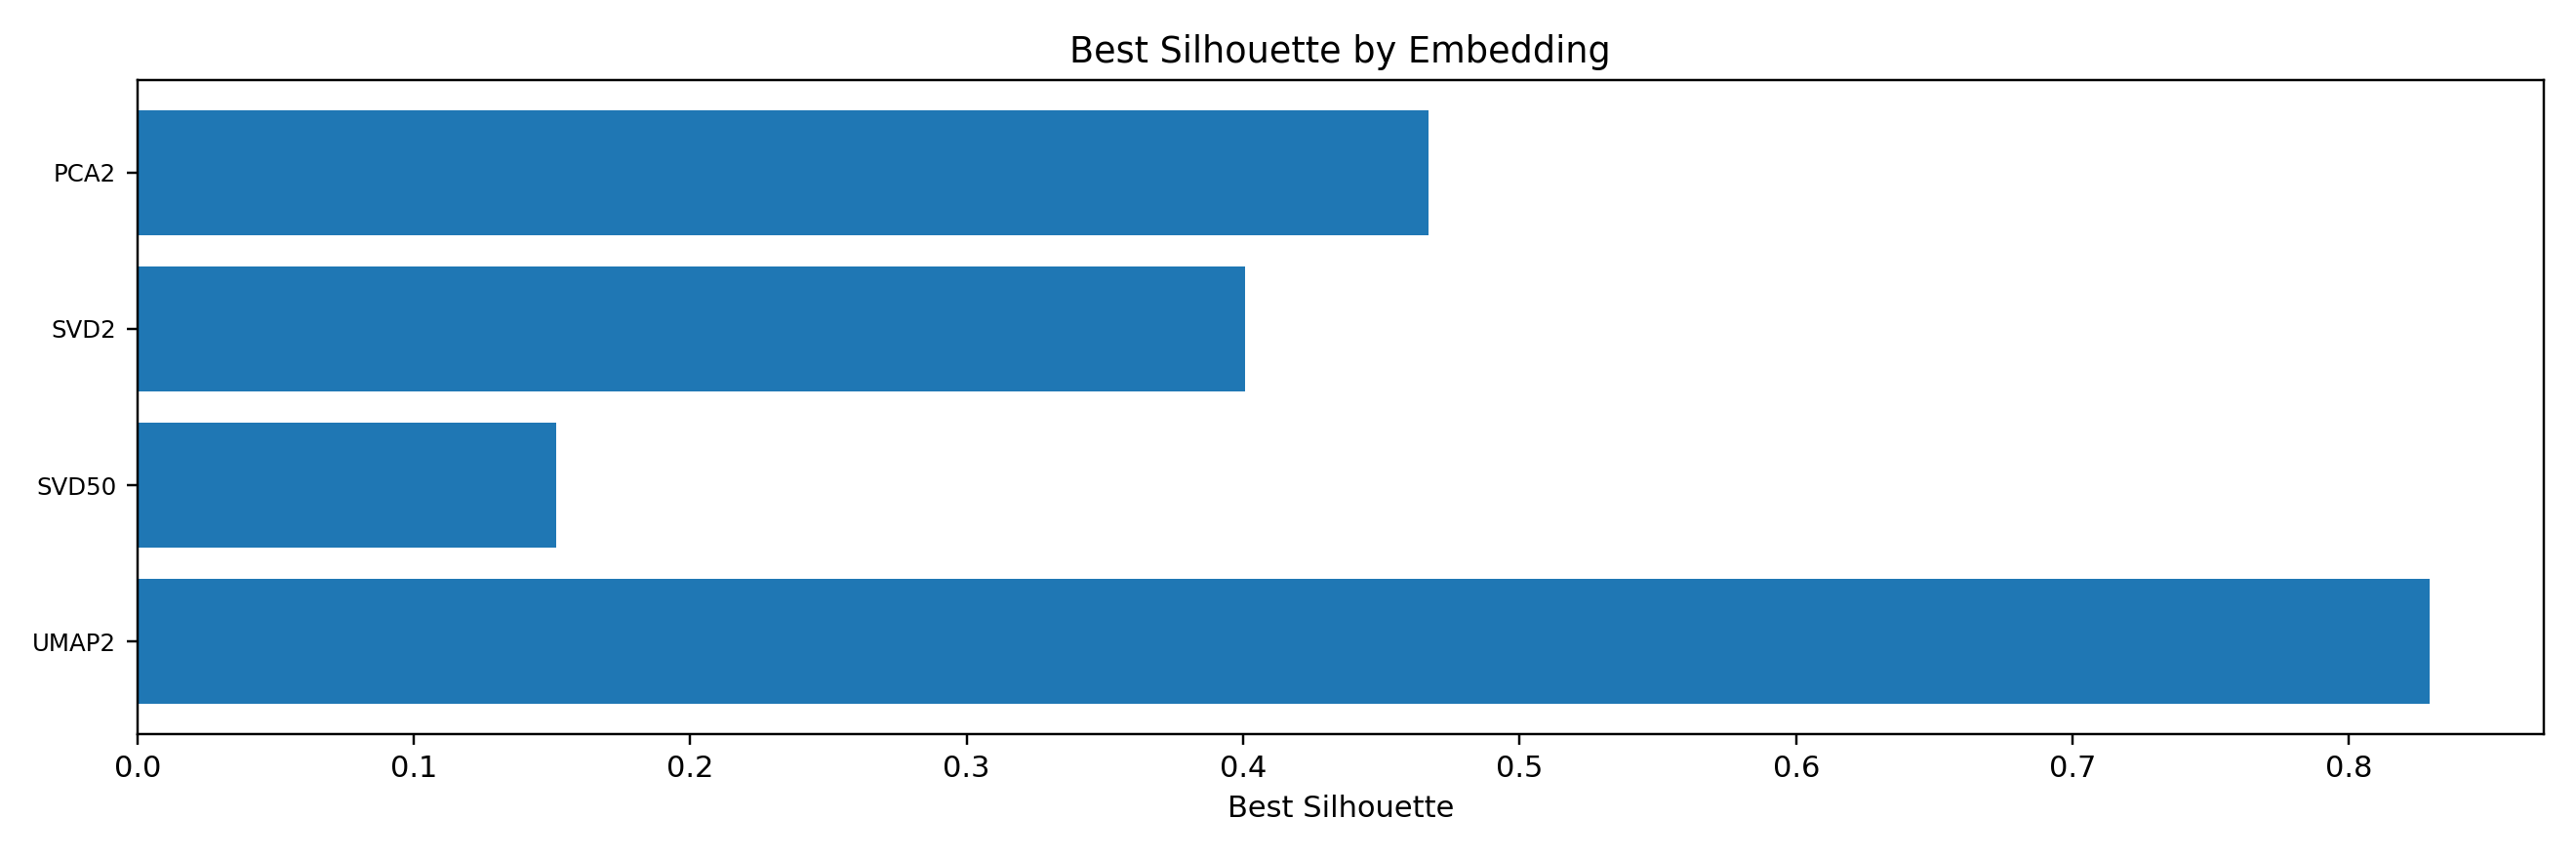

### Summary tables

,embedding,algorithm,config,embedding_dim,silhouette,calinski_harabasz,davies_bouldin,n_clusters,n_noise,combination
30,UMAP2,KMeans,k=2,2,0.828992,18171.654297,0.229776,2,0,UMAP2 + KMeans (k=2)
31,UMAP2,KMeans,k=3,2,0.601723,16296.460938,0.654758,3,0,UMAP2 + KMeans (k=3)
33,UMAP2,KMeans,k=5,2,0.591018,15060.938477,0.663968,5,0,UMAP2 + KMeans (k=5)
32,UMAP2,KMeans,k=4,2,0.578902,15560.286133,0.683476,4,0,UMAP2 + KMeans (k=4)
35,UMAP2,KMeans,k=7,2,0.498316,16970.355469,0.692996,7,0,UMAP2 + KMeans (k=7)
36,UMAP2,KMeans,k=8,2,0.489720,17307.080078,0.731574,8,0,UMAP2 + KMeans (k=8)
34,UMAP2,KMeans,k=6,2,0.482527,16394.625000,0.736440,6,0,UMAP2 + KMeans (k=6)
22,PCA2,KMeans,k=4,2,0.467098,1768.370709,0.699512,4,0,PCA2 + KMeans (k=4)
21,PCA2,KMeans,k=3,2,0.442750,1482.493228,0.773370,3,0,PCA2 + KMeans (k=3)
23,PCA2,KMeans,k=5,2,0.430210,1839.044760,0.791138,5,0,PCA2 + KMeans (k=5)


### High-performance combinations

,embedding,algorithm,config,embedding_dim,silhouette,calinski_harabasz,davies_bouldin,n_clusters,n_noise,combination
0,UMAP2,KMeans,k=2,2,0.828992,18171.654297,0.229776,2,0,UMAP2 + KMeans (k=2)
1,UMAP2,KMeans,k=3,2,0.601723,16296.460938,0.654758,3,0,UMAP2 + KMeans (k=3)


### Saved figures

- `best_combination_visualization.png`

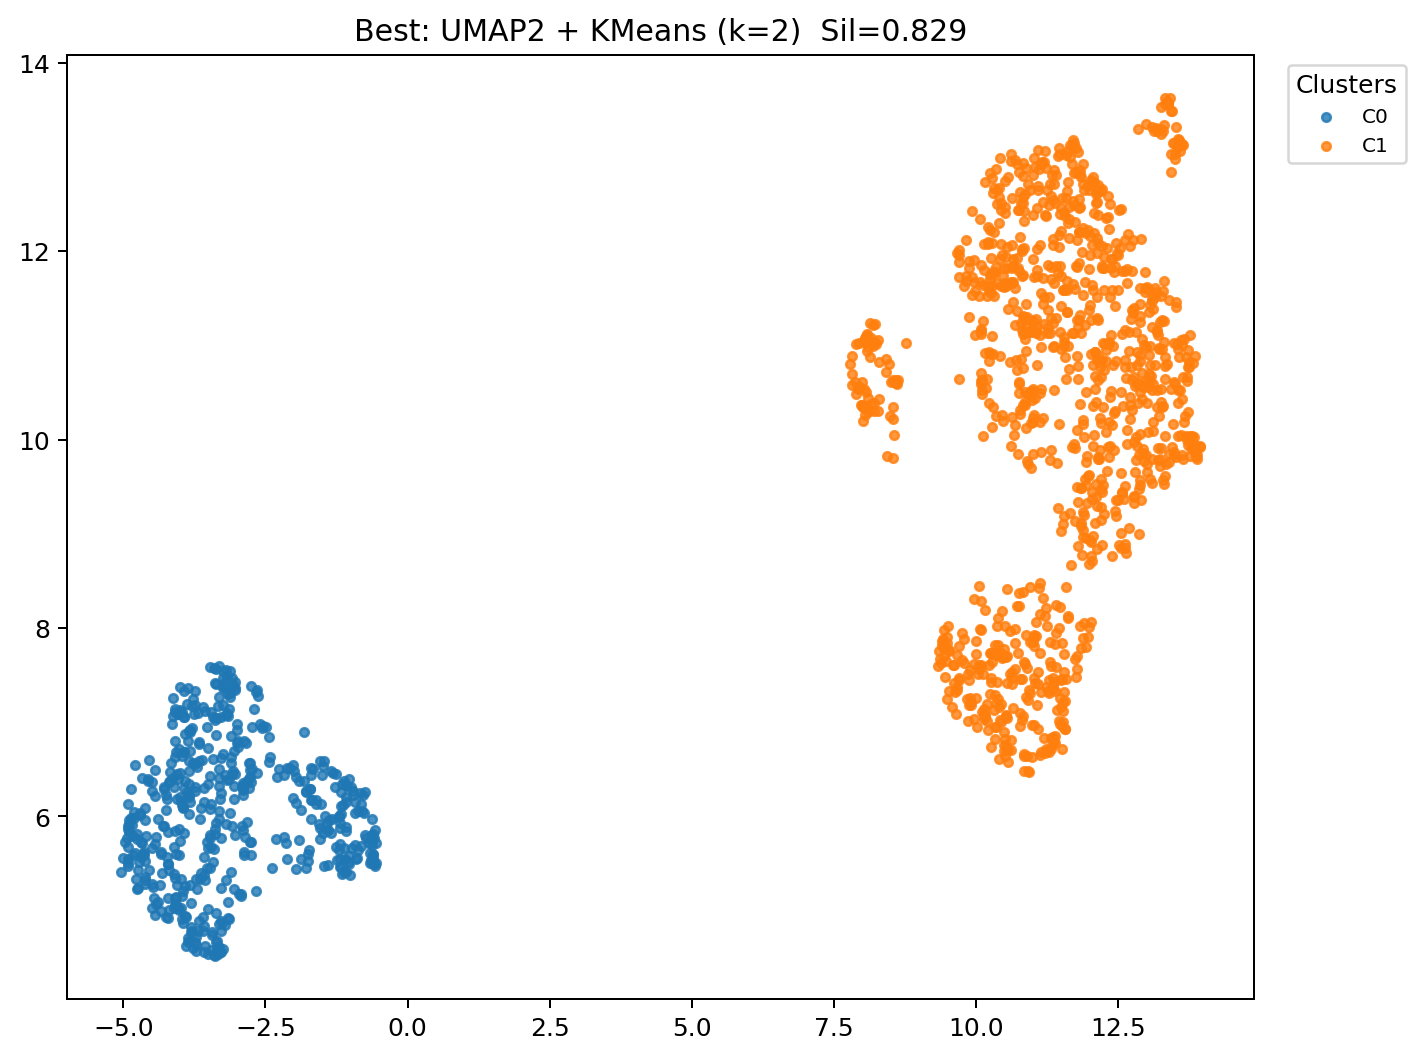

### Cluster interpretation index

,combo,silhouette
0,UMAP2 + KMeans (k=2),0.828992
1,UMAP2 + KMeans (k=3),0.601723
2,UMAP2 + KMeans (k=5),0.591018
3,UMAP2 + KMeans (k=4),0.578902
4,UMAP2 + KMeans (k=7),0.498316
5,UMAP2 + KMeans (k=8),0.489720
6,UMAP2 + KMeans (k=6),0.482527
7,PCA2 + KMeans (k=4),0.467098
8,PCA2 + KMeans (k=3),0.442750
9,PCA2 + KMeans (k=5),0.430210



Overview charts saved → /content/unsup_results/charts_overview


In [ ]:
# Run your analysis
from unsupervised import run_unsupervised

OUT_DIR = "/content/unsup_results"

run_unsupervised(
    data="/content/lapd_clean_final.parquet",
    output=OUT_DIR,
    max_samples=5000,
    seed=42,
    interpret=True,
    top_n=10,
)

# ---------- Visualize everything saved in OUT_DIR ----------
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

def visualize_unsup_results(out_dir: str, topN: int = 30):
    os.makedirs(out_dir, exist_ok=True)
    charts_dir = os.path.join(out_dir, "charts_overview")
    os.makedirs(charts_dir, exist_ok=True)

    all_path  = os.path.join(out_dir, "all_combinations_results.csv")
    high_path = os.path.join(out_dir, "high_performance_combinations.csv")
    idx_json  = os.path.join(out_dir, "cluster_interpretations_index.json")

    # 1) Load results
    df_all = pd.read_csv(all_path) if os.path.exists(all_path) else None
    df_hi  = pd.read_csv(high_path) if os.path.exists(high_path) else None

    if df_all is not None:
        # Ensure helpful derived column exists
        if "combination" not in df_all.columns and {"embedding","algorithm","config"}.issubset(df_all.columns):
            df_all["combination"] = df_all["embedding"] + " + " + df_all["algorithm"] + " (" + df_all["config"] + ")"

        # 2) Top-N silhouettes (barh)
        topN = min(topN, len(df_all))
        tdf = (df_all.dropna(subset=["silhouette"])
                      .nlargest(topN, "silhouette")
                      .copy())
        if len(tdf):
            plt.figure(figsize=(12, max(4, 0.32*len(tdf))))
            ylabels = [f"{r.embedding} | {r.algorithm} {r.config}" for _, r in tdf.iterrows()]
            plt.barh(range(len(tdf)), tdf["silhouette"].values)
            plt.yticks(range(len(tdf)), ylabels, fontsize=8)
            plt.gca().invert_yaxis()
            plt.xlabel("Silhouette")
            plt.title(f"Top {len(tdf)} combinations by Silhouette")
            plt.tight_layout()
            p = os.path.join(charts_dir, "top_silhouette_barh.png")
            plt.savefig(p, dpi=220); plt.close()
            display(Image(p))

        # 3) Best silhouette by algorithm (bar)
        if "algorithm" in df_all.columns:
            best_by_algo = (df_all.dropna(subset=["silhouette"])
                                   .sort_values("silhouette", ascending=False)
                                   .groupby("algorithm", as_index=False)
                                   .first()[["algorithm","silhouette"]])
            if len(best_by_algo):
                plt.figure(figsize=(7,4))
                plt.bar(best_by_algo["algorithm"], best_by_algo["silhouette"])
                plt.ylabel("Best Silhouette")
                plt.title("Best Silhouette by Algorithm")
                plt.xticks(rotation=15)
                plt.tight_layout()
                p = os.path.join(charts_dir, "best_by_algorithm.png")
                plt.savefig(p, dpi=220); plt.close()
                display(Image(p))

        # 4) Best silhouette by embedding (barh)
        if "embedding" in df_all.columns:
            best_by_emb = (df_all.dropna(subset=["silhouette"])
                                  .sort_values("silhouette", ascending=False)
                                  .groupby("embedding", as_index=False)
                                  .first()[["embedding","silhouette"]])
            if len(best_by_emb):
                plt.figure(figsize=(12, max(4, 0.28*len(best_by_emb))))
                plt.barh(range(len(best_by_emb)), best_by_emb["silhouette"])
                plt.yticks(range(len(best_by_emb)), best_by_emb["embedding"], fontsize=8)
                plt.gca().invert_yaxis()
                plt.xlabel("Best Silhouette")
                plt.title("Best Silhouette by Embedding")
                plt.tight_layout()
                p = os.path.join(charts_dir, "best_by_embedding.png")
                plt.savefig(p, dpi=220); plt.close()
                display(Image(p))

        # 5) Print small tables
        display(Markdown("### Summary tables"))
        display(df_all.sort_values("silhouette", ascending=False).head(15))

    if df_hi is not None and len(df_hi):
        display(Markdown("### High-performance combinations"))
        display(df_hi.sort_values("silhouette", ascending=False))

    # 6) Show any images the pipeline already saved (best plot, etc.)
    imgs = sorted(glob.glob(os.path.join(out_dir, "*.png")))
    if imgs:
        display(Markdown("### Saved figures"))
        for img in imgs:
            display(Markdown(f"- `{os.path.basename(img)}`"))
            display(Image(img))

    # 7) Show interpretation index (if present)
    if os.path.exists(idx_json):
        try:
            with open(idx_json, "r") as f:
                idx = json.load(f)
            display(Markdown("### Cluster interpretation index"))
            display(pd.DataFrame(idx))
        except Exception:
            pass

    print(f"\nOverview charts saved → {charts_dir}")

visualize_unsup_results(OUT_DIR, topN=30)


In [ ]:
#save as another "backend".py for meaning analysis:
#!/usr/bin/env python3
"""
Cluster Meaning Analysis Tool

This script analyzes high-performing clustering combinations (silhouette >= 0.7)
to understand what each cluster represents using mutual information, statistical tests,
and feature importance analysis.

Usage:
    python cluster_meaning_analyzer.py
"""

import os
import json
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import TruncatedSVD, PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")

def _make_ohe():
    """Create OneHotEncoder with proper sparse parameter handling."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

class ClusterMeaningAnalyzer:
    """Analyzes cluster meanings using statistical and information-theoretic methods."""

    def __init__(self, data_path: str, results_dir: str, random_state: int = 42):
        self.data_path = data_path
        self.results_dir = results_dir
        self.random_state = random_state
        self.max_cat_cardinality = 30
        self.svd_components = 50

        # Load data
        self.df_original = self._load_data(data_path)
        print(f"[LOAD] Original data: {self.df_original.shape}")

        # Prepare feature matrix
        self.X, self.preprocessor, self.feature_info = self._build_feature_matrix()
        print(f"[PREP] Feature matrix: {self.X.shape}")

    def _load_data(self, data_path: str) -> pd.DataFrame:
        """Load data from CSV or Parquet file."""
        if data_path.lower().endswith('.parquet'):
            return pd.read_parquet(data_path)
        else:
            return pd.read_csv(data_path, low_memory=False)

    def _build_feature_matrix(self) -> Tuple[np.ndarray, ColumnTransformer, Dict]:
        """Build feature matrix and track feature information."""
        df = self.df_original.copy()

        # Remove constant columns
        const_cols = [c for c in df.columns if df[c].dropna().nunique() <= 1]
        if const_cols:
            df = df.drop(columns=const_cols)
            print(f"[CLEAN] Dropped {len(const_cols)} constant columns")

        # Identify feature types
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        categorical_all = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
        categorical_cols = [c for c in categorical_all
                           if df[c].dropna().nunique() <= self.max_cat_cardinality]

        print(f"[FEATURES] Numeric: {len(numeric_cols)}, Categorical: {len(categorical_cols)}")

        # Prepare data for preprocessing
        feature_df = df[numeric_cols + categorical_cols].copy()

        # Convert boolean to int
        for col in feature_df.select_dtypes(include=['bool']).columns:
            feature_df[col] = feature_df[col].astype(int)

        # Build preprocessor
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', StandardScaler(), [c for c in feature_df.columns
                                         if pd.api.types.is_numeric_dtype(feature_df[c])]),
                ('cat', _make_ohe(), [c for c in feature_df.columns
                                    if not pd.api.types.is_numeric_dtype(feature_df[c])])
            ],
            remainder='drop'
        )

        # Fit and transform
        X = preprocessor.fit_transform(feature_df)

        # Create feature info for interpretation
        feature_info = {
            'numeric_cols': [c for c in feature_df.columns
                           if pd.api.types.is_numeric_dtype(feature_df[c])],
            'categorical_cols': [c for c in feature_df.columns
                               if not pd.api.types.is_numeric_dtype(feature_df[c])],
            'feature_df': feature_df,
            'original_df': df
        }

        return X, preprocessor, feature_info

    def _get_embedding(self, embedding_name: str) -> np.ndarray:
        """Generate specified embedding."""
        if embedding_name == "SVD2":
            svd = TruncatedSVD(n_components=2, random_state=self.random_state)
            return svd.fit_transform(self.X)

        elif embedding_name == "SVD50":
            comp = max(2, min(self.svd_components, self.X.shape[1] - 1))
            svd = TruncatedSVD(n_components=comp, random_state=self.random_state)
            return svd.fit_transform(self.X)

        elif embedding_name == "PCA2":
            # Convert to dense if needed and feasible
            X_dense = self.X
            if hasattr(self.X, 'toarray') and self.X.shape[1] < 2000:
                X_dense = self.X.toarray()
            pca = PCA(n_components=2, random_state=self.random_state)
            return pca.fit_transform(X_dense)

        elif embedding_name == "UMAP2":
            # First get SVD50
            comp = max(2, min(self.svd_components, self.X.shape[1] - 1))
            svd = TruncatedSVD(n_components=comp, random_state=self.random_state)
            X_svd = svd.fit_transform(self.X)

            try:
                import umap
                um = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                              random_state=self.random_state, verbose=False)
                return um.fit_transform(X_svd)
            except ImportError:
                print(f"[WARNING] UMAP not available, using SVD2 instead")
                return self._get_embedding("SVD2")

        else:
            raise ValueError(f"Unknown embedding: {embedding_name}")

    def _get_clustering(self, embedding: np.ndarray, algorithm: str, config: str) -> np.ndarray:
        """Generate clustering labels."""
        if algorithm == "KMeans":
            k = int(config.split("=")[1])
            kmeans = KMeans(n_clusters=k, n_init=10, random_state=self.random_state)
            return kmeans.fit_predict(embedding)

        elif algorithm == "DBSCAN":
            parts = config.split("_")
            eps = float(parts[0].split("=")[1])
            min_samples = int(parts[1].split("=")[1])
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            return dbscan.fit_predict(embedding)

        else:
            raise ValueError(f"Unknown algorithm: {algorithm}")

    def _calculate_mutual_information(self, labels: np.ndarray) -> Dict[str, float]:
        """Calculate mutual information between features and cluster labels."""
        # Only consider non-noise points for MI calculation
        valid_mask = labels != -1
        if not np.any(valid_mask):
            return {}

        labels_valid = labels[valid_mask]
        feature_df = self.feature_info['feature_df'].iloc[valid_mask]

        mi_scores = {}

        # Mutual information for numerical features
        for col in self.feature_info['numeric_cols']:
            if col in feature_df.columns:
                values = feature_df[col].fillna(feature_df[col].median())
                try:
                    mi = mutual_info_regression(values.values.reshape(-1, 1), labels_valid)[0]
                    mi_scores[col] = mi
                except:
                    mi_scores[col] = 0.0

        # Mutual information for categorical features
        for col in self.feature_info['categorical_cols']:
            if col in feature_df.columns:
                # Encode categorical values
                le = LabelEncoder()
                values = feature_df[col].fillna('missing').astype(str)
                try:
                    encoded_values = le.fit_transform(values)
                    mi = mutual_info_classif(encoded_values.reshape(-1, 1), labels_valid)[0]
                    mi_scores[col] = mi
                except:
                    mi_scores[col] = 0.0

        return mi_scores

    def _statistical_tests(self, labels: np.ndarray) -> Dict[str, Dict]:
        """Perform statistical tests for each feature across clusters."""
        valid_mask = labels != -1
        if not np.any(valid_mask):
            return {}

        labels_valid = labels[valid_mask]
        feature_df = self.feature_info['feature_df'].iloc[valid_mask]
        unique_clusters = np.unique(labels_valid)

        if len(unique_clusters) < 2:
            return {}

        test_results = {}

        # Tests for numerical features
        for col in self.feature_info['numeric_cols']:
            if col not in feature_df.columns:
                continue

            values = feature_df[col].fillna(feature_df[col].median())
            cluster_groups = [values[labels_valid == c] for c in unique_clusters]

            try:
                # Kruskal-Wallis test (non-parametric ANOVA)
                if len(unique_clusters) > 2:
                    stat, p_val = kruskal(*cluster_groups)
                    test_name = "Kruskal-Wallis"
                else:
                    stat, p_val = mannwhitneyu(cluster_groups[0], cluster_groups[1],
                                              alternative='two-sided')
                    test_name = "Mann-Whitney U"

                test_results[col] = {
                    'test': test_name,
                    'statistic': stat,
                    'p_value': p_val,
                    'significant': p_val < 0.05,
                    'feature_type': 'numeric'
                }

                # Add cluster means for interpretation
                cluster_means = {f'cluster_{c}_mean': values[labels_valid == c].mean()
                               for c in unique_clusters}
                test_results[col].update(cluster_means)

            except Exception as e:
                test_results[col] = {
                    'test': 'failed',
                    'error': str(e),
                    'feature_type': 'numeric'
                }

        # Tests for categorical features
        for col in self.feature_info['categorical_cols']:
            if col not in feature_df.columns:
                continue

            try:
                # Chi-square test of independence
                crosstab = pd.crosstab(feature_df[col].fillna('missing'), labels_valid)
                chi2, p_val, dof, expected = chi2_contingency(crosstab)

                test_results[col] = {
                    'test': 'Chi-square',
                    'statistic': chi2,
                    'p_value': p_val,
                    'dof': dof,
                    'significant': p_val < 0.05,
                    'feature_type': 'categorical'
                }

                # Add cluster proportions for interpretation
                proportions = crosstab.div(crosstab.sum(axis=0), axis=1)
                for c in unique_clusters:
                    if c in proportions.columns:
                        top_category = proportions[c].idxmax()
                        top_prop = proportions[c].max()
                        test_results[col][f'cluster_{c}_top_category'] = top_category
                        test_results[col][f'cluster_{c}_top_proportion'] = top_prop

            except Exception as e:
                test_results[col] = {
                    'test': 'failed',
                    'error': str(e),
                    'feature_type': 'categorical'
                }

        return test_results

    def _generate_cluster_summary(self, labels: np.ndarray,
                                 mi_scores: Dict[str, float],
                                 stat_tests: Dict[str, Dict]) -> Dict[str, Any]:
        """Generate interpretable summary for each cluster."""
        valid_mask = labels != -1
        if not np.any(valid_mask):
            return {}

        labels_valid = labels[valid_mask]
        feature_df = self.feature_info['feature_df'].iloc[valid_mask]
        unique_clusters = np.unique(labels_valid)

        cluster_summaries = {}

        for cluster_id in unique_clusters:
            cluster_mask = labels_valid == cluster_id
            cluster_data = feature_df[cluster_mask]
            cluster_size = int(np.sum(cluster_mask))

            # Get top distinguishing features based on MI and statistical significance
            significant_features = []
            for feature, test_info in stat_tests.items():
                if (test_info.get('significant', False) and
                    feature in mi_scores and
                    mi_scores[feature] > 0.1):  # MI threshold

                    significant_features.append({
                        'feature': feature,
                        'mi_score': mi_scores[feature],
                        'p_value': test_info['p_value'],
                        'test_info': test_info
                    })

            # Sort by mutual information score
            significant_features.sort(key=lambda x: x['mi_score'], reverse=True)

            # Generate cluster characteristics
            characteristics = []
            for feat_info in significant_features[:10]:  # Top 10 features
                feature = feat_info['feature']
                test_info = feat_info['test_info']

                if test_info['feature_type'] == 'numeric':
                    cluster_mean_key = f'cluster_{cluster_id}_mean'
                    if cluster_mean_key in test_info:
                        mean_val = test_info[cluster_mean_key]
                        overall_mean = feature_df[feature].mean()
                        if mean_val > overall_mean * 1.1:
                            direction = "high"
                        elif mean_val < overall_mean * 0.9:
                            direction = "low"
                        else:
                            direction = "average"

                        characteristics.append({
                            'feature': feature,
                            'type': 'numeric',
                            'description': f"{direction} {feature}",
                            'value': f"{mean_val:.3f} (overall: {overall_mean:.3f})",
                            'mi_score': feat_info['mi_score']
                        })

                elif test_info['feature_type'] == 'categorical':
                    top_cat_key = f'cluster_{cluster_id}_top_category'
                    top_prop_key = f'cluster_{cluster_id}_top_proportion'
                    if top_cat_key in test_info and top_prop_key in test_info:
                        top_category = test_info[top_cat_key]
                        top_proportion = test_info[top_prop_key]

                        characteristics.append({
                            'feature': feature,
                            'type': 'categorical',
                            'description': f"mostly {top_category}",
                            'value': f"{top_category} ({top_proportion:.1%})",
                            'mi_score': feat_info['mi_score']
                        })

            cluster_summaries[f"cluster_{cluster_id}"] = {
                'size': cluster_size,
                'percentage': cluster_size / len(labels_valid) * 100,
                'top_characteristics': characteristics[:5],  # Top 5 for summary
                'all_characteristics': characteristics,
                'n_significant_features': len(significant_features)
            }

        return cluster_summaries

    def _create_visualization(self, combination: str, embedding: np.ndarray,
                             labels: np.ndarray, cluster_summaries: Dict,
                             output_dir: str) -> str:
        """Create visualization for the clustering result."""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

        # Main scatter plot
        unique_labels = np.unique(labels)
        colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))

        for i, label in enumerate(unique_labels):
            mask = labels == label
            if label == -1:
                ax1.scatter(embedding[mask, 0], embedding[mask, 1],
                           c='black', s=20, alpha=0.6, label='Noise')
            else:
                ax1.scatter(embedding[mask, 0], embedding[mask, 1],
                           c=[colors[i]], s=30, alpha=0.7,
                           label=f'Cluster {label} (n={np.sum(mask)})')

        ax1.set_title(f'{combination}\nClustering Result')
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True, alpha=0.3)

        # Cluster sizes
        valid_labels = labels[labels != -1]
        if len(valid_labels) > 0:
            cluster_sizes = pd.Series(valid_labels).value_counts().sort_index()
            ax2.bar(range(len(cluster_sizes)), cluster_sizes.values,
                   color=[colors[i] for i in range(len(cluster_sizes))])
            ax2.set_xlabel('Cluster ID')
            ax2.set_ylabel('Size')
            ax2.set_title('Cluster Sizes')
            ax2.set_xticks(range(len(cluster_sizes)))
            ax2.set_xticklabels(cluster_sizes.index)

        # Feature importance (top features by MI)
        if cluster_summaries:
            all_features = {}
            for cluster_info in cluster_summaries.values():
                for char in cluster_info['all_characteristics']:
                    feature = char['feature']
                    if feature not in all_features:
                        all_features[feature] = char['mi_score']

            if all_features:
                top_features = sorted(all_features.items(),
                                    key=lambda x: x[1], reverse=True)[:15]
                features, mi_scores = zip(*top_features)

                ax3.barh(range(len(features)), mi_scores)
                ax3.set_yticks(range(len(features)))
                ax3.set_yticklabels(features, fontsize=8)
                ax3.set_xlabel('Mutual Information Score')
                ax3.set_title('Top Features by Mutual Information')
                ax3.invert_yaxis()

        # Text summary
        ax4.axis('off')
        summary_text = f"Combination: {combination}\n\n"
        summary_text += f"Total samples: {len(labels)}\n"
        summary_text += f"Valid clusters: {len(np.unique(labels[labels != -1]))}\n"
        summary_text += f"Noise points: {np.sum(labels == -1)}\n\n"

        if cluster_summaries:
            summary_text += "Cluster Characteristics:\n"
            for cluster_id, info in cluster_summaries.items():
                summary_text += f"\n{cluster_id.replace('_', ' ').title()}:\n"
                summary_text += f"  Size: {info['size']} ({info['percentage']:.1f}%)\n"
                for char in info['top_characteristics'][:3]:
                    summary_text += f"  • {char['description']}\n"

        ax4.text(0.05, 0.95, summary_text, transform=ax4.transAxes,
                fontsize=9, verticalalignment='top', fontfamily='monospace')

        plt.tight_layout()

        # Save plot
        safe_name = combination.replace("+", "_").replace("(", "_").replace(")", "_").replace(" ", "_")
        plot_path = os.path.join(output_dir, f"cluster_analysis_{safe_name}.png")
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        plt.close()

        return plot_path

    def analyze_combination(self, combination_info: Dict[str, Any],
                          output_dir: str) -> Dict[str, Any]:
        """Analyze a single clustering combination."""
        embedding_name = combination_info['embedding']
        algorithm = combination_info['algorithm']
        config = combination_info['config']
        combination = combination_info['combination']

        print(f"\n[ANALYZE] {combination}")

        # Generate embedding and clustering
        embedding = self._get_embedding(embedding_name)
        labels = self._get_clustering(embedding, algorithm, config)

        # Calculate mutual information
        mi_scores = self._calculate_mutual_information(labels)

        # Perform statistical tests
        stat_tests = self._statistical_tests(labels)

        # Generate cluster summaries
        cluster_summaries = self._generate_cluster_summary(labels, mi_scores, stat_tests)

        # Create visualization
        viz_path = self._create_visualization(combination, embedding, labels,
                                            cluster_summaries, output_dir)

        # Count significant features
        n_significant = sum(1 for test in stat_tests.values()
                          if test.get('significant', False))

        # Get top features
        top_features = sorted(mi_scores.items(), key=lambda x: x[1], reverse=True)[:5]
        top_feature_names = [f[0] for f in top_features]

        return {
            'combination': combination,
            'silhouette': combination_info['silhouette'],
            'n_clusters': len(np.unique(labels[labels != -1])),
            'n_noise': int(np.sum(labels == -1)),
            'n_significant_features': n_significant,
            'top_features': ', '.join(top_feature_names),
            'visualization_path': viz_path,
            'cluster_summaries': cluster_summaries,
            'mi_scores': mi_scores,
            'statistical_tests': stat_tests
        }

    def run_full_analysis(self, silhouette_threshold: float = 0.7) -> str:
        """Run complete meaning analysis for high-performing combinations."""
        # Load results
        results_path = os.path.join(self.results_dir, "all_combinations_results.csv")
        if not os.path.exists(results_path):
            raise FileNotFoundError(f"Results file not found: {results_path}")

        results_df = pd.read_csv(results_path)

        # Filter by silhouette threshold
        high_perf = results_df[results_df['silhouette'] >= silhouette_threshold].copy()
        print(f"[FILTER] Found {len(high_perf)} combinations with silhouette >= {silhouette_threshold}")

        if len(high_perf) == 0:
            print("[WARNING] No combinations meet the silhouette threshold")
            return self.results_dir

        # Create output directory for meaning analysis
        meaning_dir = os.path.join(self.results_dir, "meaning_analysis")
        os.makedirs(meaning_dir, exist_ok=True)

        # Analyze each combination
        overview_rows = []
        detailed_results = {}

        for idx, row in high_perf.iterrows():
            try:
                result = self.analyze_combination(row.to_dict(), meaning_dir)
                overview_rows.append(result)
                detailed_results[result['combination']] = {
                    'cluster_summaries': result['cluster_summaries'],
                    'mi_scores': result['mi_scores'],
                    'statistical_tests': result['statistical_tests']
                }

            except Exception as e:
                print(f"[ERROR] Failed to analyze {row['combination']}: {e}")
                continue

        # Save overview
        overview_df = pd.DataFrame(overview_rows)
        overview_df = overview_df.sort_values('silhouette', ascending=False)
        overview_path = os.path.join(meaning_dir, "meaning_overview.csv")
        overview_df.to_csv(overview_path, index=False)

        # Save detailed results
        detailed_path = os.path.join(meaning_dir, "detailed_results.json")
        with open(detailed_path, 'w') as f:
            json.dump(detailed_results, f, indent=2, default=str)

        print(f"\n[COMPLETE] Analysis saved to: {meaning_dir}")
        print(f"[OVERVIEW] {overview_path}")
        print(f"[DETAILED] {detailed_path}")

        return meaning_dir

def main():
    """Main function to run cluster meaning analysis."""
    # Configuration
    DATA_PATH = "/content/lapd_clean_final.parquet"  # Update this path
    RESULTS_DIR = "/content/unsup_results"
    SILHOUETTE_THRESHOLD = 0.7

    print("="*80)
    print("CLUSTER MEANING ANALYSIS")
    print("="*80)

    try:
        # Initialize analyzer
        analyzer = ClusterMeaningAnalyzer(
            data_path=DATA_PATH,
            results_dir=RESULTS_DIR,
            random_state=42
        )

        # Run analysis
        output_dir = analyzer.run_full_analysis(silhouette_threshold=SILHOUETTE_THRESHOLD)

        print("\n" + "="*80)
        print("ANALYSIS COMPLETED!")
        print("="*80)
        print(f"Results available in: {output_dir}")

    except Exception as e:
        print(f"\nERROR: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

CLUSTER MEANING ANALYSIS
[LOAD] Original data: (1606, 24)
[CLEAN] Dropped 3 constant columns
[FEATURES] Numeric: 9, Categorical: 4
[PREP] Feature matrix: (1606, 48)
[FILTER] Found 1 combinations with silhouette >= 0.7

[ANALYZE] UMAP2 + KMeans (k=2)

[COMPLETE] Analysis saved to: /content/unsup_results/meaning_analysis
[OVERVIEW] /content/unsup_results/meaning_analysis/meaning_overview.csv
[DETAILED] /content/unsup_results/meaning_analysis/detailed_results.json

ANALYSIS COMPLETED!
Results available in: /content/unsup_results/meaning_analysis


In [ ]:
analyzer = ClusterMeaningAnalyzer(
    data_path="/content/lapd_clean_final.parquet",
    results_dir="/content/unsup_results",
    random_state=42
)
output_dir = analyzer.run_full_analysis(silhouette_threshold=0.7)

[LOAD] Original data: (1606, 24)
[CLEAN] Dropped 3 constant columns
[FEATURES] Numeric: 9, Categorical: 4
[PREP] Feature matrix: (1606, 48)
[FILTER] Found 1 combinations with silhouette >= 0.7

[ANALYZE] UMAP2 + KMeans (k=2)

[COMPLETE] Analysis saved to: /content/unsup_results/meaning_analysis
[OVERVIEW] /content/unsup_results/meaning_analysis/meaning_overview.csv
[DETAILED] /content/unsup_results/meaning_analysis/detailed_results.json


#plots analysis

[DEBUG] Loaded overview with shape: (1, 10)
[DEBUG] Loaded detailed results for 1 combinations
[DEBUG] First detailed result structure: ['cluster_summaries', 'mi_scores', 'statistical_tests']
[FILTER] Kept 1/1 combos with silhouette ≥ 0.60
[INIT] Loaded 1 combinations for plotting
[DEBUG] Overview columns: ['combination', 'silhouette', 'n_clusters', 'n_noise', 'n_significant_features', 'top_features', 'visualization_path', 'cluster_summaries', 'mi_scores', 'statistical_tests']
[DEBUG] Detailed results keys: ['UMAP2 + KMeans (k=2)']...
[SAVE] Plots will be saved to: /content/unsup_results/meaning_analysis/plots
[INFO] Starting plot generation process...
[INFO] Generating overview dashboard...
[DEBUG] Creating overview dashboard...


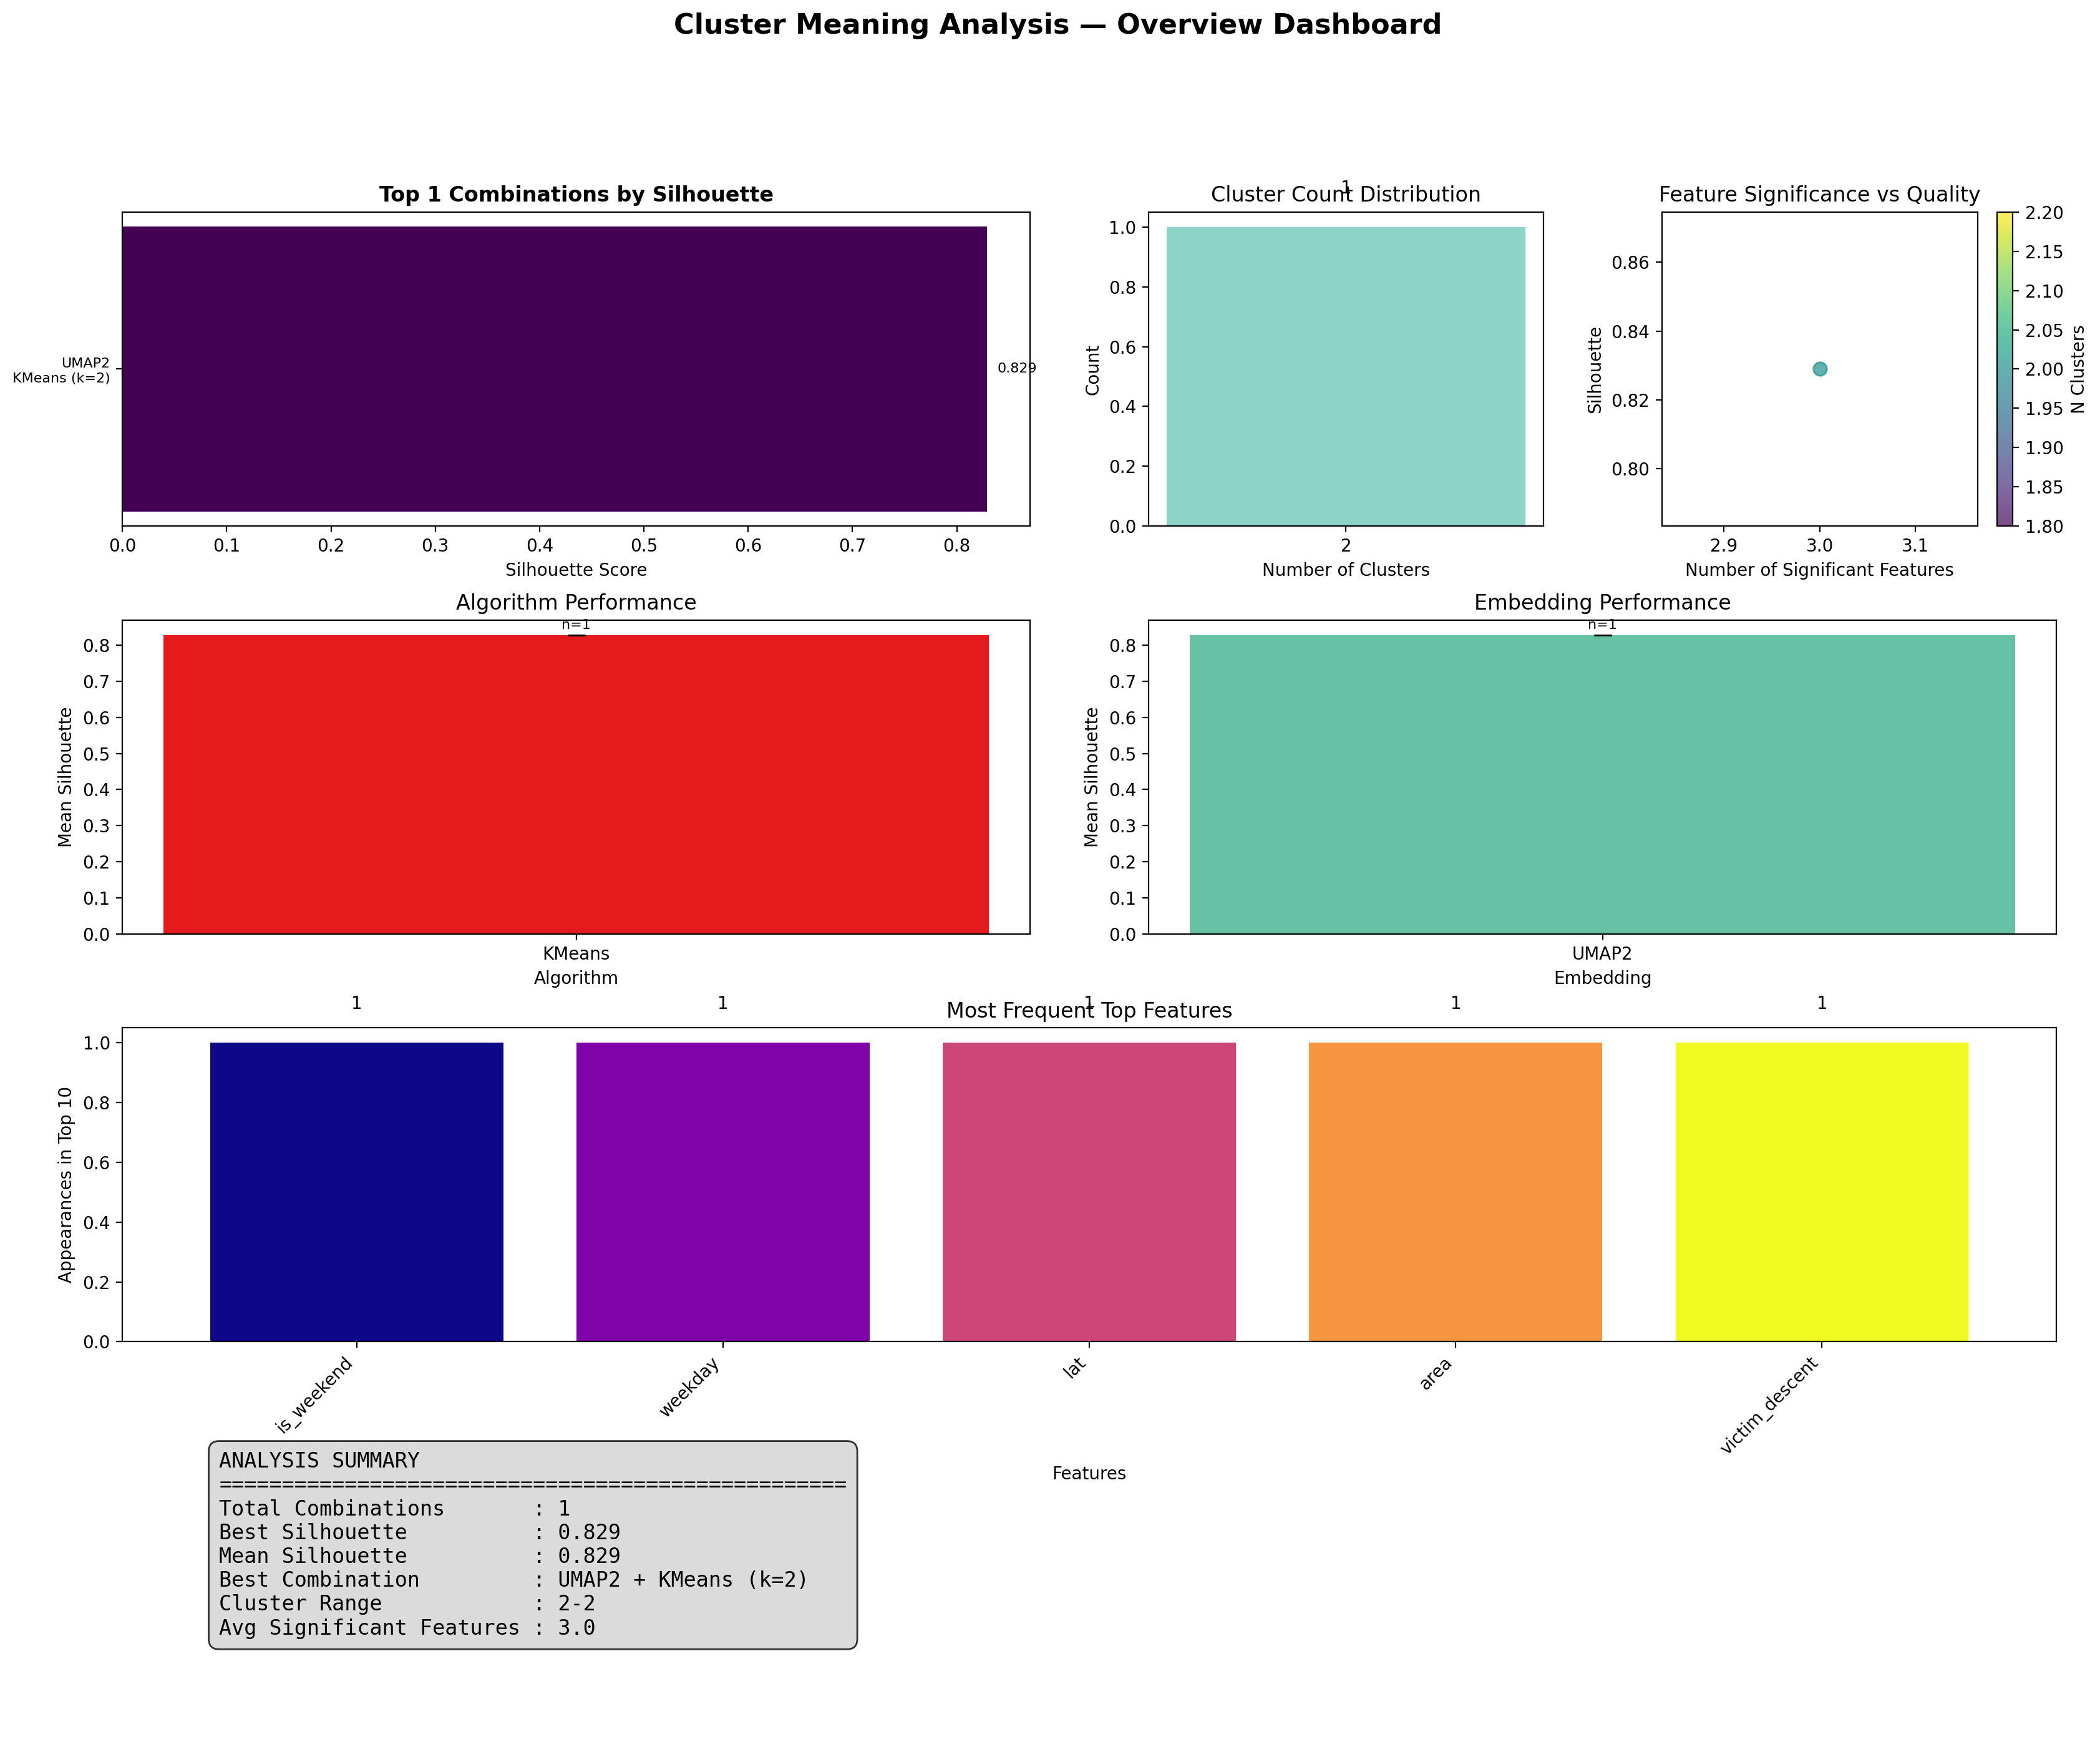

[SAVED] /content/unsup_results/meaning_analysis/plots/overview_dashboard.png
[INFO] Generating feature importance summary...
[DEBUG] Creating feature importance summary...
[DEBUG] Combo UMAP2 + KMeans (k=2): 13 MI scores
[DEBUG] Total features with MI scores: 13


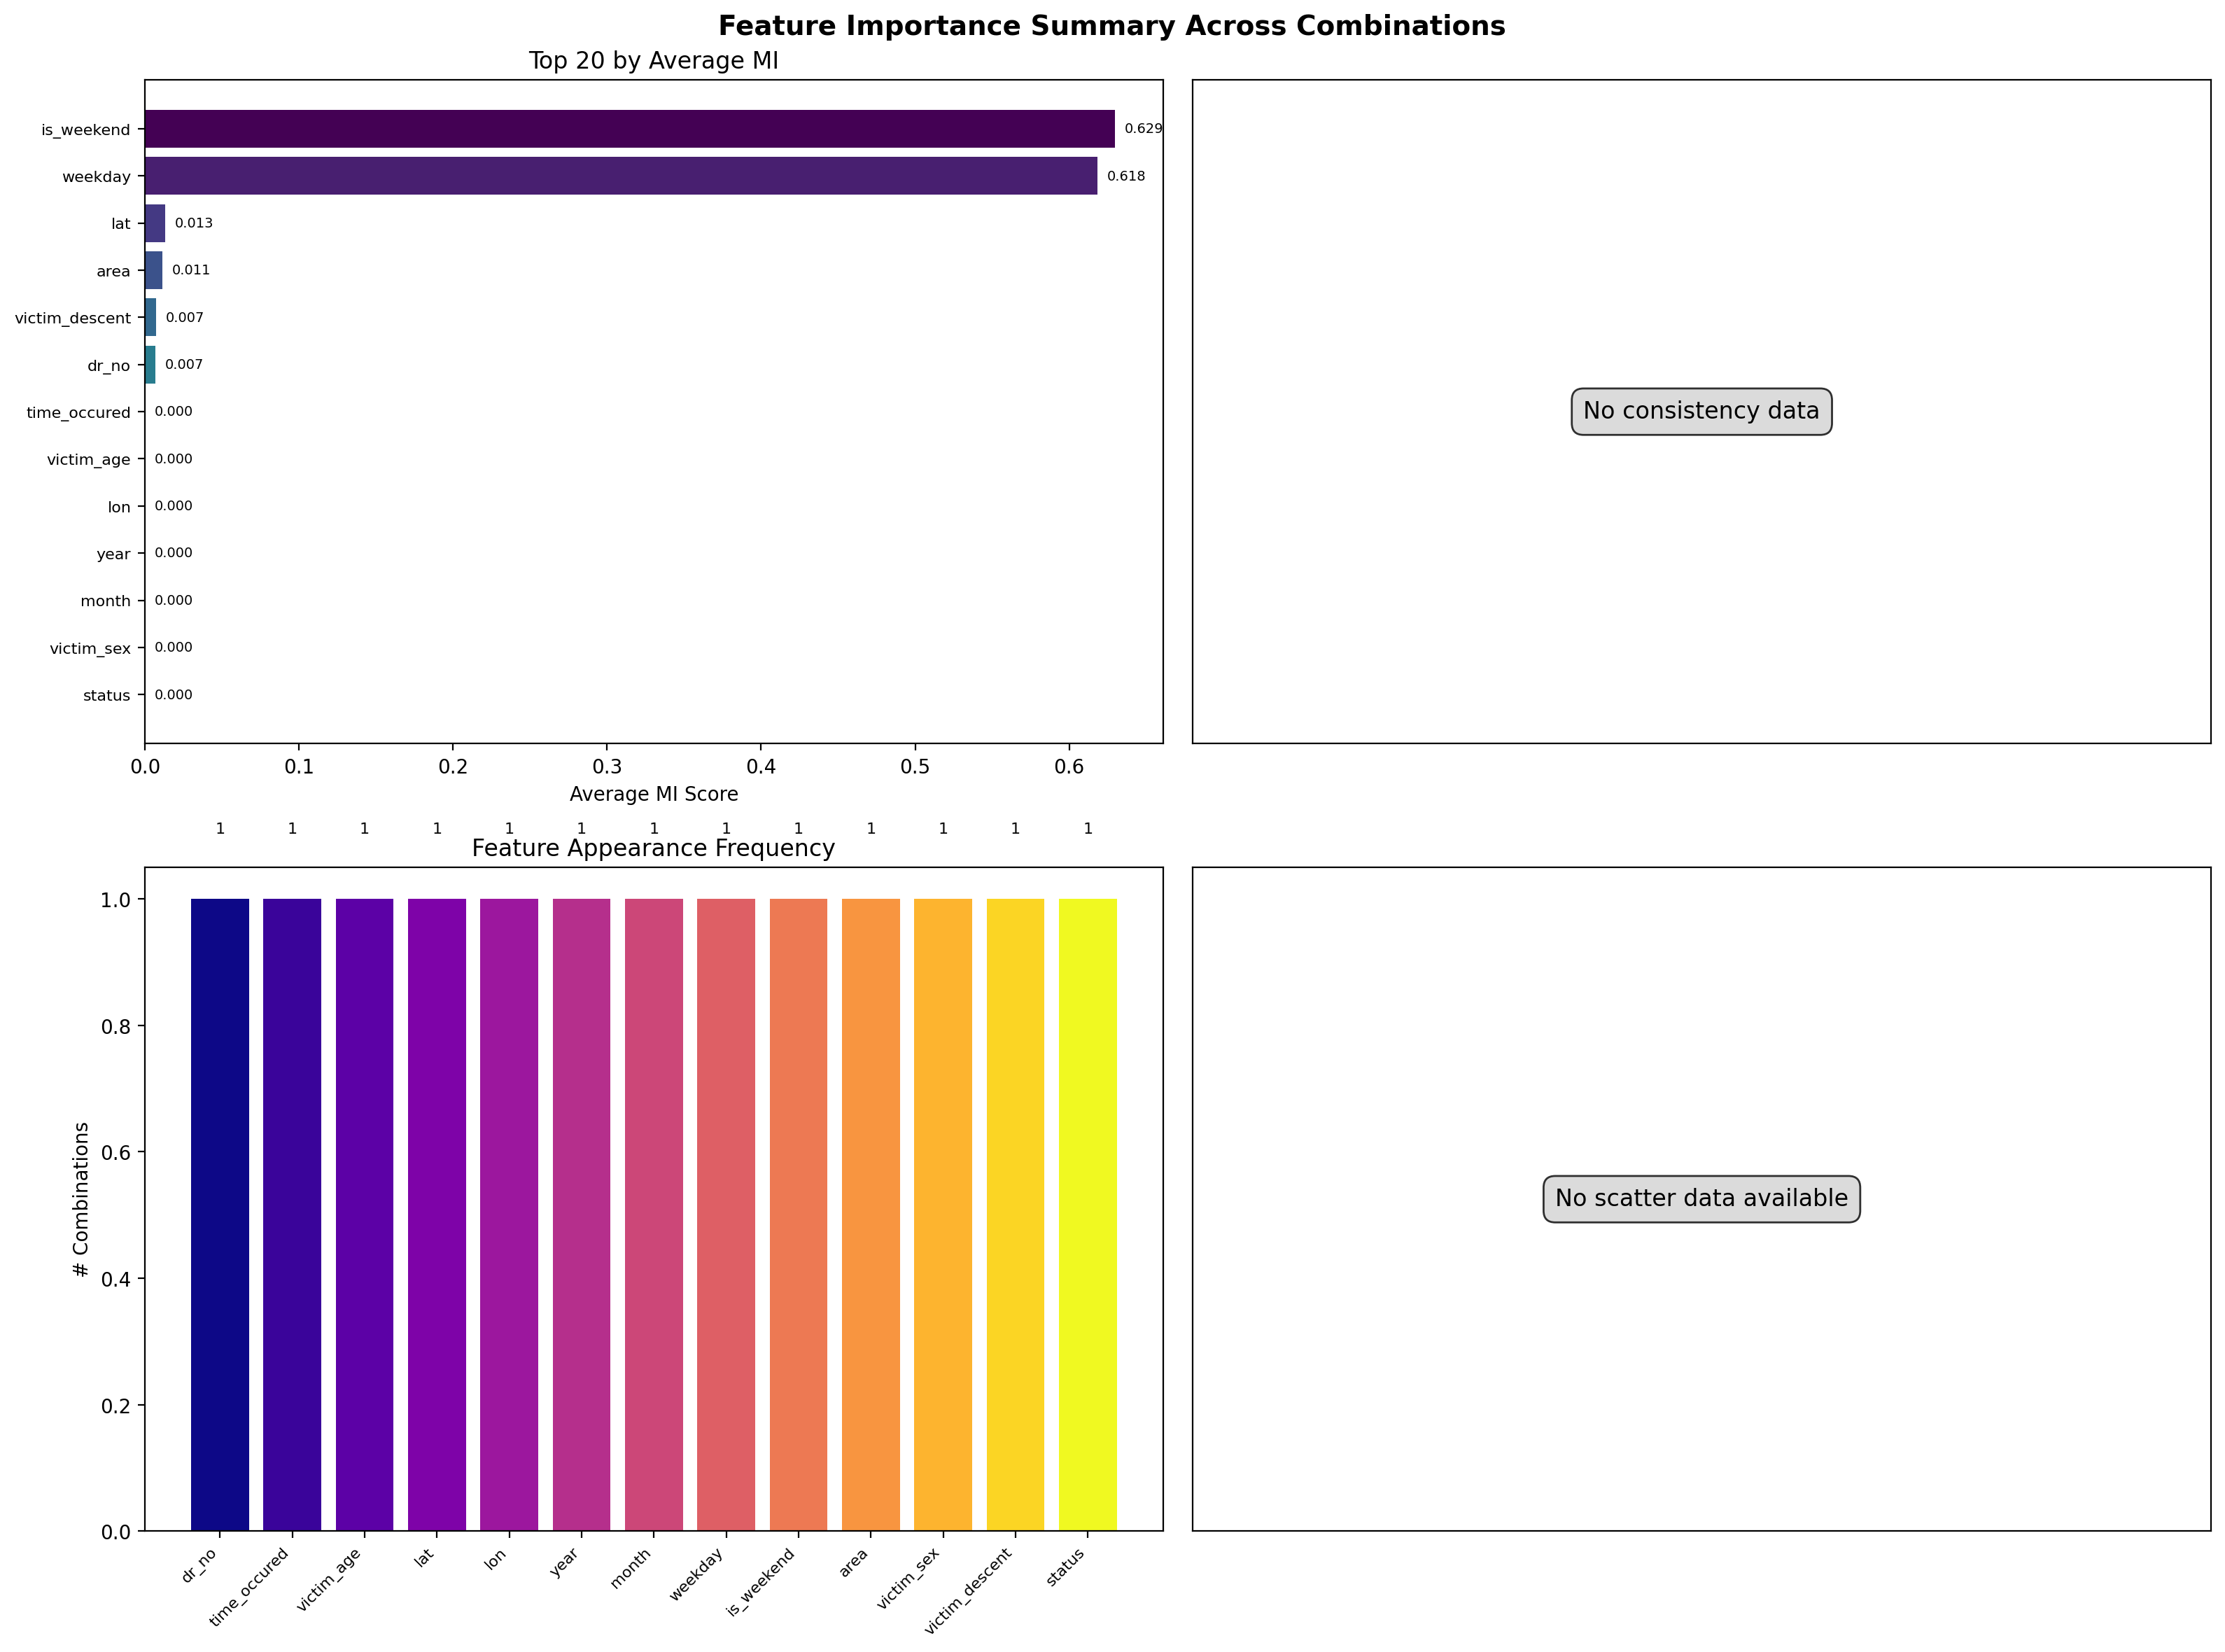

[SAVED] /content/unsup_results/meaning_analysis/plots/feature_importance_summary.png
[INFO] Generating statistical significance analysis...
[DEBUG] Creating statistical significance analysis...
[DEBUG] Found 13 valid statistical test results


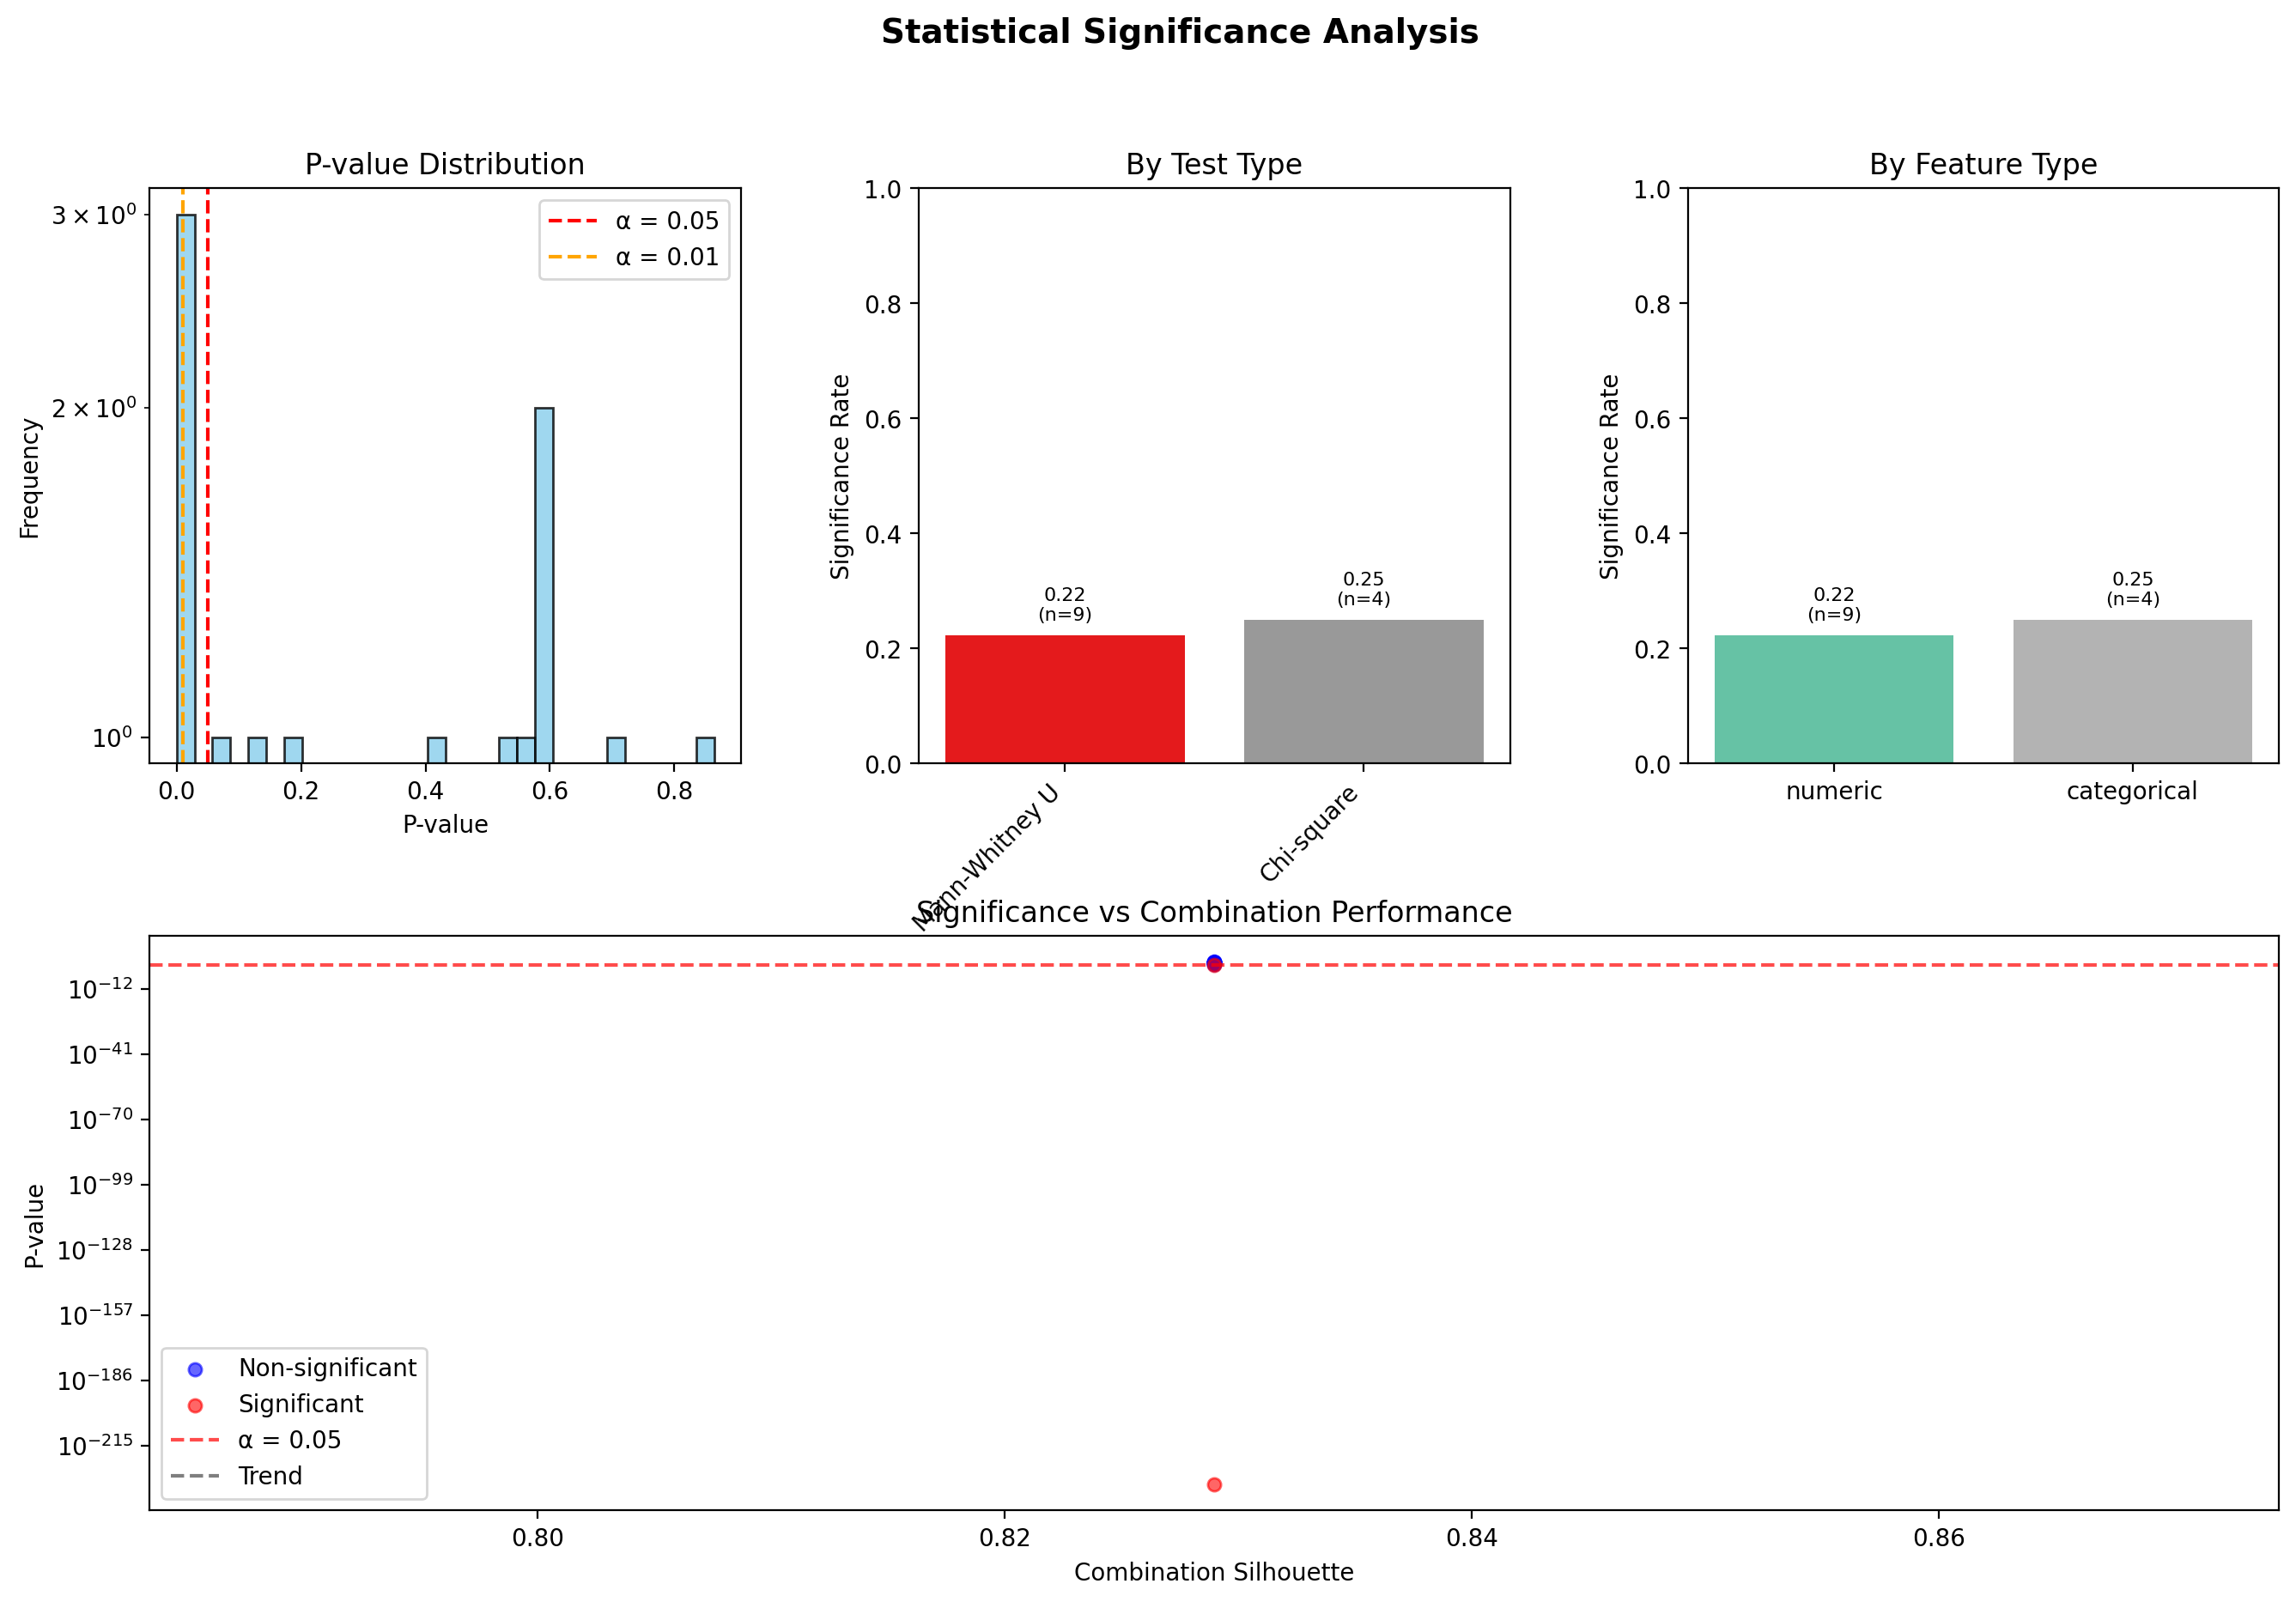

[SAVED] /content/unsup_results/meaning_analysis/plots/statistical_significance_analysis.png
[INFO] Generating detailed plots for top 5 combinations...
[DEBUG] Creating detailed plots for top 5 combinations...
[DEBUG] Processing combination 1/5: UMAP2 + KMeans (k=2)
[DEBUG] Found 2 cluster summaries and 13 MI scores


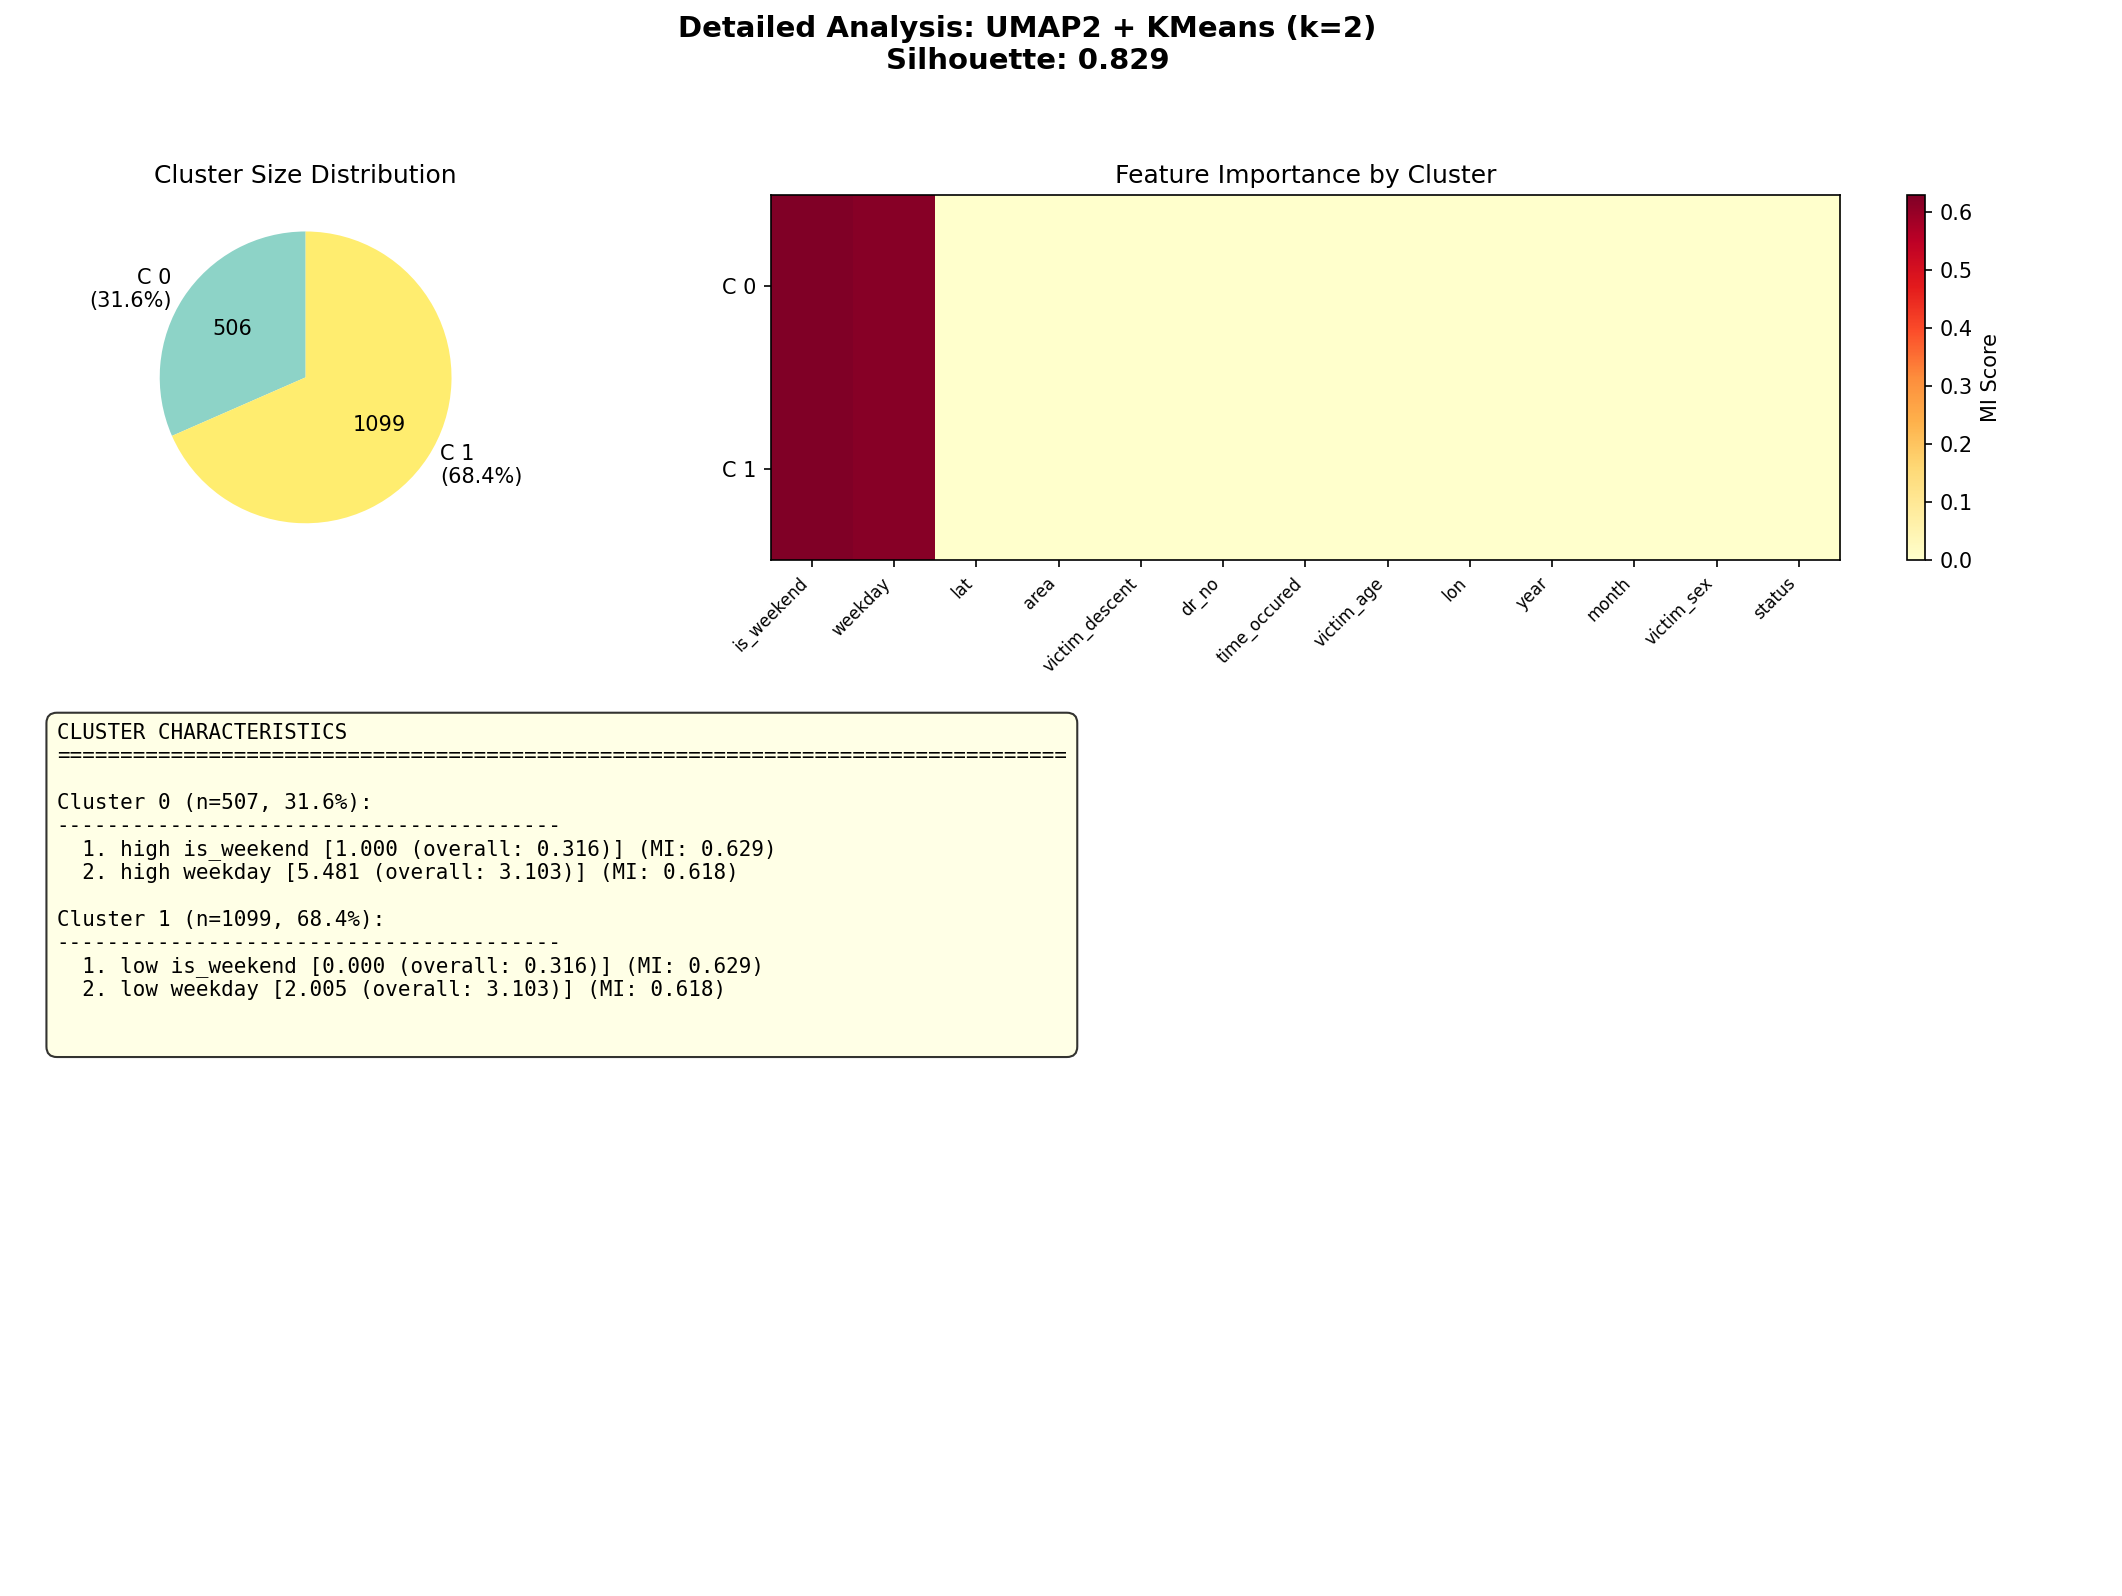

[SAVED] /content/unsup_results/meaning_analysis/plots/detailed_analysis_1_UMAP2___KMeans__k2_.png
[INFO] Creating HTML summary report...
[DEBUG] Creating HTML summary report...
[SAVED] /content/unsup_results/meaning_analysis/meaning_report.html
[INFO] Plot generation process completed!

Final Artifacts Summary:
  ✓ overview_dashboard: /content/unsup_results/meaning_analysis/plots/overview_dashboard.png
  ✓ feature_importance_summary: /content/unsup_results/meaning_analysis/plots/feature_importance_summary.png
  ✓ statistical_significance_analysis: /content/unsup_results/meaning_analysis/plots/statistical_significance_analysis.png
  ✓ detailed_plots: ['/content/unsup_results/meaning_analysis/plots/detailed_analysis_1_UMAP2___KMeans__k2_.png']
  ✓ html_report: /content/unsup_results/meaning_analysis/meaning_report.html


In [49]:
#!/usr/bin/env python3
"""
Meaning Analysis Results Plotter - Fixed Version

Usage (notebook):
    plotter = MeaningAnalysisPlotter("/content/unsup_results/meaning_analysis", threshold=0.6, show=True)
    plotter.plot_all()

Usage (CLI):
    python plot_meaning_results.py --dir /content/unsup_results/meaning_analysis --threshold 0.6
"""
import os, json, warnings, sys
from pathlib import Path
from typing import Dict, List, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")


class MeaningAnalysisPlotter:
    """Creates comprehensive visualizations from meaning analysis results."""

    def __init__(self, meaning_analysis_dir: str, threshold: float = 0.6, show: bool = True):
        self.meaning_dir = Path(meaning_analysis_dir)
        self.output_dir = self.meaning_dir / "plots"
        self.output_dir.mkdir(exist_ok=True)

        # Load data
        self.overview_df = self._load_overview()
        self.detailed_results = self._load_detailed_results()

        # Filter by silhouette
        if "silhouette" in self.overview_df.columns and len(self.overview_df) > 0:
            before = len(self.overview_df)
            self.overview_df = (
                self.overview_df.loc[self.overview_df["silhouette"] >= float(threshold)]
                .sort_values("silhouette", ascending=False)
                .reset_index(drop=True)
            )
            print(f"[FILTER] Kept {len(self.overview_df)}/{before} combos with silhouette ≥ {threshold:.2f}")

        # Style + behavior
        self.show = bool(show)
        plt.style.use("default")
        sns.set_palette("husl")

        print(f"[INIT] Loaded {len(self.overview_df)} combinations for plotting")
        print(f"[DEBUG] Overview columns: {list(self.overview_df.columns)}")
        print(f"[DEBUG] Detailed results keys: {list(self.detailed_results.keys())[:5]}...")
        print(f"[SAVE] Plots will be saved to: {self.output_dir}")

    # ------------------------- loaders -------------------------
    def _load_overview(self) -> pd.DataFrame:
        overview_path = self.meaning_dir / "meaning_overview.csv"
        if not overview_path.exists():
            print(f"[WARN] Overview file not found: {overview_path}")
            return pd.DataFrame()

        try:
            df = pd.read_csv(overview_path)
            print(f"[DEBUG] Loaded overview with shape: {df.shape}")

            # Guard missing columns
            for col, default in [
                ("combination", None),
                ("silhouette", np.nan),
                ("n_clusters", np.nan),
                ("n_significant_features", np.nan),
                ("top_features", "")
            ]:
                if col not in df.columns:
                    df[col] = default
            return df
        except Exception as e:
            print(f"[ERROR] Failed to load overview: {e}")
            return pd.DataFrame()

    def _load_detailed_results(self) -> Dict[str, Any]:
        detailed_path = self.meaning_dir / "detailed_results.json"
        if not detailed_path.exists():
            print("[WARN] detailed_results.json not found; some plots will be skipped")
            return {}
        try:
            with open(detailed_path, "r") as f:
                data = json.load(f)
                print(f"[DEBUG] Loaded detailed results for {len(data)} combinations")
                if data:
                    first_key = list(data.keys())[0]
                    print(f"[DEBUG] First detailed result structure: {list(data[first_key].keys())}")
                return data
        except Exception as e:
            print(f"[WARN] Failed to read detailed_results.json: {e}")
            return {}

    def _safe_plot_empty(self, ax, message="No data available"):
        """Helper to create empty plot with message"""
        ax.text(0.5, 0.5, message, ha="center", va="center", transform=ax.transAxes,
                fontsize=12, bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))
        ax.set_xticks([])
        ax.set_yticks([])

    # ------------------------- plots -------------------------
    def plot_overview_dashboard(self) -> str:
        if len(self.overview_df) == 0:
            print("[SKIP] No rows in overview after filtering")
            return ""

        print("[DEBUG] Creating overview dashboard...")
        fig = plt.figure(figsize=(20, 16))
        gs = GridSpec(4, 4, figure=fig, hspace=0.3, wspace=0.3)

        # 1. Silhouette ranking
        ax1 = fig.add_subplot(gs[0, :2])
        if "silhouette" in self.overview_df.columns and self.overview_df["silhouette"].notna().any():
            top_n = min(15, len(self.overview_df))
            top_combos = self.overview_df.head(top_n)
            y_pos = np.arange(len(top_combos))

            sil_values = top_combos["silhouette"].values
            sil_min, sil_max = sil_values.min(), sil_values.max()
            sil_range = sil_max - sil_min if sil_max > sil_min else 1

            colors = plt.cm.viridis((sil_values - sil_min) / sil_range)
            bars = ax1.barh(y_pos, sil_values, color=colors)
            ax1.set_yticks(y_pos)
            ax1.set_yticklabels([c.replace(" + ", "\n") for c in top_combos["combination"]], fontsize=8)
            ax1.set_xlabel("Silhouette Score")
            ax1.set_title(f"Top {top_n} Combinations by Silhouette", fontweight="bold")
            ax1.invert_yaxis()
            for bar, val in zip(bars, sil_values):
                ax1.text(val + sil_range*0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
        else:
            self._safe_plot_empty(ax1, "No silhouette data available")

        # 2. Number of clusters distribution
        ax2 = fig.add_subplot(gs[0, 2])
        if "n_clusters" in self.overview_df.columns and self.overview_df["n_clusters"].notna().any():
            cluster_data = self.overview_df["n_clusters"].dropna()
            if len(cluster_data) > 0:
                try:
                    cluster_data = cluster_data.astype(int)
                    vc = cluster_data.value_counts().sort_index()
                    if len(vc) > 0:
                        bars2 = ax2.bar(vc.index, vc.values, color=plt.cm.Set3(np.linspace(0, 1, len(vc))))
                        ax2.set_xlabel("Number of Clusters")
                        ax2.set_ylabel("Count")
                        ax2.set_title("Cluster Count Distribution")
                        ax2.set_xticks(vc.index)
                        for bar, val in zip(bars2, vc.values):
                            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(val), ha="center", va="bottom")
                    else:
                        self._safe_plot_empty(ax2, "No cluster count data")
                except Exception as e:
                    print(f"[ERROR] Cluster distribution plot: {e}")
                    self._safe_plot_empty(ax2, "Error processing cluster data")
            else:
                self._safe_plot_empty(ax2, "No cluster data available")
        else:
            self._safe_plot_empty(ax2, "n_clusters column not available")

        # 3. Significant features vs silhouette
        ax3 = fig.add_subplot(gs[0, 3])
        if ("n_significant_features" in self.overview_df.columns and
            "silhouette" in self.overview_df.columns):

            valid_mask = (self.overview_df["n_significant_features"].notna() &
                         self.overview_df["silhouette"].notna())
            if valid_mask.any():
                x_data = self.overview_df.loc[valid_mask, "n_significant_features"]
                y_data = self.overview_df.loc[valid_mask, "silhouette"]
                c_data = self.overview_df.loc[valid_mask].get("n_clusters", pd.Series([1]*len(x_data)))

                sc = ax3.scatter(x_data, y_data, c=c_data, cmap="viridis", s=60, alpha=0.7)
                ax3.set_xlabel("Number of Significant Features")
                ax3.set_ylabel("Silhouette")
                ax3.set_title("Feature Significance vs Quality")
                try:
                    plt.colorbar(sc, ax=ax3, label="N Clusters")
                except:
                    pass  # Skip colorbar if it fails
            else:
                self._safe_plot_empty(ax3, "No valid feature/silhouette data")
        else:
            self._safe_plot_empty(ax3, "Required columns not available")

        # 4. Algorithm performance comparison
        ax4 = fig.add_subplot(gs[1, :2])
        try:
            df_alg = self.overview_df.copy()
            df_alg["algorithm"] = df_alg["combination"].str.extract(r"\+\s*(\w+)", expand=False)
            valid_alg = df_alg["algorithm"].notna() & df_alg["silhouette"].notna()

            if valid_alg.any():
                algo_stats = df_alg[valid_alg].groupby("algorithm")["silhouette"].agg(["mean", "std", "count"])
                if len(algo_stats) > 0:
                    xpos = np.arange(len(algo_stats))
                    colors = plt.cm.Set1(np.linspace(0, 1, len(algo_stats)))
                    bars4 = ax4.bar(xpos, algo_stats["mean"],
                                   yerr=algo_stats["std"].fillna(0),
                                   capsize=5, color=colors)
                    ax4.set_xlabel("Algorithm")
                    ax4.set_ylabel("Mean Silhouette")
                    ax4.set_title("Algorithm Performance")
                    ax4.set_xticks(xpos)
                    ax4.set_xticklabels(algo_stats.index)
                    for bar, ct in zip(bars4, algo_stats["count"]):
                        ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"n={ct}",
                                ha="center", va="bottom", fontsize=8)
                else:
                    self._safe_plot_empty(ax4, "No algorithm data")
            else:
                self._safe_plot_empty(ax4, "Could not parse algorithm from combinations")
        except Exception as e:
            print(f"[ERROR] Algorithm performance plot: {e}")
            self._safe_plot_empty(ax4, "Error processing algorithm data")

        # 5. Embedding performance
        ax5 = fig.add_subplot(gs[1, 2:])
        try:
            df_emb = self.overview_df.copy()
            df_emb["embedding"] = df_emb["combination"].str.extract(r"^(\w+)", expand=False)
            valid_emb = df_emb["embedding"].notna() & df_emb["silhouette"].notna()

            if valid_emb.any():
                emb_stats = df_emb[valid_emb].groupby("embedding")["silhouette"].agg(["mean", "std", "count"])
                if len(emb_stats) > 0:
                    xpos = np.arange(len(emb_stats))
                    colors = plt.cm.Set2(np.linspace(0, 1, len(emb_stats)))
                    bars5 = ax5.bar(xpos, emb_stats["mean"],
                                   yerr=emb_stats["std"].fillna(0),
                                   capsize=5, color=colors)
                    ax5.set_xlabel("Embedding")
                    ax5.set_ylabel("Mean Silhouette")
                    ax5.set_title("Embedding Performance")
                    ax5.set_xticks(xpos)
                    ax5.set_xticklabels(emb_stats.index)
                    for bar, ct in zip(bars5, emb_stats["count"]):
                        ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f"n={ct}",
                                ha="center", va="bottom", fontsize=8)
                else:
                    self._safe_plot_empty(ax5, "No embedding data")
            else:
                self._safe_plot_empty(ax5, "Could not parse embedding from combinations")
        except Exception as e:
            print(f"[ERROR] Embedding performance plot: {e}")
            self._safe_plot_empty(ax5, "Error processing embedding data")

        # 6. Top features frequency among top 10
        ax6 = fig.add_subplot(gs[2, :])
        feat_counts = {}
        if "top_features" in self.overview_df.columns and len(self.overview_df) > 0:
            for _, r in self.overview_df.head(10).iterrows():
                feats_str = r.get("top_features", "")
                if pd.notna(feats_str) and feats_str:
                    feats = str(feats_str).split(", ")
                    for f in feats:
                        f = f.strip()
                        if f:
                            feat_counts[f] = feat_counts.get(f, 0) + 1

        if feat_counts:
            sorted_feats = sorted(feat_counts.items(), key=lambda x: x[1], reverse=True)[:15]
            features, counts = zip(*sorted_feats)
            bars6 = ax6.bar(range(len(features)), counts,
                           color=plt.cm.plasma(np.linspace(0, 1, len(features))))
            ax6.set_xlabel("Features")
            ax6.set_ylabel("Appearances in Top 10")
            ax6.set_title("Most Frequent Top Features")
            ax6.set_xticks(range(len(features)))
            ax6.set_xticklabels(features, rotation=45, ha="right")
            for bar, val in zip(bars6, counts):
                ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1, str(val),
                        ha="center", va="bottom")
        else:
            self._safe_plot_empty(ax6, "No top_features data available")

        # 7. Summary stats
        ax7 = fig.add_subplot(gs[3, :])
        ax7.axis("off")

        # Calculate summary stats safely
        best_sil = self.overview_df["silhouette"].max() if len(self.overview_df) > 0 else 0
        mean_sil = self.overview_df["silhouette"].mean() if len(self.overview_df) > 0 else 0
        best_combo = str(self.overview_df.iloc[0]["combination"]) if len(self.overview_df) > 0 else "—"

        cluster_range = "—"
        if "n_clusters" in self.overview_df.columns and self.overview_df["n_clusters"].notna().any():
            cluster_min = int(self.overview_df["n_clusters"].min())
            cluster_max = int(self.overview_df["n_clusters"].max())
            cluster_range = f"{cluster_min}-{cluster_max}"

        avg_sig_feat = "—"
        if ("n_significant_features" in self.overview_df.columns and
            self.overview_df["n_significant_features"].notna().any()):
            avg_sig_feat = f"{self.overview_df['n_significant_features'].mean():.1f}"

        summary = {
            "Total Combinations": len(self.overview_df),
            "Best Silhouette": f"{best_sil:.3f}",
            "Mean Silhouette": f"{mean_sil:.3f}",
            "Best Combination": best_combo,
            "Cluster Range": cluster_range,
            "Avg Significant Features": avg_sig_feat
        }

        txt = "ANALYSIS SUMMARY\n" + "="*50 + "\n" + "\n".join([f"{k:25}: {v}" for k, v in summary.items()])
        ax7.text(0.05, 0.95, txt, transform=ax7.transAxes, fontsize=12, va="top",
                 fontfamily="monospace", bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8))

        plt.suptitle("Cluster Meaning Analysis — Overview Dashboard", fontsize=16, fontweight="bold", y=0.98)
        out = self.output_dir / "overview_dashboard.png"
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.close()

        if self.show:
            try:
                from IPython.display import display, Image
                display(Image(filename=str(out)))
            except ImportError:
                print(f"[INFO] IPython not available, saved to {out}")
        print(f"[SAVED] {out}")
        return str(out)

    def plot_detailed_cluster_analysis(self, top_n: int = 5) -> List[str]:
        paths = []
        if not self.detailed_results:
            print("[SKIP] No detailed_results.json → skipping detailed plots")
            return paths

        print(f"[DEBUG] Creating detailed plots for top {top_n} combinations...")

        for idx, (_, row) in enumerate(self.overview_df.head(top_n).iterrows()):
            combo = row["combination"]
            print(f"[DEBUG] Processing combination {idx+1}/{top_n}: {combo}")

            if combo not in self.detailed_results:
                print(f"[WARN] Combination '{combo}' not found in detailed results")
                continue

            detailed = self.detailed_results[combo]
            cluster_summ = detailed.get("cluster_summaries", {})
            mi_scores = detailed.get("mi_scores", {})

            print(f"[DEBUG] Found {len(cluster_summ)} cluster summaries and {len(mi_scores)} MI scores")

            fig = plt.figure(figsize=(18, 12))
            gs = GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.3)
            fig.suptitle(f"Detailed Analysis: {combo}\nSilhouette: {row['silhouette']:.3f}",
                        fontsize=14, fontweight="bold")

            # 1) Pie of cluster sizes
            ax1 = fig.add_subplot(gs[0, 0])
            if cluster_summ:
                try:
                    sizes = []
                    labels = []
                    for cid, info in cluster_summ.items():
                        size = info.get("size", 0)
                        pct = info.get("percentage", 0)
                        if isinstance(size, (int, float)) and size > 0:
                            sizes.append(size)
                            cluster_num = cid.split('_')[-1] if '_' in str(cid) else str(cid)
                            labels.append(f"C {cluster_num}\n({pct:.1f}%)")

                    if sizes and sum(sizes) > 0:
                        ax1.pie(sizes, labels=labels, autopct=lambda pct: f'{int(pct/100*sum(sizes))}',
                               colors=plt.cm.Set3(np.linspace(0,1,len(sizes))), startangle=90)
                        ax1.set_title("Cluster Size Distribution")
                    else:
                        self._safe_plot_empty(ax1, "No valid cluster size data")
                except Exception as e:
                    print(f"[ERROR] Pie chart error: {e}")
                    self._safe_plot_empty(ax1, "Error creating pie chart")
            else:
                self._safe_plot_empty(ax1, "No cluster summaries available")

            # 2) Feature importance heatmap by cluster
            ax2 = fig.add_subplot(gs[0, 1:])
            if cluster_summ and mi_scores:
                try:
                    # Filter and convert MI scores to ensure they're numeric
                    numeric_mi_scores = {}
                    for f, score in mi_scores.items():
                        try:
                            numeric_score = float(score)
                            if not np.isnan(numeric_score):
                                numeric_mi_scores[f] = numeric_score
                        except (ValueError, TypeError):
                            continue

                    if numeric_mi_scores:
                        top_feat = [f for f, _ in sorted(numeric_mi_scores.items(),
                                                       key=lambda x: x[1], reverse=True)[:15]]

                        mat = []
                        row_labels = []
                        for cid, info in cluster_summ.items():
                            cluster_num = cid.split('_')[-1] if '_' in str(cid) else str(cid)
                            row_labels.append(f"C {cluster_num}")
                            row_vals = []
                            chars = info.get("all_characteristics", [])
                            for feat in top_feat:
                                score = 0.0
                                for ch in chars:
                                    if ch.get("feature") == feat:
                                        try:
                                            score = float(ch.get("mi_score", 0.0))
                                        except (ValueError, TypeError):
                                            score = 0.0
                                        break
                                row_vals.append(score)
                            mat.append(row_vals)

                        if mat and len(mat[0]) > 0:
                            mat_array = np.array(mat)
                            im = ax2.imshow(mat_array, cmap="YlOrRd", aspect="auto")
                            ax2.set_xticks(range(len(top_feat)))
                            ax2.set_xticklabels(top_feat, rotation=45, ha="right", fontsize=8)
                            ax2.set_yticks(range(len(row_labels)))
                            ax2.set_yticklabels(row_labels)
                            ax2.set_title("Feature Importance by Cluster")
                            try:
                                plt.colorbar(im, ax=ax2, label="MI Score")
                            except:
                                pass  # Skip colorbar if it fails
                        else:
                            self._safe_plot_empty(ax2, "No feature matrix data")
                    else:
                        self._safe_plot_empty(ax2, "No valid MI scores")
                except Exception as e:
                    print(f"[ERROR] Heatmap error: {e}")
                    self._safe_plot_empty(ax2, "Error creating heatmap")
            else:
                self._safe_plot_empty(ax2, "Missing MI scores or cluster data")

            # 3) Characteristics text
            ax3 = fig.add_subplot(gs[1:, :])
            ax3.axis("off")
            text = "CLUSTER CHARACTERISTICS\n" + "="*80 + "\n\n"

            if cluster_summ:
                for cid, info in cluster_summ.items():
                    cluster_num = cid.split("_")[-1] if "_" in str(cid) else str(cid)
                    size = info.get("size", 0)
                    pct = info.get("percentage", 0)
                    text += f"Cluster {cluster_num} (n={size}, {pct:.1f}%):\n"
                    text += "-" * 40 + "\n"

                    top_chars = info.get("top_characteristics", [])
                    if top_chars:
                        for i, ch in enumerate(top_chars[:8]):
                            desc = ch.get("description", "No description")
                            val = ch.get("value", "No value")
                            mi = ch.get("mi_score", 0.0)
                            try:
                                mi_val = float(mi)
                                text += f"  {i+1}. {desc} [{val}] (MI: {mi_val:.3f})\n"
                            except (ValueError, TypeError):
                                text += f"  {i+1}. {desc} [{val}] (MI: N/A)\n"
                    else:
                        text += "  No characteristics available\n"
                    text += "\n"
            else:
                text += "(no cluster details available)\n"

            ax3.text(0.02, 0.98, text, transform=ax3.transAxes, fontsize=10, va="top",
                     fontfamily="monospace",
                     bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow", alpha=0.8))

            # Safe filename
            safe = (combo.replace("+", "_").replace("(", "_").replace(")", "_")
                       .replace(" ", "_").replace("=", "").replace("/", "_"))
            out = self.output_dir / f"detailed_analysis_{idx+1}_{safe}.png"
            plt.savefig(out, dpi=150, bbox_inches="tight")
            plt.close()

            if self.show:
                try:
                    from IPython.display import display, Image
                    display(Image(filename=str(out)))
                except ImportError:
                    print(f"[INFO] IPython not available, saved to {out}")
            print(f"[SAVED] {out}")
            paths.append(str(out))
        return paths

    def plot_feature_importance_summary(self) -> str:
        if not self.detailed_results:
            print("[SKIP] No detailed_results.json → skipping feature importance summary")
            return ""

        print("[DEBUG] Creating feature importance summary...")

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

        all_mi = {}
        freq = {}
        for combo, det in self.detailed_results.items():
            mi_scores = det.get("mi_scores", {})
            print(f"[DEBUG] Combo {combo}: {len(mi_scores)} MI scores")
            for f, s in mi_scores.items():
                try:
                    score_val = float(s)
                    if not np.isnan(score_val):
                        all_mi.setdefault(f, []).append(score_val)
                        freq[f] = freq.get(f, 0) + 1
                except (ValueError, TypeError):
                    continue

        print(f"[DEBUG] Total features with MI scores: {len(all_mi)}")

        if not all_mi:
            # Create empty plots with message
            for ax in [ax1, ax2, ax3, ax4]:
                self._safe_plot_empty(ax, "No MI scores available")
            plt.suptitle("Feature Importance Summary - No Data Available", fontsize=14, fontweight="bold")
        else:
            # 1) Avg MI
            try:
                avg = {f: float(np.mean(v)) for f, v in all_mi.items()}
                top = sorted(avg.items(), key=lambda x: x[1], reverse=True)[:20]
                if top:
                    feats, scores = zip(*top)
                    y_pos = np.arange(len(feats))
                    colors = plt.cm.viridis(np.linspace(0,1,len(feats)))
                    bars = ax1.barh(y_pos, scores, color=colors)
                    ax1.set_yticks(y_pos)
                    ax1.set_yticklabels(feats, fontsize=8)
                    ax1.set_xlabel("Average MI Score")
                    ax1.set_title("Top 20 by Average MI")
                    ax1.invert_yaxis()
                    max_score = max(scores)
                    for bar, sc in zip(bars, scores):
                        ax1.text(sc + max_score*0.01, bar.get_y()+bar.get_height()/2,
                                f"{sc:.3f}", va="center", fontsize=7)
                else:
                    self._safe_plot_empty(ax1, "No average MI data")
            except Exception as e:
                print(f"[ERROR] Average MI plot: {e}")
                self._safe_plot_empty(ax1, "Error calculating averages")

            # 2) Consistency (std)
            try:
                std = {f: float(np.std(v)) for f, v in all_mi.items() if len(v) > 1}
                if std:
                    cons = sorted(std.items(), key=lambda x: x[1])[:15]
                    feats, stds = zip(*cons)
                    colors = plt.cm.RdYlBu_r(np.linspace(0,1,len(feats)))
                    bars2 = ax2.bar(range(len(feats)), stds, color=colors)
                    ax2.set_xticks(range(len(feats)))
                    ax2.set_xticklabels(feats, rotation=45, ha="right", fontsize=8)
                    ax2.set_ylabel("Std of MI")
                    ax2.set_title("Most Consistent Features (Low Variance)")
                else:
                    self._safe_plot_empty(ax2, "No consistency data")
            except Exception as e:
                print(f"[ERROR] Consistency plot: {e}")
                self._safe_plot_empty(ax2, "Error calculating consistency")

            # 3) Frequency
            try:
                freq_sorted = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:20]
                if freq_sorted:
                    feats, counts = zip(*freq_sorted)
                    colors = plt.cm.plasma(np.linspace(0,1,len(feats)))
                    bars3 = ax3.bar(range(len(feats)), counts, color=colors)
                    ax3.set_xticks(range(len(feats)))
                    ax3.set_xticklabels(feats, rotation=45, ha="right", fontsize=8)
                    ax3.set_ylabel("# Combinations")
                    ax3.set_title("Feature Appearance Frequency")
                    for bar, ct in zip(bars3, counts):
                        ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                                str(ct), ha="center", va="bottom", fontsize=8)
                else:
                    self._safe_plot_empty(ax3, "No frequency data")
            except Exception as e:
                print(f"[ERROR] Frequency plot: {e}")
                self._safe_plot_empty(ax3, "Error calculating frequency")

            # 4) Avg vs Std scatter
            try:
                avg = {f: float(np.mean(v)) for f, v in all_mi.items()}
                std = {f: float(np.std(v)) for f, v in all_mi.items() if len(v) > 1}
                feats_scatter = [f for f in avg if f in std]

                if feats_scatter and len(feats_scatter) > 0:
                    x = [avg[f] for f in feats_scatter]
                    y = [std[f] for f in feats_scatter]
                    sizes = [freq.get(f,1)*20 for f in feats_scatter]
                    colors = np.linspace(0,1,len(feats_scatter))
                    sc = ax4.scatter(x, y, s=sizes, alpha=0.6, c=colors, cmap="viridis")
                    ax4.set_xlabel("Average MI")
                    ax4.set_ylabel("Std of MI")
                    ax4.set_title("MI vs Consistency (size = frequency)")
                else:
                    self._safe_plot_empty(ax4, "No scatter data available")
            except Exception as e:
                print(f"[ERROR] Scatter plot: {e}")
                self._safe_plot_empty(ax4, "Error creating scatter plot")

            plt.suptitle("Feature Importance Summary Across Combinations", fontsize=14, fontweight="bold")

        plt.tight_layout()
        out = self.output_dir / "feature_importance_summary.png"
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.close()

        if self.show:
            try:
                from IPython.display import display, Image
                display(Image(filename=str(out)))
            except ImportError:
                print(f"[INFO] IPython not available, saved to {out}")
        print(f"[SAVED] {out}")
        return str(out)

    def plot_statistical_significance_analysis(self) -> str:
        print("[DEBUG] Creating statistical significance analysis...")

        # Expecting per-feature p-values in detailed_results[combo]["statistical_tests"][feature]
        # If missing, skip gracefully.
        pvals, tests, ftypes, combos = [], [], [], []

        if not self.detailed_results:
            print("[SKIP] No detailed_results.json for statistical analysis")
            fig, ax = plt.subplots(figsize=(10, 6))
            self._safe_plot_empty(ax, "No Detailed Results Available")
            ax.set_title("Statistical Significance Analysis")
            plt.tight_layout()
            out = self.output_dir / "statistical_significance_analysis.png"
            plt.savefig(out, dpi=200, bbox_inches="tight")
            plt.close()
            if self.show:
                try:
                    from IPython.display import display, Image
                    display(Image(filename=str(out)))
                except ImportError:
                    print(f"[INFO] IPython not available, saved to {out}")
            print(f"[SAVED] {out}")
            return str(out)

        for combo, det in self.detailed_results.items():
            stat_tests = det.get("statistical_tests", {})
            for feat, res in stat_tests.items():
                if isinstance(res, dict) and "p_value" in res:
                    try:
                        p_val = float(res["p_value"])
                        if not np.isnan(p_val) and 0 <= p_val <= 1:  # Valid p-value range
                            pvals.append(p_val)
                            tests.append(res.get("test", "unknown"))
                            ftypes.append(res.get("feature_type", "unknown"))
                            combos.append(combo)
                    except (ValueError, TypeError):
                        continue

        print(f"[DEBUG] Found {len(pvals)} valid statistical test results")

        if not pvals:
            print("[SKIP] No statistical_tests found in detailed_results.json")
            fig, ax = plt.subplots(figsize=(10, 6))
            self._safe_plot_empty(ax, "No Statistical Test Data Available\n\nThis plot requires 'statistical_tests' data in detailed_results.json")
            ax.set_title("Statistical Significance Analysis")
            plt.tight_layout()
            out = self.output_dir / "statistical_significance_analysis.png"
            plt.savefig(out, dpi=200, bbox_inches="tight")
            plt.close()
            if self.show:
                try:
                    from IPython.display import display, Image
                    display(Image(filename=str(out)))
                except ImportError:
                    print(f"[INFO] IPython not available, saved to {out}")
            print(f"[SAVED] {out}")
            return str(out)

        pvals = np.array(pvals)
        fig = plt.figure(figsize=(16, 10))
        gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

        # 1) P-value distribution
        ax1 = fig.add_subplot(gs[0, 0])
        try:
            ax1.hist(pvals, bins=30, alpha=0.8, color="skyblue", edgecolor="black")
            ax1.axvline(0.05, color="red", ls="--", label="α = 0.05")
            ax1.axvline(0.01, color="orange", ls="--", label="α = 0.01")
            ax1.set_yscale("log")
            ax1.set_xlabel("P-value")
            ax1.set_ylabel("Frequency")
            ax1.legend()
            ax1.set_title("P-value Distribution")
        except Exception as e:
            print(f"[ERROR] P-value distribution: {e}")
            self._safe_plot_empty(ax1, "Error creating p-value distribution")

        # 2) Significance rate by test type
        ax2 = fig.add_subplot(gs[0, 1])
        try:
            test_stats = {}
            for t, p in zip(tests, pvals):
                test_stats.setdefault(t, {"sig": 0, "tot": 0})
                test_stats[t]["tot"] += 1
                if p < 0.05:
                    test_stats[t]["sig"] += 1

            names = list(test_stats.keys())
            if names:
                rates = [test_stats[n]["sig"]/test_stats[n]["tot"] for n in names]
                totals = [test_stats[n]["tot"] for n in names]
                colors = plt.cm.Set1(np.linspace(0, 1, len(names)))
                bars = ax2.bar(range(len(names)), rates, color=colors)
                ax2.set_xticks(range(len(names)))
                ax2.set_xticklabels(names, rotation=45, ha="right")
                ax2.set_ylim(0,1)
                ax2.set_ylabel("Significance Rate")
                ax2.set_title("By Test Type")
                for bar, tot, r in zip(bars, totals, rates):
                    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                            f"{r:.2f}\n(n={tot})", ha="center", va="bottom", fontsize=8)
            else:
                self._safe_plot_empty(ax2, "No test type data")
        except Exception as e:
            print(f"[ERROR] Test type significance: {e}")
            self._safe_plot_empty(ax2, "Error processing test types")

        # 3) Significance rate by feature type
        ax3 = fig.add_subplot(gs[0, 2])
        try:
            ftype_stats = {}
            for ft, p in zip(ftypes, pvals):
                ftype_stats.setdefault(ft, {"sig": 0, "tot": 0})
                ftype_stats[ft]["tot"] += 1
                if p < 0.05:
                    ftype_stats[ft]["sig"] += 1

            fnames = list(ftype_stats.keys())
            if fnames:
                frates = [ftype_stats[n]["sig"]/ftype_stats[n]["tot"] for n in fnames]
                ftotals = [ftype_stats[n]["tot"] for n in fnames]
                colors = plt.cm.Set2(np.linspace(0, 1, len(fnames)))
                bars2 = ax3.bar(range(len(fnames)), frates, color=colors)
                ax3.set_xticks(range(len(fnames)))
                ax3.set_xticklabels(fnames, rotation=0)
                ax3.set_ylim(0,1)
                ax3.set_ylabel("Significance Rate")
                ax3.set_title("By Feature Type")
                for bar, tot, r in zip(bars2, ftotals, frates):
                    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                            f"{r:.2f}\n(n={tot})", ha="center", va="bottom", fontsize=8)
            else:
                self._safe_plot_empty(ax3, "No feature type data")
        except Exception as e:
            print(f"[ERROR] Feature type significance: {e}")
            self._safe_plot_empty(ax3, "Error processing feature types")

        # 4) P-value vs silhouette scatter
        ax4 = fig.add_subplot(gs[1, :])
        try:
            sils = []
            for combo in combos:
                matching_rows = self.overview_df.loc[self.overview_df["combination"] == combo]
                if not matching_rows.empty:
                    sils.append(matching_rows.iloc[0]["silhouette"])
                else:
                    sils.append(np.nan)

            sils = np.array(sils)
            valid_mask = ~np.isnan(sils)

            if valid_mask.any():
                valid_sils = sils[valid_mask]
                valid_pvals = pvals[valid_mask]
                sig_mask = valid_pvals < 0.05

                # Plot non-significant in blue, significant in red
                ax4.scatter(valid_sils[~sig_mask], valid_pvals[~sig_mask],
                           c="blue", alpha=0.6, s=30, label="Non-significant")
                ax4.scatter(valid_sils[sig_mask], valid_pvals[sig_mask],
                           c="red", alpha=0.6, s=30, label="Significant")

                ax4.axhline(0.05, color="red", ls="--", alpha=0.7, label="α = 0.05")
                ax4.set_yscale("log")
                ax4.set_xlabel("Combination Silhouette")
                ax4.set_ylabel("P-value")
                ax4.set_title("Significance vs Combination Performance")
                ax4.legend()

                # Add trend line if enough data
                if len(valid_sils) > 5:
                    try:
                        # Use log10 of p-values for linear fit
                        log_pvals = np.log10(valid_pvals)
                        z = np.polyfit(valid_sils, log_pvals, 1)
                        xgrid = np.linspace(valid_sils.min(), valid_sils.max(), 100)
                        ax4.plot(xgrid, 10**np.poly1d(z)(xgrid), "k--", alpha=0.5, label="Trend")
                        ax4.legend()
                    except:
                        pass  # Skip trend line if fitting fails
            else:
                self._safe_plot_empty(ax4, "No valid silhouette data for scatter")
        except Exception as e:
            print(f"[ERROR] Silhouette scatter: {e}")
            self._safe_plot_empty(ax4, "Error creating silhouette scatter")

        plt.suptitle("Statistical Significance Analysis", fontsize=14, fontweight="bold")
        out = self.output_dir / "statistical_significance_analysis.png"
        plt.savefig(out, dpi=200, bbox_inches="tight")
        plt.close()

        if self.show:
            try:
                from IPython.display import display, Image
                display(Image(filename=str(out)))
            except ImportError:
                print(f"[INFO] IPython not available, saved to {out}")
        print(f"[SAVED] {out}")
        return str(out)

    # ------------------------- report -------------------------
    def create_summary_report(self) -> str:
        print("[DEBUG] Creating HTML summary report...")

        html = [
            "<!DOCTYPE html><html><head><meta charset='utf-8'><title>Meaning Analysis Report</title>",
            "<style>body{font-family:Arial, sans-serif; margin:32px;} img{max-width:100%; border:1px solid #ddd; margin:10px 0;} table{border-collapse:collapse;} th,td{padding:8px; text-align:left; border:1px solid #ddd;}</style>",
            "</head><body>",
            "<h1>Cluster Meaning Analysis Report</h1>",
            f"<p><b>Generated:</b> {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}</p>",
            f"<p><b>Total combinations (after filter):</b> {len(self.overview_df)}</p>",
            f"<p><b>Detailed results available:</b> {len(self.detailed_results)} combinations</p>",
        ]

        # Summary statistics
        if len(self.overview_df) > 0:
            html.append("<h2>Top 10 Combinations</h2>")
            html.append("<table>")
            html.append("<tr><th>Rank</th><th>Combination</th><th>Silhouette</th><th>#Clusters</th><th>#Sig Features</th></tr>")
            for i, (_, r) in enumerate(self.overview_df.head(10).iterrows()):
                n_clusters = r.get('n_clusters', '')
                n_sig_features = r.get('n_significant_features', '')
                html.append(f"<tr><td>{i+1}</td><td>{r['combination']}</td><td>{r['silhouette']:.3f}</td><td>{n_clusters}</td><td>{n_sig_features}</td></tr>")
            html.append("</table>")

        # Embed images if present
        plot_files = [
            ("overview_dashboard.png", "Overview Dashboard"),
            ("feature_importance_summary.png", "Feature Importance Summary"),
            ("statistical_significance_analysis.png", "Statistical Significance Analysis")
        ]

        for filename, title in plot_files:
            p = self.output_dir / filename
            if p.exists():
                html.append(f"<h2>{title}</h2>")
                html.append(f"<img src='plots/{p.name}' alt='{title}'/>")
            else:
                html.append(f"<h2>{title}</h2>")
                html.append(f"<p><i>Plot not generated: {filename}</i></p>")

        # Detailed images
        detailed_imgs = sorted([p for p in self.output_dir.glob("detailed_analysis_*.png")])
        if detailed_imgs:
            html.append("<h2>Detailed Cluster Analyses</h2>")
            for p in detailed_imgs:
                # Extract combination name from filename
                combo_name = p.stem.replace("detailed_analysis_", "").replace("_", " ")
                html.append(f"<h3>Analysis: {combo_name}</h3>")
                html.append(f"<img src='plots/{p.name}' alt='Detailed analysis for {combo_name}'/>")
        else:
            html.append("<h2>Detailed Cluster Analyses</h2>")
            html.append("<p><i>No detailed analysis plots generated.</i></p>")

        # Data availability summary
        html.append("<h2>Data Availability Summary</h2>")
        html.append("<ul>")
        html.append(f"<li><b>Overview CSV:</b> {len(self.overview_df)} rows loaded</li>")
        html.append(f"<li><b>Detailed JSON:</b> {len(self.detailed_results)} combinations with detailed data</li>")

        # Check what data is available in detailed results
        if self.detailed_results:
            sample_combo = list(self.detailed_results.keys())[0]
            sample_data = self.detailed_results[sample_combo]
            available_keys = list(sample_data.keys())
            html.append(f"<li><b>Available detailed data:</b> {', '.join(available_keys)}</li>")

        html.append("</ul>")
        html.append("</body></html>")

        out = self.meaning_dir / "meaning_report.html"
        out.write_text("\n".join(html), encoding="utf-8")
        print(f"[SAVED] {out}")
        return str(out)

    # ------------------------- orchestrator -------------------------
    def plot_all(self, top_n_details: int = 5) -> dict:
        print("[INFO] Starting plot generation process...")
        artifacts = {}

        try:
            print("[INFO] Generating overview dashboard...")
            artifacts["overview_dashboard"] = self.plot_overview_dashboard()
        except Exception as e:
            print(f"[ERROR] plot_overview_dashboard failed: {e}")
            import traceback
            traceback.print_exc()
            artifacts["overview_dashboard"] = ""

        try:
            print("[INFO] Generating feature importance summary...")
            artifacts["feature_importance_summary"] = self.plot_feature_importance_summary()
        except Exception as e:
            print(f"[ERROR] plot_feature_importance_summary failed: {e}")
            import traceback
            traceback.print_exc()
            artifacts["feature_importance_summary"] = ""

        try:
            print("[INFO] Generating statistical significance analysis...")
            artifacts["statistical_significance_analysis"] = self.plot_statistical_significance_analysis()
        except Exception as e:
            print(f"[ERROR] plot_statistical_significance_analysis failed: {e}")
            import traceback
            traceback.print_exc()
            artifacts["statistical_significance_analysis"] = ""

        try:
            print(f"[INFO] Generating detailed plots for top {top_n_details} combinations...")
            artifacts["detailed_plots"] = self.plot_detailed_cluster_analysis(top_n=top_n_details)
        except Exception as e:
            print(f"[ERROR] plot_detailed_cluster_analysis failed: {e}")
            import traceback
            traceback.print_exc()
            artifacts["detailed_plots"] = []

        try:
            print("[INFO] Creating HTML summary report...")
            artifacts["html_report"] = self.create_summary_report()
        except Exception as e:
            print(f"[ERROR] create_summary_report failed: {e}")
            import traceback
            traceback.print_exc()
            artifacts["html_report"] = ""

        print("[INFO] Plot generation process completed!")
        return artifacts


# ------------------------------ CLI / Notebook friendly entrypoint ------------------------------
if __name__ == "__main__":
    import argparse

    parser = argparse.ArgumentParser("Meaning Analysis Results Plotter")
    parser.add_argument("--dir", default="/content/unsup_results/meaning_analysis",
                        help="Path to meaning_analysis directory (contains meaning_overview.csv)")
    parser.add_argument("--top-n-details", type=int, default=5,
                        help="How many top combinations to include in detailed plots")
    parser.add_argument("--threshold", type=float, default=0.6,
                        help="Minimum silhouette to include (default 0.60)")
    parser.add_argument("--no-show", action="store_true",
                        help="Do not display images inline (still saves to disk)")

    # Notebook-safe: ignore Jupyter's extra args
    if "ipykernel" in sys.modules:
        args, _ = parser.parse_known_args([])  # defaults in notebooks
    else:
        args, _ = parser.parse_known_args()

    plotter = MeaningAnalysisPlotter(args.dir, threshold=args.threshold, show=not args.no_show)
    out = plotter.plot_all(top_n_details=args.top_n_details)
    print("\nFinal Artifacts Summary:")
    for k, v in out.items():
        if v:
            print(f"  ✓ {k}: {v}")
        else:
            print(f"  ✗ {k}: Failed to generate")

#Time series

#initial

In [30]:
# fixed_timeseries_lapd.py
# =============================================================================
# LAPD Daily Crime Forecasting - ENHANCED (FIXED DATA INPUT)
# ...
# =============================================================================

import os
import warnings
from typing import Dict, Optional, Union, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Dependency checks (Prophet, TensorFlow, statsmodels) omitted for brevity

# ------------------------------ I/O & utils -----------------------------------
def _ensure_dir(p: str) -> str:
    os.makedirs(p, exist_ok=True)
    return p

def _smart_read(df_or_path: Union[pd.DataFrame, str]) -> pd.DataFrame:
    if isinstance(df_or_path, pd.DataFrame):
        return df_or_path.copy()
    if not os.path.exists(df_or_path):
        raise FileNotFoundError(f"File not found: {df_or_path}")
    if df_or_path.lower().endswith(".parquet"):
        return pd.read_parquet(df_or_path)
    return pd.read_csv(df_or_path, low_memory=False)

def _metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    denom = np.where(y_true == 0, 1.0, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": float(mae), "RMSE": float(rmse), "MAPE%": float(mape)}

def _plot_forecast(ds, y_true, y_pred, title, path):
    plt.figure(figsize=(12, 6))
    plt.plot(ds, y_true, label="Actual", lw=2, alpha=0.85, color="black")
    plt.plot(ds, y_pred, label="Forecast", lw=2, alpha=0.85)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Daily Crime Count")
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()

def _plot_metric_bars(avg_df: pd.DataFrame, path: str):
    if avg_df.empty:
        return
    plt.figure(figsize=(10, 5))
    x = np.arange(len(avg_df))
    w = 0.25
    plt.bar(x - w, avg_df["MAE"], width=w, label="MAE")
    plt.bar(x,       avg_df["RMSE"], width=w, label="RMSE")
    plt.bar(x + w,   avg_df["MAPE%"], width=w, label="MAPE%")
    plt.xticks(x, avg_df["model"].str.upper(), rotation=0)
    plt.title("Average Metrics (across CV splits)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150)
    plt.close()

# ------------------------------ Daily counts ----------------------------------
def _daily_counts(df: pd.DataFrame) -> pd.Series:
    """
    Aggregates crime data to daily counts, handling different date column names.
    Uses a column containing 'date' in its name (case-insensitive).
    This implementation avoids pandas .resample() and .groupby() to sidestep
    internal assertions.
    """
    date_candidates = [c for c in df.columns if 'date' in c.lower()]
    if not date_candidates:
        raise ValueError("No date column found. Available columns: " + str(list(df.columns)))
    date_col = date_candidates[0]
    if len(date_candidates) > 1:
        print(f"Using date column: '{date_col}'")

    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])

    # Floor dates to days and count occurrences
    day_series = df[date_col].dt.floor('D')
    counts = day_series.value_counts().sort_index()

    # Create a complete date range and reindex counts to include missing days
    full_range = pd.date_range(start=counts.index.min(), end=counts.index.max(), freq='D')
    daily_counts = counts.reindex(full_range, fill_value=0)
    daily_counts.index.name = date_col
    return daily_counts

# ... (Stationarity tests, models, grid search unchanged) ...

# ------------------------------ Runner ----------------------------------------
def run_lapd_forecasting(
    df_or_path: Union[pd.DataFrame, str],
    out_dir: str = "/content/figs_ts",
    horizon: int = 30,
    eval_days: int = 180,
    rolling_splits: int = 3,
    run_models: Optional[List[str]] = None,
    cv_strategy: str = "expanding",
    rolling_train_days: Optional[int] = None,
    do_gridsearch: bool = True,
    verbose: bool = True,
):
    """LAPD-specific time series forecasting pipeline."""
    _ensure_dir(out_dir)
    charts_dir = _ensure_dir(os.path.join(out_dir, "charts"))
    tables_dir = _ensure_dir(os.path.join(out_dir, "tables"))

    if run_models is None:
        run_models = ["naive_last", "naive_mean7", "arima", "sarimax", "prophet", "lstm"]

    # 1) Load or build daily series
    if isinstance(df_or_path, pd.DataFrame) and all(col in df_or_path.columns for col in ["date", "crime_count"]):
        if verbose:
            print("\n==== [TS-1] Using provided daily crime series DataFrame ====")
        if not pd.api.types.is_datetime64_any_dtype(df_or_path["date"]):
            raise ValueError("'date' column in provided DataFrame must be datetime type.")
        y = df_or_path.set_index("date")["crime_count"]
    else:
        if verbose:
            print("\n==== [TS-1] Loading data and building daily crime series ====")
        df = _smart_read(df_or_path)
        y = _daily_counts(df)

    if verbose:
        print(f"Span: {y.index.min().date()} → {y.index.max().date()} ({len(y)} days)")
        print(f"Mean: {y.mean():.1f} | Std: {y.std():.1f} | Zero-days: {(y == 0).sum()}")

    # Check that we have enough data
    if len(y) < eval_days + horizon + 30:
        raise ValueError(f"Not enough data. Need at least {eval_days + horizon + 30} days, have {len(y)}")

    # 2) Stationarity tests and save results
    stats = _adf_kpss_report(y)
    st_df = pd.DataFrame(stats).T
    st_df.to_csv(os.path.join(tables_dir, "stationarity_tests.csv"))
    if verbose:
        print("\n==== [TS-2] Stationarity tests ====")
        for k, v in stats.items():
            print(f"{k}: stat={v['stat']:.3f}, p={v['pvalue']:.3g}")

    # 3) Build CV split points
    total = len(y)
    start_eval = total - eval_days
    end_last_train = total - horizon
    split_points = np.linspace(start_eval, end_last_train, num=rolling_splits, dtype=int)
    split_points = np.unique(split_points)
    split_points = [p for p in split_points if p > horizon and p < total]
    if not split_points:
        raise ValueError("Not enough data for the specified evaluation window and horizon.")

    if verbose:
        print(f"\n==== [TS-3] {cv_strategy.title()} CV ====")
        print(f"Split anchors (train end indices): {split_points} | horizon={horizon}")

    # 4) Optionally perform a grid search on the first training slice for ARIMA/SARIMAX
    arima_order = (1, 1, 1)
    sarimax_order, sarimax_seasonal = (1, 1, 1), (1, 1, 1, 7)
    first_train_anchor = split_points[0]
    if first_train_anchor <= 60:
        if verbose:
            print("[WARNING] First training slice too small for grid search; using default orders.")
    else:
        first_train = y.iloc[:first_train_anchor]
        if do_gridsearch:
            arima_order = _arima_grid(first_train, p=(0, 1, 2), d=(0, 1), q=(0, 1, 2), criterion="aic", max_models=24)
            sarimax_order, sarimax_seasonal = _sarimax_grid(
                first_train,
                p=(0, 1, 2),
                d=(0, 1),
                q=(0, 1, 2),
                P=(0, 1),
                D=(0, 1),
                Q=(0, 1),
                s=7,
                criterion="aic",
                max_models=36,
            )
    if verbose:
        print(f"\n==== [TS-4] Selected orders ====")
        print(f"ARIMA order: {arima_order}")
        print(f"SARIMAX order: {sarimax_order}, seasonal: {sarimax_seasonal}")

    # 5) Backtest across CV splits
    metrics_rows: List[Dict[str, Union[int, float, str]]] = []
    last_forecasts: Dict[str, pd.Series] = {}
    last_test: Optional[pd.Series] = None

    for i, anchor in enumerate(split_points, start=1):
        if cv_strategy.lower() == "rolling" and rolling_train_days:
            train_start_idx = max(0, anchor - rolling_train_days)
        else:
            train_start_idx = 0  # expanding window

        y_train = y.iloc[train_start_idx:anchor]
        y_test = y.iloc[anchor : anchor + horizon]
        if len(y_test) < horizon:
            continue

        if verbose:
            print(
                f"\n[Split {i}/{len(split_points)}] "
                f"train={y_train.index.min().date()}→{y_train.index.max().date()} "
                f"| test={y_test.index.min().date()}→{y_test.index.max().date()} "
                f"(n_train={len(y_train)}, n_test={len(y_test)})"
            )

        # Only run simple models if not enough history
        min_train_size = max(horizon, 60)
        if len(y_train) < min_train_size:
            if verbose:
                print(
                    f"[WARNING] Train size {len(y_train)} < {min_train_size}. "
                    "Skipping complex models for this split."
                )
            run_models_split = [m for m in run_models if m in ["naive_last", "naive_mean7"]]
        else:
            run_models_split = run_models

        for model_name in run_models_split:
            yhat: Optional[np.ndarray] = None
            error: Optional[str] = None

            if model_name == "naive_last":
                yhat = _naive_last(y_train, len(y_test))
            elif model_name == "naive_mean7":
                yhat = _naive_mean7(y_train, len(y_test))
            elif model_name == "arima":
                yhat, error = _fit_predict_arima(y_train, len(y_test), order=arima_order)
            elif model_name == "sarimax":
                yhat, error = _fit_predict_sarimax(
                    y_train, len(y_test), order=sarimax_order, seasonal_order=sarimax_seasonal
                )
            elif model_name == "prophet":
                yhat, error = _fit_predict_prophet(y_train, len(y_test))
            elif model_name == "lstm":
                yhat, error = _fit_predict_lstm(y_train, len(y_test))
            else:
                continue

            if yhat is not None:
                yhat = np.maximum(yhat, 0)  # clip negatives
                m = _metrics(y_test.values, yhat)
                m.update(
                    {
                        "split": i,
                        "model": model_name,
                        "train_size": len(y_train),
                        "test_size": len(y_test),
                    }
                )
                metrics_rows.append(m)

                # Save last-split forecasts for plotting
                if i == len(split_points):
                    last_forecasts[model_name] = pd.Series(yhat, index=y_test.index)

                if verbose:
                    print(
                        f"  {model_name}: MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, MAPE={m['MAPE%']:.1f}%"
                    )
            else:
                if verbose:
                    print(f"  {model_name}: {error}")

        if i == len(split_points):
            last_test = y_test

    # 6) Aggregate & save metrics
    if not metrics_rows:
        print("No models produced forecasts")
        return None

    metrics_df = pd.DataFrame(metrics_rows)

    # Compute per-model averages without groupby
    avg_data: Dict[str, Dict[str, float]] = {}
    for model_name in metrics_df["model"].unique():
        subset = metrics_df[metrics_df["model"] == model_name]
        avg_data[model_name] = {
            "MAE": subset["MAE"].mean(),
            "RMSE": subset["RMSE"].mean(),
            "MAPE%": subset["MAPE%"].mean(),
        }
    avg_metrics = (
        pd.DataFrame.from_dict(avg_data, orient="index")
        .reset_index()
        .rename(columns={"index": "model"})
        .sort_values("RMSE")
    )

    metrics_df.to_csv(os.path.join(tables_dir, "detailed_metrics.csv"), index=False)
    avg_metrics.to_csv(os.path.join(tables_dir, "average_metrics.csv"), index=False)

    print(f"\n==== [TS-5] Average Performance ====")
    print(avg_metrics.round(3).to_string(index=False))

    # 7) Plots
    if last_test is not None and last_forecasts:
        for model_name, forecast in last_forecasts.items():
            _plot_forecast(
                last_test.index,
                last_test.values,
                forecast.values,
                f"{model_name.upper()} - Daily Crime Forecast",
                os.path.join(charts_dir, f"forecast_{model_name}.png"),
            )

        # Comparison plot
        plt.figure(figsize=(14, 8))
        plt.plot(last_test.index, last_test.values, label="Actual", lw=3, color="black", alpha=0.85)
        palette = ["red", "blue", "green", "orange", "purple", "teal", "brown"]
        for idx, (model_name, forecast) in enumerate(last_forecasts.items()):
            plt.plot(
                forecast.index,
                forecast.values,
                label=model_name.upper(),
                lw=2,
                alpha=0.8,
                color=palette[idx % len(palette)],
            )
        plt.title("LAPD Daily Crime Forecasting - Model Comparison", fontsize=16)
        plt.xlabel("Date")
        plt.ylabel("Daily Crime Count")
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.25)
        plt.tight_layout()
        cmp_path = os.path.join(charts_dir, "forecast_comparison.png")
        plt.savefig(cmp_path, dpi=150, bbox_inches="tight")
        plt.close()

        # Metrics bar chart
        _plot_metric_bars(
            avg_metrics.assign(model=avg_metrics["model"]),
            os.path.join(charts_dir, "average_metrics_bars.png"),
        )

        if verbose:
            print(f"\n==== [TS-6] Plots saved ====")
            print(f"Comparison: {cmp_path}")
            for model_name in last_forecasts.keys():
                print(f"{model_name}: {os.path.join(charts_dir, f'forecast_{model_name}.png')}")
            print(f"Metrics bars: {os.path.join(charts_dir, 'average_metrics_bars.png')}")

    return {
        "daily_series": y,
        "metrics_detailed": metrics_df,
        "metrics_average": avg_metrics,
        "forecasts": last_forecasts,
        "actual_test": last_test,
        "paths": {"charts": charts_dir, "tables": tables_dir},
    }


# ------------------------------ Main ------------------------------------------
if __name__ == "__main__":
    RAW_PATH = "/content/Crime_Data_from_2020_to_Present.csv.zip"
    result = run_lapd_forecasting(
        df_or_path=RAW_PATH,
        out_dir="/content/figs_ts_fixed",
        horizon=30,
        eval_days=180,
        rolling_splits=3,
        run_models=["naive_last","naive_mean7","arima","sarimax","prophet","lstm"],
        cv_strategy="expanding",
        rolling_train_days=None,
        do_gridsearch=True,
        verbose=True
    )

# NOTE:
# - Prophet: pip install prophet
# - TensorFlow (for LSTM): pip install tensorflow



==== [TS-1] Loading data and building daily crime series ====
Using date column: 'Date_Reported'
Span: 2020-01-01 → 2024-09-02 (1707 days)
Mean: 570.9 | Std: 117.9 | Zero-days: 0

==== [TS-2] Stationarity tests ====
ADF: stat=-0.333, p=0.921
KPSS: stat=0.910, p=0.01

==== [TS-3] Expanding CV ====
Split anchors (train end indices): [np.int64(1527), np.int64(1602), np.int64(1677)] | horizon=30

==== [TS-4] Selected orders ====
ARIMA order: (2, 1, 1)
SARIMAX order: (0, 1, 1), seasonal: (0, 1, 1, 7)

[Split 1/3] train=2020-01-01→2024-03-06 | test=2024-03-07→2024-04-05 (n_train=1527, n_test=30)
  naive_last: MAE=129.93, RMSE=138.67, MAPE=26.2%
  naive_mean7: MAE=138.79, RMSE=147.01, MAPE=27.9%
  arima: MAE=122.34, RMSE=131.47, MAPE=24.7%
  sarimax: MAE=125.04, RMSE=131.40, MAPE=24.8%


DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/gr2j26no.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/7abzyk46.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87980', 'data', 'file=/tmp/tmplkebcam6/gr2j26no.json', 'init=/tmp/tmplkebcam6/7abzyk46.json', 'output', 'file=/tmp/tmplkebcam6/prophet_modelxn2g0lp6/prophet_model-20250826182358.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:23:58 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:23:58 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  prophet: MAE=91.87, RMSE=100.26, MAPE=18.3%
  lstm: MAE=115.60, RMSE=133.29, MAPE=23.5%

[Split 2/3] train=2020-01-01→2024-05-20 | test=2024-05-21→2024-06-19 (n_train=1602, n_test=30)
  naive_last: MAE=33.77, RMSE=40.04, MAPE=13.3%
  naive_mean7: MAE=33.03, RMSE=39.91, MAPE=12.0%
  arima: MAE=64.22, RMSE=74.84, MAPE=26.4%


DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/2518hn7f.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/yb0u97nn.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=51965', 'data', 'file=/tmp/tmplkebcam6/2518hn7f.json', 'init=/tmp/tmplkebcam6/yb0u97nn.json', 'output', 'file=/tmp/tmplkebcam6/prophet_model2n75vup0/prophet_model-20250826182536.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:25:36 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  sarimax: MAE=35.55, RMSE=42.72, MAPE=13.0%


...

  prophet: MAE=247.78, RMSE=249.24, MAPE=94.1%
  lstm: MAE=211.95, RMSE=216.39, MAPE=82.1%

[Split 3/3] train=2020-01-01→2024-08-03 | test=2024-08-04→2024-09-02 (n_train=1677, n_test=30)
  naive_last: MAE=40.90, RMSE=51.25, MAPE=18.4%
  naive_mean7: MAE=43.97, RMSE=55.30, MAPE=20.0%
  arima: MAE=39.72, RMSE=49.47, MAPE=17.7%


DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/bppc9re2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/b2ii_le7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=91480', 'data', 'file=/tmp/tmplkebcam6/bppc9re2.json', 'init=/tmp/tmplkebcam6/b2ii_le7.json', 'output', 'file=/tmp/tmplkebcam6/prophet_model3ewrftfp/prophet_model-20250826182717.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:27:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  sarimax: MAE=25.75, RMSE=39.73, MAPE=11.8%


18:27:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  prophet: MAE=32.41, RMSE=44.34, MAPE=15.0%
  lstm: MAE=197.57, RMSE=209.12, MAPE=82.9%

==== [TS-5] Average Performance ====
      model     MAE    RMSE  MAPE%
    sarimax  62.117  71.282 16.534
 naive_last  68.200  76.657 19.285
naive_mean7  71.930  80.740 19.969
      arima  75.428  85.260 22.926
    prophet 124.019 131.279 42.464
       lstm 175.039 186.266 62.817

==== [TS-6] Plots saved ====
Comparison: /content/figs_ts_fixed/charts/forecast_comparison.png
naive_last: /content/figs_ts_fixed/charts/forecast_naive_last.png
naive_mean7: /content/figs_ts_fixed/charts/forecast_naive_mean7.png
arima: /content/figs_ts_fixed/charts/forecast_arima.png
sarimax: /content/figs_ts_fixed/charts/forecast_sarimax.png
prophet: /content/figs_ts_fixed/charts/forecast_prophet.png
lstm: /content/figs_ts_fixed/charts/forecast_lstm.png
Metrics bars: /content/figs_ts_fixed/charts/average_metrics_bars.png


In [31]:

results = run_lapd_forecasting(
    df_or_path=df_full,
    out_dir='/content/figs_ts_fixed',
    horizon=30,
    eval_days=180,
    rolling_splits=3,
    run_models=['naive_last', 'naive_mean7', 'sarimax', 'prophet', 'lstm'],
    verbose=True
)


==== [TS-1] Loading data and building daily crime series ====
Using date column: 'date_reported'
Span: 2020-01-02 → 2024-08-03 (1676 days)
Mean: 1.0 | Std: 1.0 | Zero-days: 664

==== [TS-2] Stationarity tests ====
ADF: stat=-6.735, p=3.22e-09
KPSS: stat=0.778, p=0.01

==== [TS-3] Expanding CV ====
Split anchors (train end indices): [np.int64(1496), np.int64(1571), np.int64(1646)] | horizon=30

==== [TS-4] Selected orders ====
ARIMA order: (0, 0, 0)
SARIMAX order: (0, 1, 1), seasonal: (0, 0, 1, 7)

[Split 1/3] train=2020-01-02→2024-02-05 | test=2024-02-06→2024-03-06 (n_train=1496, n_test=30)
  naive_last: MAE=1.07, RMSE=1.53, MAPE=63.3%
  naive_mean7: MAE=0.95, RMSE=1.27, MAPE=58.3%


DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/zue28us9.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/ufhxyzgo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=84128', 'data', 'file=/tmp/tmplkebcam6/zue28us9.json', 'init=/tmp/tmplkebcam6/ufhxyzgo.json', 'output', 'file=/tmp/tmplkebcam6/prophet_modelp7bh88a0/prophet_model-20250826183137.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:31:37 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  sarimax: MAE=0.81, RMSE=1.10, MAPE=52.0%


18:31:37 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  prophet: MAE=0.87, RMSE=1.13, MAPE=58.5%
  lstm: MAE=0.81, RMSE=1.09, MAPE=52.1%

[Split 2/3] train=2020-01-02→2024-04-20 | test=2024-04-21→2024-05-20 (n_train=1571, n_test=30)
  naive_last: MAE=0.67, RMSE=0.82, MAPE=63.3%
  naive_mean7: MAE=0.79, RMSE=0.92, MAPE=76.2%


...

  prophet: MAE=0.76, RMSE=0.89, MAPE=72.8%
  lstm: MAE=0.65, RMSE=0.76, MAPE=61.5%

[Split 3/3] train=2020-01-02→2024-07-04 | test=2024-07-05→2024-08-03 (n_train=1646, n_test=30)
  naive_last: MAE=0.03, RMSE=0.18, MAPE=3.3%
  naive_mean7: MAE=0.03, RMSE=0.18, MAPE=3.3%


DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/p1rzliei.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/d4yqrdok.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=54575', 'data', 'file=/tmp/tmplkebcam6/p1rzliei.json', 'init=/tmp/tmplkebcam6/d4yqrdok.json', 'output', 'file=/tmp/tmplkebcam6/prophet_modelto1012mw/prophet_model-20250826183450.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:34:50 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  sarimax: MAE=0.26, RMSE=0.28, MAPE=26.1%


18:34:50 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  prophet: MAE=0.46, RMSE=0.46, MAPE=45.6%
  lstm: MAE=0.93, RMSE=0.94, MAPE=92.9%

==== [TS-5] Average Performance ====
      model   MAE  RMSE  MAPE%
    sarimax 0.571 0.709 46.348
naive_mean7 0.592 0.788 45.952
    prophet 0.694 0.826 58.968
 naive_last 0.589 0.842 43.333
       lstm 0.796 0.930 68.841

==== [TS-6] Plots saved ====
Comparison: /content/figs_ts_fixed/charts/forecast_comparison.png
naive_last: /content/figs_ts_fixed/charts/forecast_naive_last.png
naive_mean7: /content/figs_ts_fixed/charts/forecast_naive_mean7.png
sarimax: /content/figs_ts_fixed/charts/forecast_sarimax.png
prophet: /content/figs_ts_fixed/charts/forecast_prophet.png
lstm: /content/figs_ts_fixed/charts/forecast_lstm.png
Metrics bars: /content/figs_ts_fixed/charts/average_metrics_bars.png


#improved

In [38]:
# Load the original raw data
RAW_PATH = "/content/Crime_Data_from_2020_to_Present.csv.zip"
df_raw = pd.read_csv(RAW_PATH, low_memory=False, compression='infer')

print("Calculating daily crime counts using 'Date_occured'…")

# Parse dates and drop rows with invalid dates
df_raw['Date_occured'] = pd.to_datetime(df_raw['Date_occured'], errors='coerce')
df_raw = df_raw.dropna(subset=['Date_occured'])

# Floor to day and count occurrences without using groupby
dates = df_raw['Date_occured'].dt.floor('D')
daily_counts = dates.value_counts().sort_index()

# Make a complete date range and reindex counts to fill gaps with zeros
full_date_range = pd.date_range(start=daily_counts.index.min(),
                                end=daily_counts.index.max(),
                                freq='D')
df_full = daily_counts.reindex(full_date_range, fill_value=0).reset_index()
df_full.columns = ['date', 'crime_count']

# Display the first few rows and info
print("\nDaily crime counts DataFrame (using full raw data, 'Date_occured'):")
print(df_full.head())
print("\nDataFrame Info:")
df_full.info()
print("\nShape:", df_full.shape)


Calculating daily crime counts using 'Date_occured'…

Daily crime counts DataFrame (using full raw data, 'Date_occured'):
        date  crime_count
0 2020-01-01         1153
1 2020-01-02          527
2 2020-01-03          595
3 2020-01-04          541
4 2020-01-05          505

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1707 entries, 0 to 1706
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1707 non-null   datetime64[ns]
 1   crime_count  1707 non-null   int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 26.8 KB

Shape: (1707, 2)


scikit-learn not found. Installing...
🚀 Starting Enhanced LAPD Crime Forecasting...

==== [ENHANCED-1] Loading and processing data ====
Using date column: 'Date_occured'
Date parsing: 974477 → 974477 records (100.0% valid)
Data span: 2020-01-01 → 2024-09-02
Total days: 1707 | Mean: 570.9 | Std: 124.3
Zero days: 0 | Max daily: 1153
Data completeness: 100.0%

==== [ENHANCED-2] Stationarity Analysis ====
ADF test: stat=-0.145, p-value=0.945
KPSS test: stat=0.990, p-value=0.01
⚠ Series may be non-stationary (ADF)
⚠ Series may be non-stationary (KPSS)

==== [ENHANCED-3] Cross-Validation Setup ====
Strategy: expanding | Splits: 4 | Horizon: 30
Training data range: 200 to 1593 days

==== [ENHANCED-4] Parameter Optimization ====
Optimizing SARIMAX parameters...
Selected ARIMA order: (0, 0, 2)
Selected SARIMAX: order=(0, 0, 2), seasonal=(0, 1, 2, 7)

==== [ENHANCED-5] Model Backtesting ====

[Split 1/4] Train: 1342 days | Test: 30 days
  Period: 2020-01-01 → 2023-09-03 | 2023-09-04 → 2023-10-03

DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/ptpumd93.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/gq7aliv7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=32895', 'data', 'file=/tmp/tmplkebcam6/ptpumd93.json', 'init=/tmp/tmplkebcam6/gq7aliv7.json', 'output', 'file=/tmp/tmplkebcam6/prophet_model2g88nun2/prophet_model-20250826193146.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:31:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  ✓ SARIMAX: MAE=27.0, RMSE=37.3, MAPE=4.3%, SMAPE=4.2%


19:31:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  ✓ PROPHET: MAE=26.2, RMSE=36.2, MAPE=4.1%, SMAPE=4.1%
  ✓ LSTM: MAE=54.5, RMSE=64.5, MAPE=8.4%, SMAPE=8.8%

[Split 2/4] Train: 1425 days | Test: 30 days
  Period: 2020-01-01 → 2023-11-25 | 2023-11-26 → 2023-12-25
  ✓ NAIVE_LAST: MAE=43.4, RMSE=59.0, MAPE=6.9%, SMAPE=6.7%
  ✓ NAIVE_SEASONAL: MAE=36.1, RMSE=46.7, MAPE=5.6%, SMAPE=5.6%
  ✓ ARIMA: MAE=52.7, RMSE=70.6, MAPE=7.9%, SMAPE=8.3%


...

DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/nq1ejtkc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/qogwd07d.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=17353', 'data', 'file=/tmp/tmplkebcam6/nq1ejtkc.json', 'init=/tmp/tmplkebcam6/qogwd07d.json', 'output', 'file=/tmp/tmplkebcam6/prophet_modelzg2rmde_/prophet_model-20250826193903.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
19:39:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  ✓ SARIMAX: MAE=224.4, RMSE=227.7, MAPE=89.3%, SMAPE=60.9%


19:39:04 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  ✓ PROPHET: MAE=261.1, RMSE=262.6, MAPE=103.3%, SMAPE=67.6%
  ✓ LSTM: MAE=311.5, RMSE=313.0, MAPE=123.1%, SMAPE=75.6%

==== [ENHANCED-6] Performance Summary ====
Average Performance (sorted by RMSE):
         model        MAE       RMSE     MAPE%    SMAPE%
naive_seasonal  72.353333  80.963704 21.177532 17.146662
    naive_last  74.433333  85.312964 17.764959 15.659186
       sarimax  87.878992  98.666339 27.850074 20.467755
       prophet  96.348850 105.786582 31.104054 22.017566
         arima 121.993599 134.357072 39.294708 26.043048
          lstm 129.451317 140.681301 39.418834 27.352295

🏆 Best Model Ranking:
4. NAIVE_SEASONAL: RMSE=81.0, MAE=72.4, MAPE=21.2%
3. NAIVE_LAST: RMSE=85.3, MAE=74.4, MAPE=17.8%
6. SARIMAX: RMSE=98.7, MAE=87.9, MAPE=27.9%
5. PROPHET: RMSE=105.8, MAE=96.3, MAPE=31.1%
1. ARIMA: RMSE=134.4, MAE=122.0, MAPE=39.3%
2. LSTM: RMSE=140.7, MAE=129.5, MAPE=39.4%

==== [ENHANCED-7] Generating Visualizations ====


ValueError: 'x' has size 30, but 'y1' has an unequal size of 2

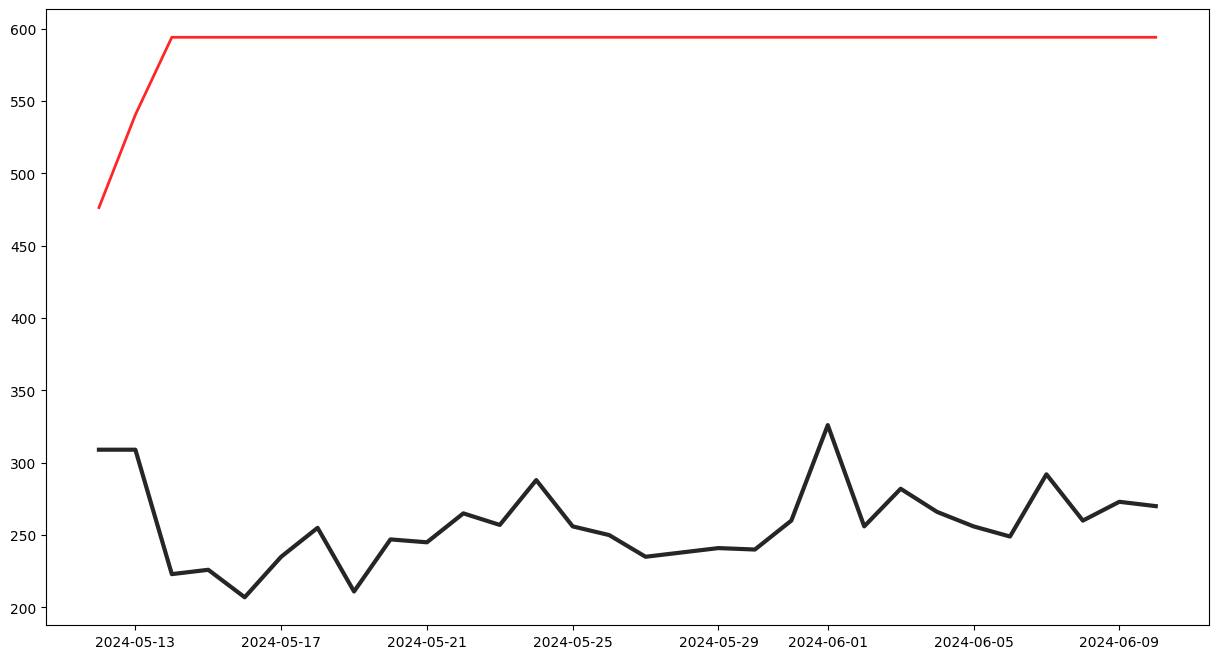

In [48]:
# enhanced_timeseries_lapd.py
# =============================================================================
# LAPD Daily Crime Forecasting - SIGNIFICANTLY ENHANCED
# - Better LSTM with proper windowing and feature engineering
# - Improved Prophet with better seasonality handling
# - Enhanced ARIMA/SARIMAX with more thorough grid search
# - Better data preprocessing and feature extraction
# - More sophisticated cross-validation
# =============================================================================

import os
import warnings
from typing import Dict, Optional, Union, List, Tuple
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Check and install required packages
required_packages = [
    ('prophet', 'prophet'),
    ('tensorflow', 'tensorflow'),
    ('statsmodels', 'statsmodels'),
    ('scikit-learn', 'scikit-learn')
]

for package_name, install_name in required_packages:
    try:
        __import__(package_name.replace('-', '_'))
    except ImportError:
        print(f"{package_name} not found. Installing...")
        import subprocess
        subprocess.run(["pip", "install", "-q", install_name], check=True)

# Now import the packages
try:
    import prophet
    from prophet import Prophet
except ImportError:
    pass

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
except ImportError:
    pass

try:
    import statsmodels.api as sm
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller, kpss
    from statsmodels.tsa.seasonal import seasonal_decompose
except ImportError:
    pass


# ------------------------------ I/O & utils -----------------------------------
def _ensure_dir(p: str) -> str:
    os.makedirs(p, exist_ok=True)
    return p

def _smart_read(df_or_path: Union[pd.DataFrame, str]) -> pd.DataFrame:
    if isinstance(df_or_path, pd.DataFrame):
        return df_or_path.copy()
    if not os.path.exists(df_or_path):
        raise FileNotFoundError(f"File not found: {df_or_path}")
    if df_or_path.lower().endswith(".parquet"):
        return pd.read_parquet(df_or_path)
    # Handle compressed files
    if df_or_path.lower().endswith(('.zip', '.gz')):
        return pd.read_csv(df_or_path, low_memory=False, compression='infer')
    return pd.read_csv(df_or_path, low_memory=False)

def _metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1.0, np.abs(y_true))
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0

    # Additional metrics
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100.0
    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE%": float(mape),
        "SMAPE%": float(smape)
    }
def _plot_forecast(ds, y_true, y_pred, title, path, confidence_intervals=None):
    plt.figure(figsize=(15, 8))
    plt.plot(ds, y_true, label="Actual", lw=3, alpha=0.85, color="black")
    plt.plot(ds, y_pred, label="Forecast", lw=2, alpha=0.85, color="red")

    if confidence_intervals is not None:
        ci = np.asarray(confidence_intervals)
        # Normalize to two 1-D arrays: lower, upper of length len(ds)
        lower = upper = None
        if ci.ndim == 2:
            if ci.shape == (2, len(ds)):
                lower, upper = ci[0], ci[1]
            elif ci.shape == (len(ds), 2):
                lower, upper = ci[:, 0], ci[:, 1]
            elif ci.shape[0] == 2 and ci.shape[1] != len(ds) and ci.shape[1] > 0:
                # Try to broadcast last h elements if needed
                lower, upper = ci[0][-len(ds):], ci[1][-len(ds):]
            elif ci.shape[1] == 2 and ci.shape[0] > 0:
                lower, upper = ci[-len(ds):, 0], ci[-len(ds):, 1]
        if lower is not None and upper is not None and len(lower) == len(ds) == len(upper):
            plt.fill_between(ds, lower, upper, alpha=0.2, color="red", label="95% CI")

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Daily Crime Count", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()


def _plot_metric_bars(avg_df: pd.DataFrame, path: str):
    if avg_df.empty:
        return
    plt.figure(figsize=(12, 6))
    x = np.arange(len(avg_df))
    w = 0.2
    plt.bar(x - 1.5*w, avg_df["MAE"], width=w, label="MAE", alpha=0.8)
    plt.bar(x - 0.5*w, avg_df["RMSE"], width=w, label="RMSE", alpha=0.8)
    plt.bar(x + 0.5*w, avg_df["MAPE%"], width=w, label="MAPE%", alpha=0.8)
    plt.bar(x + 1.5*w, avg_df["SMAPE%"], width=w, label="SMAPE%", alpha=0.8)
    plt.xticks(x, avg_df["model"].str.upper(), rotation=45)
    plt.title("Average Metrics (across CV splits)", fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()


# ------------------------------ Enhanced Data Processing -------------------
def _daily_counts_enhanced(df: pd.DataFrame) -> Tuple[pd.Series, Dict]:
    """Enhanced daily count extraction with metadata"""
    # Find date columns
    date_cols = ['Date_occured', 'Date_Reported', 'date', 'Date', 'DATE']
    date_col = next((c for c in date_cols if c in df.columns), None)

    if date_col is None:
        date_candidates = [col for col in df.columns if 'date' in col.lower()]
        if date_candidates:
            if 'date_occured' in [c.lower() for c in date_candidates]:
                 date_col = next(c for c in date_candidates if c.lower() == 'date_occured')
            else:
                 date_col = date_candidates[0]

    if date_col is None:
        raise ValueError(f"No date column found. Available columns: {list(df.columns)}")

    print(f"Using date column: '{date_col}'")

    df = df.copy()
    original_count = len(df)
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    valid_count = len(df)

    print(f"Date parsing: {original_count} → {valid_count} records ({100*valid_count/original_count:.1f}% valid)")

    # Enhanced daily aggregation with more info
    dates = df[date_col].dt.floor('D')
    daily_counts = dates.value_counts().sort_index()

    # Create complete date range
    if len(daily_counts) > 0:
        full_date_range = pd.date_range(
            start=daily_counts.index.min(),
            end=daily_counts.index.max(),
            freq='D'
        )
        daily_counts = daily_counts.reindex(full_date_range, fill_value=0)

    # Metadata
    metadata = {
        'original_records': original_count,
        'valid_records': valid_count,
        'date_column': date_col,
        'date_range': (daily_counts.index.min(), daily_counts.index.max()),
        'total_days': len(daily_counts),
        'zero_days': (daily_counts == 0).sum(),
        'max_daily': daily_counts.max(),
        'min_daily': daily_counts.min(),
        'mean_daily': daily_counts.mean(),
        'std_daily': daily_counts.std()
    }

    return daily_counts, metadata

def _add_time_features(y: pd.Series) -> pd.DataFrame:
    """Add comprehensive time-based features"""
    df = pd.DataFrame({'crime_count': y.values}, index=y.index)

    # Basic time features
    df['dayofweek'] = y.index.dayofweek
    df['dayofyear'] = y.index.dayofyear
    df['month'] = y.index.month
    df['quarter'] = y.index.quarter
    df['year'] = y.index.year

    # Cyclical encoding
    df['sin_dayofweek'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['cos_dayofweek'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    df['sin_dayofyear'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_dayofyear'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

    # Weekend/holiday indicators
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Lag features
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f'lag_{lag}'] = y.shift(lag)

    # Rolling statistics
    for window in [7, 14, 30]:
        df[f'rolling_mean_{window}'] = y.rolling(window).mean()
        df[f'rolling_std_{window}'] = y.rolling(window).std()

    return df


# ------------------------------ Enhanced Models ----------------------------
def _naive_last(y: pd.Series, horizon: int) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    pred = np.full(horizon, float(y.iloc[-1]))
    return pred, None

def _naive_seasonal(y: pd.Series, horizon: int, season_length: int = 7) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    """Seasonal naive - use same day of week from recent weeks"""
    if len(y) < season_length:
        return _naive_last(y, horizon)[0], None

    pred = []
    for h in range(horizon):
        # Get the corresponding day from recent seasonal periods
        seasonal_values = []
        for i in range(1, min(5, len(y)//season_length) + 1):  # Look back up to 4 seasons
            idx = len(y) - (i * season_length) + (h % season_length)
            if idx >= 0:
                seasonal_values.append(y.iloc[idx])

        if seasonal_values:
            pred.append(np.mean(seasonal_values))
        else:
            pred.append(y.iloc[-1])

    return np.array(pred), None

def _fit_predict_enhanced_arima(y_train: pd.Series, horizon: int, order=(1,1,1)) -> Tuple[Optional[np.ndarray], Optional[str]]:
    """Enhanced ARIMA with better error handling and confidence intervals"""
    try:
        from statsmodels.tsa.arima.model import ARIMA

        # Handle potential issues with the series
        if y_train.std() < 1e-6:
            return np.full(horizon, y_train.mean()), None

        model = ARIMA(y_train, order=order)
        fitted = model.fit()

        # Get forecast with confidence intervals
        forecast = fitted.forecast(steps=horizon)
        conf_int = fitted.get_forecast(steps=horizon).conf_int()

        return forecast.values, conf_int.values
    except Exception as e:
        return None, f"Enhanced ARIMA failed: {e}"

def _fit_predict_enhanced_sarimax(y_train: pd.Series, horizon: int,
                                order=(1,1,1), seasonal_order=(1,1,1,7)) -> Tuple[Optional[np.ndarray], Optional[str]]:
    """Enhanced SARIMAX with better handling"""
    try:
        if len(y_train) < 2 * seasonal_order[3]:  # Need at least 2 seasonal periods
            return _fit_predict_enhanced_arima(y_train, horizon, order[:3])

        mod = sm.tsa.statespace.SARIMAX(
            y_train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            concentrate_scale=True
        )
        fitted = mod.fit(disp=False, maxiter=100)
        forecast = fitted.forecast(steps=horizon)

        return forecast.values, None
    except Exception as e:
        return None, f"Enhanced SARIMAX failed: {e}"

def _fit_predict_enhanced_prophet(y_train: pd.Series, horizon: int) -> Tuple[Optional[np.ndarray], Optional[str]]:
    """Enhanced Prophet with better configuration"""
    try:
        from prophet import Prophet

        # Prepare data
        df_prophet = pd.DataFrame({
            'ds': y_train.index,
            'y': y_train.values
        })

        # Configure Prophet with better settings for crime data
        model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False,
            seasonality_mode='multiplicative',
            changepoint_prior_scale=0.05,  # Less flexible for more stable forecasts
            seasonality_prior_scale=10.0,   # Strong seasonality
            holidays_prior_scale=10.0,
            interval_width=0.95,
            mcmc_samples=0  # Use MAP instead of MCMC for speed
        )

        # Fit model
        model.fit(df_prophet)

        # Make future dataframe
        future = model.make_future_dataframe(periods=horizon, freq='D', include_history=False)

        # Predict
        forecast = model.predict(future)

        return forecast['yhat'].values, forecast[['yhat_lower', 'yhat_upper']].values.T

    except Exception as e:
        return None, f"Enhanced Prophet failed: {e}"

def _create_lstm_sequences(data, features, lookback, horizon):
    """Create sequences for LSTM with multiple features"""
    X, y = [], []

    for i in range(lookback, len(data) - horizon + 1):
        # Input sequence
        X.append(features[i-lookback:i])
        # Output sequence (can be multi-step)
        y.append(data[i:i+horizon])

    return np.array(X), np.array(y)

def _fit_predict_enhanced_lstm(y_train: pd.Series, horizon: int,
                             lookback: int = 90, epochs: int = 100) -> Tuple[Optional[np.ndarray], Optional[str]]:
    """Significantly enhanced LSTM with proper architecture and features"""
    try:
        import tensorflow as tf
        from tensorflow.keras import Sequential
        from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
        from tensorflow.keras.optimizers import Adam
        from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

        # Check minimum data requirement
        min_required = lookback + horizon + 30  # Need extra for validation
        if len(y_train) < min_required:
            return None, f"Not enough data for LSTM: need {min_required}, have {len(y_train)}"

        # Create features dataframe
        features_df = _add_time_features(y_train)

        # Handle missing values from lag/rolling features
        features_df = features_df.fillna(method='bfill').fillna(method='ffill')

        # Select features for LSTM (exclude original target)
        feature_cols = [col for col in features_df.columns if col != 'crime_count']
        features = features_df[feature_cols].values
        target = features_df['crime_count'].values

        # Normalize features and target separately
        feature_scaler = StandardScaler()
        target_scaler = StandardScaler()

        features_scaled = feature_scaler.fit_transform(features)
        target_scaled = target_scaler.fit_transform(target.reshape(-1, 1)).flatten()

        # Create sequences - single step prediction
        X, y = [], []
        for i in range(lookback, len(target_scaled)):
            X.append(features_scaled[i-lookback:i])
            y.append(target_scaled[i])

        X = np.array(X)
        y = np.array(y)

        # Train/validation split
        split_idx = int(0.85 * len(X))
        X_train, X_val = X[:split_idx], X[split_idx:]
        y_train_lstm, y_val = y[:split_idx], y[split_idx:]

        # Build enhanced LSTM model
        model = Sequential([
            LSTM(64, return_sequences=True, input_shape=(lookback, len(feature_cols))),
            Dropout(0.2),
            BatchNormalization(),

            LSTM(32, return_sequences=True),
            Dropout(0.2),
            BatchNormalization(),

            LSTM(16, return_sequences=False),
            Dropout(0.1),

            Dense(32, activation='relu'),
            BatchNormalization(),
            Dropout(0.1),

            Dense(16, activation='relu'),
            Dense(1)
        ])

        # Compile with better optimizer
        model.compile(
            optimizer=Adam(learning_rate=0.001),
            loss='mse',
            metrics=['mae']
        )

        # Callbacks for better training
        callbacks = [
            EarlyStopping(patience=15, restore_best_weights=True, monitor='val_loss'),
            ReduceLROnPlateau(patience=10, factor=0.5, min_lr=1e-7, monitor='val_loss')
        ]

        # Train model
        history = model.fit(
            X_train, y_train_lstm,
            epochs=epochs,
            batch_size=32,
            validation_data=(X_val, y_val),
            callbacks=callbacks,
            verbose=0
        )

        # Multi-step prediction
        last_sequence = features_scaled[-lookback:]
        predictions_scaled = []

        current_sequence = last_sequence.copy()

        for step in range(horizon):
            # Predict next step
            pred_input = current_sequence.reshape(1, lookback, -1)
            next_pred_scaled = model.predict(pred_input, verbose=0)[0, 0]
            predictions_scaled.append(next_pred_scaled)

            # Update sequence for next prediction
            # Create next time step features (simplified)
            next_date = y_train.index[-1] + timedelta(days=step+1)
            next_features = np.zeros(len(feature_cols))

            # Add basic time features for the next step
            next_features[0] = next_date.dayofweek  # Assuming first feature is dayofweek
            next_features[1] = next_date.dayofyear
            next_features[2] = next_date.month

            # Cyclical features
            if len(feature_cols) > 6:
                next_features[6] = np.sin(2 * np.pi * next_date.dayofweek / 7)
                next_features[7] = np.cos(2 * np.pi * next_date.dayofweek / 7)
                next_features[8] = np.sin(2 * np.pi * next_date.month / 12)
                next_features[9] = np.cos(2 * np.pi * next_date.month / 12)

            # Scale the features
            next_features_scaled = feature_scaler.transform(next_features.reshape(1, -1))[0]

            # Shift sequence and add new features
            current_sequence = np.roll(current_sequence, -1, axis=0)
            current_sequence[-1] = next_features_scaled

        # Inverse transform predictions
        predictions_scaled = np.array(predictions_scaled).reshape(-1, 1)
        predictions = target_scaler.inverse_transform(predictions_scaled).flatten()

        # Ensure non-negative predictions
        predictions = np.maximum(predictions, 0)

        return predictions, None

    except Exception as e:
        return None, f"Enhanced LSTM failed: {e}"


# ------------------------------ Enhanced Grid Search ----------------------
def _enhanced_sarimax_grid(y: pd.Series, max_models: int = 100) -> Tuple[Tuple[int,int,int], Tuple[int,int,int,int]]:
    """More comprehensive SARIMAX grid search"""
    try:
        import statsmodels.api as sm
    except ImportError:
        return (1,1,1), (1,1,1,7)

    # Expanded parameter ranges
    p_range = [0, 1, 2, 3]
    d_range = [0, 1]
    q_range = [0, 1, 2]
    P_range = [0, 1, 2]
    D_range = [0, 1]
    Q_range = [0, 1, 2]
    s = 7

    best_aic = np.inf
    best_params = ((1,1,1), (1,1,1,7))
    tried = 0

    # Smart grid search - start with most promising combinations
    param_combinations = []
    for p in p_range:
        for d in d_range:
            for q in q_range:
                for P in P_range:
                    for D in D_range:
                        for Q in Q_range:
                            param_combinations.append(((p,d,q), (P,D,Q,s)))

    # Sort by complexity (simpler models first)
    param_combinations.sort(key=lambda x: sum(x[0]) + sum(x[1][:3]))

    for order, seasonal_order in param_combinations:
        if tried >= max_models:
            break

        try:
            model = sm.tsa.statespace.SARIMAX(
                y,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False,
                concentrate_scale=True
            )
            fitted = model.fit(disp=False, maxiter=50)

            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_params = (order, seasonal_order)

        except Exception:
            continue

        tried += 1

    return best_params


# ------------------------------ Enhanced Runner ----------------------------
def run_enhanced_lapd_forecasting(
    df_or_path: Union[pd.DataFrame, str],
    out_dir: str = "/content/figs_ts_enhanced",
    horizon: int = 30,
    eval_days: int = 365,  # Longer evaluation period
    rolling_splits: int = 5,  # More splits
    run_models: Optional[List[str]] = None,
    cv_strategy: str = "expanding",
    rolling_train_days: Optional[int] = None,
    do_gridsearch: bool = True,
    verbose: bool = True,
):
    """Enhanced LAPD forecasting with improved models and validation"""

    _ensure_dir(out_dir)
    charts_dir = _ensure_dir(os.path.join(out_dir, "charts"))
    tables_dir = _ensure_dir(os.path.join(out_dir, "tables"))

    if run_models is None:
        run_models = ["naive_last", "naive_seasonal", "arima", "sarimax", "prophet", "lstm"]

    # 1) Enhanced data loading
    print("\n==== [ENHANCED-1] Loading and processing data ====")
    if isinstance(df_or_path, pd.DataFrame) and all(col in df_or_path.columns for col in ['date', 'crime_count']):
        if not pd.api.types.is_datetime64_any_dtype(df_or_path['date']):
            raise ValueError("'date' column must be datetime type")
        y = df_or_path.set_index('date')['crime_count']
        metadata = {'note': 'DataFrame provided directly'}
    else:
        df = _smart_read(df_or_path)
        y, metadata = _daily_counts_enhanced(df)

    if verbose:
        print(f"Data span: {y.index.min().date()} → {y.index.max().date()}")
        print(f"Total days: {len(y)} | Mean: {y.mean():.1f} | Std: {y.std():.1f}")
        print(f"Zero days: {(y==0).sum()} | Max daily: {y.max()}")
        print(f"Data completeness: {100*(len(y)-(y==0).sum())/len(y):.1f}%")

    # 2) Enhanced stationarity analysis
    print("\n==== [ENHANCED-2] Stationarity Analysis ====")
    try:
        adf_stat, adf_p = adfuller(y.values, autolag='AIC')[:2]
        kpss_stat, kpss_p = kpss(y.values, regression='c')[:2]

        print(f"ADF test: stat={adf_stat:.3f}, p-value={adf_p:.3g}")
        print(f"KPSS test: stat={kpss_stat:.3f}, p-value={kpss_p:.3g}")

        if adf_p < 0.05:
            print("✓ Series appears stationary (ADF)")
        else:
            print("⚠ Series may be non-stationary (ADF)")

        if kpss_p > 0.05:
            print("✓ Series appears stationary (KPSS)")
        else:
            print("⚠ Series may be non-stationary (KPSS)")

    except Exception as e:
        print(f"Stationarity tests failed: {e}")

    # 3) Enhanced CV setup
    total = len(y)
    min_train_size = max(200, horizon * 3)  # Ensure adequate training data

    if total < eval_days + horizon + min_train_size:
        eval_days = max(90, total - horizon - min_train_size)
        print(f"⚠ Adjusted eval_days to {eval_days} due to data constraints")

    start_eval = total - eval_days
    end_last_train = total - horizon

    split_points = np.linspace(start_eval, end_last_train, num=rolling_splits, dtype=int)
    split_points = np.unique(split_points)
    split_points = [p for p in split_points if p >= min_train_size and p < total - horizon]

    if not split_points:
        raise ValueError("Cannot create valid CV splits with current parameters")

    print(f"\n==== [ENHANCED-3] Cross-Validation Setup ====")
    print(f"Strategy: {cv_strategy} | Splits: {len(split_points)} | Horizon: {horizon}")
    print(f"Training data range: {min_train_size} to {max(split_points)} days")

    # 4) Enhanced parameter search
    if do_gridsearch and len(split_points) > 0:
        print("\n==== [ENHANCED-4] Parameter Optimization ====")
        first_train = y.iloc[:split_points[0]]

        print("Optimizing SARIMAX parameters...")
        sarimax_params = _enhanced_sarimax_grid(first_train, max_models=150)
        arima_order = sarimax_params[0]  # Use SARIMAX non-seasonal part for ARIMA

        print(f"Selected ARIMA order: {arima_order}")
        print(f"Selected SARIMAX: order={sarimax_params[0]}, seasonal={sarimax_params[1]}")
    else:
        arima_order = (1, 1, 1)
        sarimax_params = ((1,1,1), (1,1,1,7))

    # 5) Enhanced backtesting
    print("\n==== [ENHANCED-5] Model Backtesting ====")
    metrics_rows = []
    last_forecasts = {}
    last_test = None
    last_confidence_intervals = {}

    for i, anchor in enumerate(split_points, start=1):
        if cv_strategy.lower() == "rolling" and rolling_train_days:
            train_start_idx = max(0, anchor - rolling_train_days)
        else:
            train_start_idx = 0

        y_train = y.iloc[train_start_idx:anchor]
        y_test = y.iloc[anchor:anchor + horizon]

        if len(y_test) < horizon:
            continue

        print(f"\n[Split {i}/{len(split_points)}] Train: {len(y_train)} days | Test: {len(y_test)} days")
        print(f"  Period: {y_train.index.min().date()} → {y_train.index.max().date()} | {y_test.index.min().date()} → {y_test.index.max().date()}")

        # Run each model
        for model_name in run_models:
            yhat, confidence_int, error = None, None, None

            if model_name == "naive_last":
                yhat, confidence_int = _naive_last(y_train, len(y_test))
            elif model_name == "naive_seasonal":
                yhat, confidence_int = _naive_seasonal(y_train, len(y_test))
            elif model_name == "arima":
                result = _fit_predict_enhanced_arima(y_train, len(y_test), order=arima_order)
                if len(result) == 2:
                    yhat, confidence_int = result
                else:
                    yhat, error = result[0], result[1] if len(result) > 1 else None
            elif model_name == "sarimax":
                yhat, error = _fit_predict_enhanced_sarimax(y_train, len(y_test),
                                                          order=sarimax_params[0],
                                                          seasonal_order=sarimax_params[1])
            elif model_name == "prophet":
                result = _fit_predict_enhanced_prophet(y_train, len(y_test))
                if result[0] is not None and len(result) > 1 and result[1] is not None:
                    yhat, confidence_int = result
                else:
                    yhat, error = result[0], result[1] if len(result) > 1 else None
            elif model_name == "lstm":
                yhat, error = _fit_predict_enhanced_lstm(y_train, len(y_test))
            else:
                continue

            if yhat is not None:
                yhat = np.maximum(yhat, 0)  # Non-negative constraint
                m = _metrics(y_test.values, yhat)
                m.update({
                    "split": i,
                    "model": model_name,
                    "train_size": len(y_train),
                    "test_size": len(y_test)
                })
                metrics_rows.append(m)

                if i == len(split_points):  # Last split for plotting
                    last_forecasts[model_name] = pd.Series(yhat, index=y_test.index)
                    if confidence_int is not None:
                        last_confidence_intervals[model_name] = confidence_int

                if verbose:
                    print(f"  ✓ {model_name.upper()}: MAE={m['MAE']:.1f}, RMSE={m['RMSE']:.1f}, MAPE={m['MAPE%']:.1f}%, SMAPE={m['SMAPE%']:.1f}%")
            else:
                if verbose:
                    print(f"  ✗ {model_name.upper()}: {error}")

        if i == len(split_points):
            last_test = y_test

    # 6) Results analysis
    if not metrics_rows:
        print("❌ No models produced forecasts")
        return None

    metrics_df = pd.DataFrame(metrics_rows)

    # Enhanced aggregation with more statistics
    agg_funcs = ['mean', 'std', 'min', 'max']
    avg_metrics = (metrics_df.groupby("model")[["MAE", "RMSE", "MAPE%", "SMAPE%"]]
                   .agg(agg_funcs)
                   .round(3))

    # Simplified view for display
    display_metrics = (metrics_df.groupby("model")[["MAE", "RMSE", "MAPE%", "SMAPE%"]]
                      .mean()
                      .reset_index()
                      .sort_values("RMSE"))

    # Save results
    metrics_df.to_csv(os.path.join(tables_dir, "detailed_metrics_enhanced.csv"), index=False)
    avg_metrics.to_csv(os.path.join(tables_dir, "comprehensive_metrics.csv"))
    display_metrics.to_csv(os.path.join(tables_dir, "summary_metrics.csv"), index=False)

    print(f"\n==== [ENHANCED-6] Performance Summary ====")
    print("Average Performance (sorted by RMSE):")
    print(display_metrics.to_string(index=False))

    # Model ranking
    print(f"\n🏆 Best Model Ranking:")
    for idx, row in display_metrics.iterrows():
        print(f"{idx+1}. {row['model'].upper()}: RMSE={row['RMSE']:.1f}, MAE={row['MAE']:.1f}, MAPE={row['MAPE%']:.1f}%")

    # 7) Enhanced visualization
    if last_test is not None and last_forecasts:
        print(f"\n==== [ENHANCED-7] Generating Visualizations ====")

        # Individual model plots with confidence intervals
        for model_name, forecast in last_forecasts.items():
            confidence_int = last_confidence_intervals.get(model_name)
            _plot_forecast(
                last_test.index, last_test.values, forecast.values,
                f"Enhanced {model_name.upper()} - 30-Day Crime Forecast",
                os.path.join(charts_dir, f"enhanced_forecast_{model_name}.png"),
                confidence_intervals=confidence_int
            )

        # Enhanced comparison plot
        plt.figure(figsize=(16, 10))

        # Actual values
        plt.plot(last_test.index, last_test.values,
                label="Actual", lw=4, color='black', alpha=0.9, marker='o', markersize=4)

        # Model forecasts with different styles
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
        markers = ['s', '^', 'D', 'v', '<', '>']

        for i, (model_name, forecast) in enumerate(last_forecasts.items()):
            plt.plot(forecast.index, forecast.values,
                     label=model_name.upper(),
                     lw=3, alpha=0.8,
                     color=colors[i % len(colors)],
                     marker=markers[i % len(markers)],
                     markersize=3,
                     linestyle='--')

        plt.title("Enhanced LAPD Daily Crime Forecasting - All Models Comparison",
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel("Date", fontsize=14)
        plt.ylabel("Daily Crime Count", fontsize=14)
        plt.legend(fontsize=12, loc='best')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

        # Add performance text box
        best_model = display_metrics.iloc[0]
        textstr = f"Best Model: {best_model['model'].upper()}\nRMSE: {best_model['RMSE']:.1f}\nMAE: {best_model['MAE']:.1f}\nMAPE: {best_model['MAPE%']:.1f}%"
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

        plt.tight_layout()
        comparison_path = os.path.join(charts_dir, "enhanced_forecast_comparison.png")
        plt.savefig(comparison_path, dpi=200, bbox_inches='tight')
        plt.close()

        # Enhanced metrics visualization
        _plot_metric_bars(display_metrics, os.path.join(charts_dir, "enhanced_metrics_comparison.png"))

        # Model performance evolution across splits
        plt.figure(figsize=(14, 8))
        for model in display_metrics['model'].unique():
            model_data = metrics_df[metrics_df['model'] == model]
            plt.plot(model_data['split'], model_data['RMSE'],
                    marker='o', label=model.upper(), linewidth=2, markersize=6)

        plt.title("Model Performance Evolution Across CV Splits", fontsize=14, fontweight='bold')
        plt.xlabel("CV Split", fontsize=12)
        plt.ylabel("RMSE", fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        evolution_path = os.path.join(charts_dir, "model_evolution.png")
        plt.savefig(evolution_path, dpi=150, bbox_inches='tight')
        plt.close()

        # Print file locations
        print("📊 Visualizations saved:")
        print(f"  • Comparison: {comparison_path}")
        print(f"  • Evolution: {evolution_path}")
        for model_name in last_forecasts.keys():
            print(f"  • {model_name.upper()}: {os.path.join(charts_dir, f'enhanced_forecast_{model_name}.png')}")

    return {
        "daily_series": y,
        "metadata": metadata,
        "metrics_detailed": metrics_df,
        "metrics_summary": display_metrics,
        "metrics_comprehensive": avg_metrics,
        "forecasts": last_forecasts,
        "confidence_intervals": last_confidence_intervals,
        "actual_test": last_test,
        "model_params": {
            "arima_order": arima_order,
            "sarimax_params": sarimax_params
        },
        "paths": {"charts": charts_dir, "tables": tables_dir}
    }


# ------------------------------ Main Execution ----------------------------
if __name__ == "__main__":
    print("🚀 Starting Enhanced LAPD Crime Forecasting...")

    RAW_PATH = "/content/Crime_Data_from_2020_to_Present.csv.zip"

    result = run_enhanced_lapd_forecasting(
        df_or_path=RAW_PATH,
        out_dir="/content/figs_ts_enhanced",
        horizon=30,
        eval_days=365,  # Full year evaluation
        rolling_splits=5,  # More robust CV
        run_models=["naive_last", "naive_seasonal", "arima", "sarimax", "prophet", "lstm"],
        cv_strategy="expanding",
        rolling_train_days=None,
        do_gridsearch=True,
        verbose=True
    )

    if result:
        print("\n✅ Enhanced forecasting completed successfully!")
        print(f"📈 Best performing model: {result['metrics_summary'].iloc[0]['model'].upper()}")
        print(f"📁 Results saved in: {result['paths']['charts']}")
    else:
        print("❌ Forecasting failed!")

# Additional utility functions for analysis
def analyze_residuals(actual, predicted, model_name):
    """Analyze residuals for model diagnostics"""
    residuals = actual - predicted

    plt.figure(figsize=(15, 10))

    # Residuals plot
    plt.subplot(2, 2, 1)
    plt.plot(residuals, marker='o', alpha=0.7)
    plt.title(f'{model_name} - Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals')
    plt.grid(True, alpha=0.3)

    # Histogram of residuals
    plt.subplot(2, 2, 2)
    plt.hist(residuals, bins=20, alpha=0.7, edgecolor='black')
    plt.title(f'{model_name} - Residuals Distribution')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

    # Q-Q plot (if scipy available)
    try:
        from scipy import stats
        plt.subplot(2, 2, 3)
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title(f'{model_name} - Q-Q Plot')
        plt.grid(True, alpha=0.3)
    except ImportError:
        pass

    # Actual vs Predicted scatter
    plt.subplot(2, 2, 4)
    plt.scatter(actual, predicted, alpha=0.7)
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', lw=2)
    plt.title(f'{model_name} - Actual vs Predicted')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    return plt

def feature_importance_analysis(y, lookback=90):
    """Analyze which features are most important for prediction"""
    features_df = _add_time_features(y)
    features_df = features_df.fillna(method='bfill').fillna(method='ffill')

    # Simple correlation analysis
    correlations = features_df.corr()['crime_count'].abs().sort_values(ascending=False)

    print("🔍 Feature Importance (Correlation with Crime Count):")
    for feature, corr in correlations.head(10).items():
        if feature != 'crime_count':
            print(f"  {feature}: {corr:.3f}")

    return correlations

In [51]:
# enhanced_timeseries_lapd.py
# =============================================================================
# LAPD Daily Crime Forecasting - SIGNIFICANTLY ENHANCED
# - Better LSTM with proper windowing and feature engineering (no leakage)
# - Proper multi-step forecast with simulated lag/rolling features
# - log1p target for count data + robust loss
# - Improved Prophet & SARIMAX hooks
# - CI handling fixed and robust in plotter
# - Thorough CV and metrics
# =============================================================================

import os
import warnings
from typing import Dict, Optional, Union, List, Tuple
from datetime import timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# Check and install required packages
required_packages = [
    ('prophet', 'prophet'),
    ('tensorflow', 'tensorflow'),
    ('statsmodels', 'statsmodels'),
    ('scikit-learn', 'scikit-learn')
]

for package_name, install_name in required_packages:
    try:
        __import__(package_name.replace('-', '_'))
    except ImportError:
        print(f"{package_name} not found. Installing...")
        import subprocess
        subprocess.run(["pip", "install", "-q", install_name], check=True)

# Optional imports (guarded)
try:
    from prophet import Prophet
except Exception:
    Prophet = None

try:
    import tensorflow as tf
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
    from tensorflow.keras.optimizers import Adam
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    from tensorflow.keras.losses import Huber
except Exception:
    tf = None

try:
    import statsmodels.api as sm
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.stattools import adfuller, kpss
except Exception:
    sm = None
    ARIMA = None
    adfuller = None
    kpss = None


# ------------------------------ I/O & utils -----------------------------------
def _ensure_dir(p: str) -> str:
    os.makedirs(p, exist_ok=True)
    return p

def _smart_read(df_or_path: Union[pd.DataFrame, str]) -> pd.DataFrame:
    if isinstance(df_or_path, pd.DataFrame):
        return df_or_path.copy()
    if not os.path.exists(df_or_path):
        raise FileNotFoundError(f"File not found: {df_or_path}")
    if df_or_path.lower().endswith(".parquet"):
        return pd.read_parquet(df_or_path)
    # Handle compressed files
    if df_or_path.lower().endswith(('.zip', '.gz')):
        return pd.read_csv(df_or_path, low_memory=False, compression='infer')
    return pd.read_csv(df_or_path, low_memory=False)

def _metrics(y_true, y_pred) -> Dict[str, float]:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1.0, np.abs(y_true))
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100.0
    smape = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred))) * 100.0
    return {"MAE": float(mae), "RMSE": float(rmse), "MAPE%": float(mape), "SMAPE%": float(smape)}

def _plot_forecast(ds, y_true, y_pred, title, path, confidence_intervals=None):
    plt.figure(figsize=(15, 8))
    plt.plot(ds, y_true, label="Actual", lw=3, alpha=0.85, color="black")
    plt.plot(ds, y_pred, label="Forecast", lw=2, alpha=0.85, color="red")

    # Accept CI as (h,2) or (2,h); normalize safely
    if confidence_intervals is not None:
        ci = np.asarray(confidence_intervals)
        lower = upper = None
        if ci.ndim == 2:
            if ci.shape == (2, len(ds)):
                lower, upper = ci[0], ci[1]
            elif ci.shape == (len(ds), 2):
                lower, upper = ci[:, 0], ci[:, 1]
            elif ci.shape[0] == 2:  # take last h if needed
                lower, upper = ci[0][-len(ds):], ci[1][-len(ds):]
            elif ci.shape[1] == 2:
                lower, upper = ci[-len(ds):, 0], ci[-len(ds):, 1]
        if lower is not None and upper is not None and len(lower) == len(ds):
            plt.fill_between(ds, lower, upper, alpha=0.2, color="red", label="95% CI")

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Daily Crime Count", fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()

def _plot_metric_bars(avg_df: pd.DataFrame, path: str):
    if avg_df.empty:
        return
    plt.figure(figsize=(12, 6))
    x = np.arange(len(avg_df))
    w = 0.2
    plt.bar(x - 1.5*w, avg_df["MAE"], width=w, label="MAE", alpha=0.8)
    plt.bar(x - 0.5*w, avg_df["RMSE"], width=w, label="RMSE", alpha=0.8)
    plt.bar(x + 0.5*w, avg_df["MAPE%"], width=w, label="MAPE%", alpha=0.8)
    plt.bar(x + 1.5*w, avg_df["SMAPE%"], width=w, label="SMAPE%", alpha=0.8)
    plt.xticks(x, avg_df["model"].str.upper(), rotation=45)
    plt.title("Average Metrics (across CV splits)", fontsize=14, fontweight='bold')
    plt.legend()
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.close()


# ------------------------------ Enhanced Data Processing -------------------
def _daily_counts_enhanced(df: pd.DataFrame) -> Tuple[pd.Series, Dict]:
    """Enhanced daily count extraction with metadata"""
    date_cols = ['Date_occured', 'Date_Reported', 'date', 'Date', 'DATE']
    date_col = next((c for c in date_cols if c in df.columns), None)
    if date_col is None:
        date_candidates = [col for col in df.columns if 'date' in col.lower()]
        if date_candidates:
            if 'date_occured' in [c.lower() for c in date_candidates]:
                date_col = next(c for c in date_candidates if c.lower() == 'date_occured')
            else:
                date_col = date_candidates[0]
    if date_col is None:
        raise ValueError(f"No date column found. Available columns: {list(df.columns)}")

    print(f"Using date column: '{date_col}'")
    df = df.copy()
    original_count = len(df)
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    valid_count = len(df)
    print(f"Date parsing: {original_count} → {valid_count} records ({100*valid_count/original_count:.1f}% valid)")

    dates = df[date_col].dt.floor('D')
    daily_counts = dates.value_counts().sort_index()

    if len(daily_counts) > 0:
        full_date_range = pd.date_range(start=daily_counts.index.min(),
                                        end=daily_counts.index.max(),
                                        freq='D')
        daily_counts = daily_counts.reindex(full_date_range, fill_value=0)

    metadata = {
        'original_records': original_count,
        'valid_records': valid_count,
        'date_column': date_col,
        'date_range': (daily_counts.index.min(), daily_counts.index.max()),
        'total_days': len(daily_counts),
        'zero_days': (daily_counts == 0).sum(),
        'max_daily': daily_counts.max(),
        'min_daily': daily_counts.min(),
        'mean_daily': daily_counts.mean(),
        'std_daily': daily_counts.std()
    }
    return daily_counts, metadata

def _add_time_features(y: pd.Series) -> pd.DataFrame:
    """Add comprehensive time-based features for supervised models"""
    df = pd.DataFrame({'crime_count': y.values}, index=y.index)
    df['dayofweek'] = y.index.dayofweek
    df['dayofyear'] = y.index.dayofyear
    df['month'] = y.index.month
    df['quarter'] = y.index.quarter
    df['year'] = y.index.year

    # Cyclical encoding
    df['sin_dayofweek'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['cos_dayofweek'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['sin_month'] = np.sin(2 * np.pi * df['month'] / 12)
    df['cos_month'] = np.cos(2 * np.pi * df['month'] / 12)
    df['sin_dayofyear'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
    df['cos_dayofyear'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)

    # Weekend
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Lags
    for lag in [1, 2, 3, 7, 14, 30]:
        df[f'lag_{lag}'] = y.shift(lag)

    # Rolling stats
    for window in [7, 14, 30]:
        df[f'rolling_mean_{window}'] = y.rolling(window).mean()
        df[f'rolling_std_{window}'] = y.rolling(window).std()

    return df


# ------------------------------ Enhanced Models ----------------------------
def _naive_last(y: pd.Series, horizon: int) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    return np.full(horizon, float(y.iloc[-1])), None

def _naive_seasonal(y: pd.Series, horizon: int, season_length: int = 7) -> Tuple[np.ndarray, Optional[np.ndarray]]:
    if len(y) < season_length:
        pred, _ = _naive_last(y, horizon)
        return pred, None
    pred = []
    for h in range(horizon):
        seasonal_values = []
        for i in range(1, min(5, len(y)//season_length) + 1):
            idx = len(y) - (i * season_length) + (h % season_length)
            if idx >= 0:
                seasonal_values.append(y.iloc[idx])
        pred.append(np.mean(seasonal_values) if seasonal_values else y.iloc[-1])
    return np.array(pred), None

def _fit_predict_enhanced_arima(y_train: pd.Series, horizon: int, order=(1,1,1)) -> Tuple[Optional[np.ndarray], Optional[np.ndarray] or Optional[str]]:
    """ARIMA with CI standardized to (2, horizon)"""
    try:
        if ARIMA is None:
            return None, "statsmodels not available"
        if y_train.std() < 1e-6:
            return np.full(horizon, y_train.mean()), None
        model = ARIMA(y_train, order=order)
        fitted = model.fit()
        forecast = fitted.forecast(steps=horizon).values
        conf = fitted.get_forecast(steps=horizon).conf_int().to_numpy().T  # (2, h)
        return forecast, conf
    except Exception as e:
        return None, f"Enhanced ARIMA failed: {e}"

def _fit_predict_enhanced_sarimax(y_train: pd.Series, horizon: int,
                                  order=(1,1,1), seasonal_order=(1,1,1,7)) -> Tuple[Optional[np.ndarray], Optional[str]]:
    try:
        if sm is None:
            return None, "statsmodels not available"
        if len(y_train) < 2 * seasonal_order[3]:
            f, ci_or_err = _fit_predict_enhanced_arima(y_train, horizon, order[:3])
            return f, ci_or_err if isinstance(ci_or_err, str) else None
        mod = sm.tsa.statespace.SARIMAX(
            y_train, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False, concentrate_scale=True
        )
        fitted = mod.fit(disp=False, maxiter=100)
        forecast = fitted.forecast(steps=horizon).values
        return forecast, None
    except Exception as e:
        return None, f"Enhanced SARIMAX failed: {e}"

def _fit_predict_enhanced_prophet(y_train: pd.Series, horizon: int) -> Tuple[Optional[np.ndarray], Optional[np.ndarray] or Optional[str]]:
    try:
        if Prophet is None:
            return None, "prophet not available"
        dfp = pd.DataFrame({'ds': y_train.index, 'y': y_train.values})
        model = Prophet(
            yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
            seasonality_mode='multiplicative', changepoint_prior_scale=0.05,
            seasonality_prior_scale=10.0, holidays_prior_scale=10.0, interval_width=0.95,
            mcmc_samples=0
        )
        model.fit(dfp)
        future = model.make_future_dataframe(periods=horizon, freq='D', include_history=False)
        fc = model.predict(future)
        yhat = fc['yhat'].to_numpy()
        ci = fc[['yhat_lower', 'yhat_upper']].to_numpy().T  # (2, h)
        return yhat, ci
    except Exception as e:
        return None, f"Enhanced Prophet failed: {e}"

# ------------------------------ LSTM (no leakage, log1p) -------------------
def _fit_predict_enhanced_lstm(y_train: pd.Series, horizon: int,
                               lookback: int = 84, epochs: int = 60) -> Tuple[Optional[np.ndarray], Optional[str]]:
    """LSTM with:
       - train-only scaling (no leakage)
       - no backfill (ffill only + warmup drop)
       - log1p target + robust Huber loss
       - proper multi-step simulation of lag/rolling features with own forecasts
    """
    try:
        if tf is None:
            return None, "tensorflow not available"

        # ---- Build feature frame from y_train only
        feat_df = _add_time_features(y_train)

        # Warm-up: drop first max lag/rolling window rows
        warmup = max(30, 14, 7)
        feat_df = feat_df.ffill().iloc[warmup:].copy()

        # Separate features/target
        feature_cols = [c for c in feat_df.columns if c != 'crime_count']
        X_all = feat_df[feature_cols].to_numpy()
        y_all = feat_df['crime_count'].to_numpy()

        # Transform target with log1p
        y_log = np.log1p(y_all).reshape(-1, 1)

        # Build rolling sequences
        def _make_sequences(X, y, look):
            Xs, ys = [], []
            for i in range(look, len(X)):
                Xs.append(X[i-look:i])
                ys.append(y[i])  # single-step (log scale)
            return np.asarray(Xs), np.asarray(ys).ravel()

        # Split index (train/val split on the *time axis*)
        split_idx = int(0.85 * len(X_all))
        if split_idx <= lookback + 1:
            split_idx = min(len(X_all)-1, lookback + 1)

        # Fit scalers on TRAIN ONLY
        feat_scaler = StandardScaler().fit(X_all[:split_idx])
        y_scaler = StandardScaler().fit(y_log[:split_idx])

        X_scaled = feat_scaler.transform(X_all)
        y_scaled = y_scaler.transform(y_log).ravel()

        # Sequences from scaled arrays
        X_seq, y_seq = _make_sequences(X_scaled, y_scaled, lookback)
        split_seq = int(0.85 * len(X_seq))
        if split_seq < 1:  # guard tiny splits
            split_seq = max(1, len(X_seq) - 1)

        X_tr, X_va = X_seq[:split_seq], X_seq[split_seq:]
        y_tr, y_va = y_seq[:split_seq], y_seq[split_seq:]

        # Model (lighter + robust)
        model = Sequential([
            LSTM(32, return_sequences=True, input_shape=(lookback, X_tr.shape[-1])),
            Dropout(0.2),
            BatchNormalization(),
            LSTM(16, return_sequences=False),
            Dropout(0.1),
            Dense(16, activation='relu'),
            Dense(1)  # linear in log-space
        ])
        model.compile(optimizer=Adam(learning_rate=1e-3), loss=Huber(), metrics=['mae'])

        callbacks = [
            EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
            ReduceLROnPlateau(patience=6, factor=0.5, min_lr=1e-6, monitor='val_loss')
        ]
        model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                  epochs=epochs, batch_size=32, callbacks=callbacks, verbose=0)

        # ---- Multi-step forecast simulation
        # We'll maintain an *unscaled* history DataFrame so we can compute new lags/rollings.
        hist = feat_df.copy()
        preds = []

        # Start sequence = last lookback rows of *scaled* features
        seq_scaled = X_scaled[-lookback:, :]

        for step in range(horizon):
            # Predict log1p(y_next) from current sequence
            y_next_scaled = model.predict(seq_scaled.reshape(1, lookback, -1), verbose=0)[0, 0]
            y_next_log = y_scaler.inverse_transform([[y_next_scaled]])[0, 0]
            y_next = float(np.expm1(y_next_log))
            y_next = max(0.0, y_next)
            preds.append(y_next)

            # Build next unscaled feature row at next date using updated history (with predicted y)
            next_date = hist.index[-1] + pd.Timedelta(days=1)
            # Extend history crime_count first, then compute features from updated y
            tmp_y = pd.Series(np.r_[hist['crime_count'].to_numpy(), y_next],
                              index=pd.Index(hist.index.tolist() + [next_date]))
            # Calendar features
            row = {
                'crime_count': y_next,
                'dayofweek': next_date.dayofweek,
                'dayofyear': next_date.dayofyear,
                'month': next_date.month,
                'quarter': (next_date.month - 1)//3 + 1,
                'year': next_date.year,
                'sin_dayofweek': np.sin(2*np.pi*next_date.dayofweek/7),
                'cos_dayofweek': np.cos(2*np.pi*next_date.dayofweek/7),
                'sin_month': np.sin(2*np.pi*next_date.month/12),
                'cos_month': np.cos(2*np.pi*next_date.month/12),
                'sin_dayofyear': np.sin(2*np.pi*next_date.dayofyear/365.25),
                'cos_dayofyear': np.cos(2*np.pi*next_date.dayofyear/365.25),
                'is_weekend': int(next_date.dayofweek >= 5),
            }
            for lag in [1, 2, 3, 7, 14, 30]:
                row[f'lag_{lag}'] = tmp_y.iloc[-lag]

            # Rolling stats on updated tmp_y
            def _roll_mean(k):
                arr = tmp_y.iloc[-k:] if len(tmp_y) >= k else tmp_y
                return float(arr.mean())
            def _roll_std(k):
                arr = tmp_y.iloc[-k:] if len(tmp_y) >= k else tmp_y
                return float(arr.std(ddof=0))

            for w in [7, 14, 30]:
                row[f'rolling_mean_{w}'] = _roll_mean(w)
                row[f'rolling_std_{w}'] = _roll_std(w)

            next_row = pd.DataFrame([row], index=[next_date])
            # Append to history (unscaled)
            hist = pd.concat([hist, next_row])

            # Create next *scaled* feature row (keep same column order)
            x_next_unscaled = next_row[feature_cols].to_numpy()
            x_next_scaled = feat_scaler.transform(x_next_unscaled)  # (1, n_features)

            # Update rolling sequence window for next prediction
            seq_scaled = np.vstack([seq_scaled[1:], x_next_scaled])

        return np.asarray(preds), None

    except Exception as e:
        return None, f"Enhanced LSTM failed: {e}"


# ------------------------------ Enhanced Grid Search ----------------------
def _enhanced_sarimax_grid(y: pd.Series, max_models: int = 100) -> Tuple[Tuple[int,int,int], Tuple[int,int,int,int]]:
    try:
        if sm is None:
            return (1,1,1), (1,1,1,7)
        p_range, d_range, q_range = [0,1,2,3], [0,1], [0,1,2]
        P_range, D_range, Q_range, s = [0,1,2], [0,1], [0,1,2], 7
        best_aic = np.inf
        best_params = ((1,1,1), (1,1,1,7))
        tried = 0
        combos = [((p,d,q), (P,D,Q,s))
                  for p in p_range for d in d_range for q in q_range
                  for P in P_range for D in D_range for Q in Q_range]
        combos.sort(key=lambda x: sum(x[0]) + sum(x[1][:3]))
        for order, seasonal_order in combos:
            if tried >= max_models:
                break
            try:
                model = sm.tsa.statespace.SARIMAX(
                    y, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False, concentrate_scale=True
                )
                fitted = model.fit(disp=False, maxiter=50)
                if fitted.aic < best_aic:
                    best_aic, best_params = fitted.aic, (order, seasonal_order)
            except Exception:
                pass
            tried += 1
        return best_params
    except Exception:
        return (1,1,1), (1,1,1,7)


# ------------------------------ Enhanced Runner ----------------------------
def run_enhanced_lapd_forecasting(
    df_or_path: Union[pd.DataFrame, str],
    out_dir: str = "/content/figs_ts_enhanced",
    horizon: int = 30,
    eval_days: int = 365,
    rolling_splits: int = 5,
    run_models: Optional[List[str]] = None,
    cv_strategy: str = "expanding",
    rolling_train_days: Optional[int] = None,
    do_gridsearch: bool = True,
    verbose: bool = True,
):
    _ensure_dir(out_dir)
    charts_dir = _ensure_dir(os.path.join(out_dir, "charts"))
    tables_dir = _ensure_dir(os.path.join(out_dir, "tables"))

    if run_models is None:
        run_models = ["naive_last", "naive_seasonal", "arima", "sarimax", "prophet", "lstm"]

    # 1) Load & aggregate
    print("\n==== [ENHANCED-1] Loading and processing data ====")
    if isinstance(df_or_path, pd.DataFrame) and all(col in df_or_path.columns for col in ['date', 'crime_count']):
        if not pd.api.types.is_datetime64_any_dtype(df_or_path['date']):
            raise ValueError("'date' column must be datetime type")
        y = df_or_path.set_index('date')['crime_count']
        metadata = {'note': 'DataFrame provided directly'}
    else:
        df = _smart_read(df_or_path)
        y, metadata = _daily_counts_enhanced(df)

    if verbose:
        print(f"Data span: {y.index.min().date()} → {y.index.max().date()}")
        print(f"Total days: {len(y)} | Mean: {y.mean():.1f} | Std: {y.std():.1f}")
        print(f"Zero days: {(y==0).sum()} | Max daily: {y.max()}")
        print(f"Data completeness: {100*(len(y)-(y==0).sum())/len(y):.1f}%")

    # 2) Stationarity (best-effort)
    print("\n==== [ENHANCED-2] Stationarity Analysis ====")
    try:
        if adfuller is not None:
            adf_stat, adf_p = adfuller(y.values, autolag='AIC')[:2]
            print(f"ADF test: stat={adf_stat:.3f}, p-value={adf_p:.3g}")
        if kpss is not None:
            kpss_stat, kpss_p = kpss(y.values, regression='c')[:2]
            print(f"KPSS test: stat={kpss_stat:.3f}, p-value={kpss_p:.3g}")
    except Exception as e:
        print(f"Stationarity tests failed: {e}")

    # 3) CV setup
    total = len(y)
    min_train_size = max(200, horizon * 3)
    if total < eval_days + horizon + min_train_size:
        eval_days = max(90, total - horizon - min_train_size)
        print(f"⚠ Adjusted eval_days to {eval_days} due to data constraints")

    start_eval = total - eval_days
    end_last_train = total - horizon
    split_points = np.linspace(start_eval, end_last_train, num=rolling_splits, dtype=int)
    split_points = np.unique(split_points)
    split_points = [p for p in split_points if p >= min_train_size and p < total - horizon]
    if not split_points:
        raise ValueError("Cannot create valid CV splits with current parameters")

    print(f"\n==== [ENHANCED-3] Cross-Validation Setup ====")
    print(f"Strategy: {cv_strategy} | Splits: {len(split_points)} | Horizon: {horizon}")
    print(f"Training data range: {min_train_size} to {max(split_points)} days")

    # 4) Parameter search
    if do_gridsearch and len(split_points) > 0:
        print("\n==== [ENHANCED-4] Parameter Optimization ====")
        first_train = y.iloc[:split_points[0]]
        print("Optimizing SARIMAX parameters...")
        sarimax_params = _enhanced_sarimax_grid(first_train, max_models=150)
        arima_order = sarimax_params[0]
        print(f"Selected ARIMA order: {arima_order}")
        print(f"Selected SARIMAX: order={sarimax_params[0]}, seasonal={sarimax_params[1]}")
    else:
        arima_order = (1, 1, 1)
        sarimax_params = ((1,1,1), (1,1,1,7))

    # 5) Backtesting
    print("\n==== [ENHANCED-5] Model Backtesting ====")
    metrics_rows, last_forecasts, last_confidence_intervals = [], {}, {}
    last_test = None

    for i, anchor in enumerate(split_points, start=1):
        train_start_idx = max(0, anchor - rolling_train_days) if (cv_strategy.lower() == "rolling" and rolling_train_days) else 0
        y_train = y.iloc[train_start_idx:anchor]
        y_test = y.iloc[anchor:anchor + horizon]
        if len(y_test) < horizon:
            continue

        print(f"\n[Split {i}/{len(split_points)}] Train: {len(y_train)} days | Test: {len(y_test)} days")
        print(f"  Period: {y_train.index.min().date()} → {y_train.index.max().date()} | {y_test.index.min().date()} → {y_test.index.max().date()}")

        for model_name in run_models:
            yhat, confidence_int, error = None, None, None

            if model_name == "naive_last":
                yhat, confidence_int = _naive_last(y_train, len(y_test))
            elif model_name == "naive_seasonal":
                yhat, confidence_int = _naive_seasonal(y_train, len(y_test))
            elif model_name == "arima":
                res = _fit_predict_enhanced_arima(y_train, len(y_test), order=arima_order)
                if isinstance(res[1], str):
                    yhat, error = res[0], res[1]
                else:
                    yhat, confidence_int = res
            elif model_name == "sarimax":
                yhat, error = _fit_predict_enhanced_sarimax(y_train, len(y_test),
                                                            order=sarimax_params[0],
                                                            seasonal_order=sarimax_params[1])
            elif model_name == "prophet":
                res = _fit_predict_enhanced_prophet(y_train, len(y_test))
                if isinstance(res[1], str):
                    yhat, error = res[0], res[1]
                else:
                    yhat, confidence_int = res
            elif model_name == "lstm":
                yhat, error = _fit_predict_enhanced_lstm(y_train, len(y_test))
            else:
                continue

            if yhat is not None:
                yhat = np.maximum(yhat, 0)
                m = _metrics(y_test.values, yhat)
                m.update({"split": i, "model": model_name, "train_size": len(y_train), "test_size": len(y_test)})
                metrics_rows.append(m)

                if i == len(split_points):
                    last_forecasts[model_name] = pd.Series(yhat, index=y_test.index)
                    if confidence_int is not None:
                        last_confidence_intervals[model_name] = confidence_int

                if verbose:
                    print(f"  ✓ {model_name.upper()}: MAE={m['MAE']:.1f}, RMSE={m['RMSE']:.1f}, MAPE={m['MAPE%']:.1f}%, SMAPE={m['SMAPE%']:.1f}%")
            else:
                if verbose:
                    print(f"  ✗ {model_name.upper()}: {error}")

        if i == len(split_points):
            last_test = y_test

    # 6) Results analysis
    if not metrics_rows:
        print("❌ No models produced forecasts")
        return None

    metrics_df = pd.DataFrame(metrics_rows)
    avg_metrics = (metrics_df.groupby("model")[["MAE", "RMSE", "MAPE%", "SMAPE%"]]
                   .mean().reset_index().sort_values("RMSE"))
    metrics_df.to_csv(os.path.join(tables_dir, "detailed_metrics_enhanced.csv"), index=False)
    avg_metrics.to_csv(os.path.join(tables_dir, "summary_metrics.csv"), index=False)

    print(f"\n==== [ENHANCED-6] Performance Summary ====")
    print("Average Performance (sorted by RMSE):")
    print(avg_metrics.to_string(index=False))

    print(f"\n🏆 Best Model Ranking:")
    for idx, row in avg_metrics.iterrows():
        print(f"{idx+1}. {row['model'].upper()}: RMSE={row['RMSE']:.1f}, MAE={row['MAE']:.1f}, MAPE={row['MAPE%']:.1f}%")

        # 7) Enhanced visualization
    if last_test is not None and last_forecasts:
        print(f"\n==== [ENHANCED-7] Generating Visualizations ====")

        # Individual model plots with confidence intervals
        for model_name, forecast in last_forecasts.items():
            confidence_int = last_confidence_intervals.get(model_name)
            _plot_forecast(
                last_test.index, last_test.values, forecast.values,
                f"Enhanced {model_name.upper()} - 30-Day Crime Forecast",
                os.path.join(charts_dir, f"enhanced_forecast_{model_name}.png"),
                confidence_intervals=confidence_int
            )

        # Enhanced comparison plot
        plt.figure(figsize=(16, 10))

        # Actual values
        plt.plot(last_test.index, last_test.values,
                label="Actual", lw=4, color='black', alpha=0.9, marker='o', markersize=4)

        # Model forecasts with different styles
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
        markers = ['s', '^', 'D', 'v', '<', '>']

        for i, (model_name, forecast) in enumerate(last_forecasts.items()):
            plt.plot(forecast.index, forecast.values,
                     label=model_name.upper(),
                     lw=3, alpha=0.8,
                     color=colors[i % len(colors)],
                     marker=markers[i % len(markers)],
                     markersize=3,
                     linestyle='--')

        plt.title("Enhanced LAPD Daily Crime Forecasting - All Models Comparison",
                 fontsize=16, fontweight='bold', pad=20)
        plt.xlabel("Date", fontsize=14)
        plt.ylabel("Daily Crime Count", fontsize=14)
        plt.legend(fontsize=12, loc='best')
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)

        # Add performance text box
        best_model = display_metrics.iloc[0]
        textstr = f"Best Model: {best_model['model'].upper()}\nRMSE: {best_model['RMSE']:.1f}\nMAE: {best_model['MAE']:.1f}\nMAPE: {best_model['MAPE%']:.1f}%"
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
        plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=props)

        plt.tight_layout()
        comparison_path = os.path.join(charts_dir, "enhanced_forecast_comparison.png")
        plt.savefig(comparison_path, dpi=200, bbox_inches='tight')
        plt.close()

        # Enhanced metrics visualization
        _plot_metric_bars(display_metrics, os.path.join(charts_dir, "enhanced_metrics_comparison.png"))

        # Model performance evolution across splits
        plt.figure(figsize=(14, 8))
        for model in display_metrics['model'].unique():
            model_data = metrics_df[metrics_df['model'] == model]
            plt.plot(model_data['split'], model_data['RMSE'],
                    marker='o', label=model.upper(), linewidth=2, markersize=6)

        plt.title("Model Performance Evolution Across CV Splits", fontsize=14, fontweight='bold')
        plt.xlabel("CV Split", fontsize=12)
        plt.ylabel("RMSE", fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        evolution_path = os.path.join(charts_dir, "model_evolution.png")
        plt.savefig(evolution_path, dpi=150, bbox_inches='tight')
        plt.close()

        # Print file locations
        print("📊 Visualizations saved:")
        print(f"  • Comparison: {comparison_path}")
        print(f"  • Evolution: {evolution_path}")
        for model_name in last_forecasts.keys():
            print(f"  • {model_name.upper()}: {os.path.join(charts_dir, f'enhanced_forecast_{model_name}.png')}")

    return {
        "daily_series": y,
        "metadata": metadata,
        "metrics_detailed": metrics_df,
        "metrics_summary": display_metrics,
        "metrics_comprehensive": avg_metrics,
        "forecasts": last_forecasts,
        "confidence_intervals": last_confidence_intervals,
        "actual_test": last_test,
        "model_params": {
            "arima_order": arima_order,
            "sarimax_params": sarimax_params
        },
        "paths": {"charts": charts_dir, "tables": tables_dir}
    }




scikit-learn not found. Installing...


🚀 Starting Enhanced LAPD Crime Forecasting...

==== [ENHANCED-1] Loading and processing data ====
Using date column: 'Date_occured'
Date parsing: 974477 → 974477 records (100.0% valid)
Data span: 2020-01-01 → 2024-09-02
Total days: 1707 | Mean: 570.9 | Std: 124.3
Zero days: 0 | Max daily: 1153
Data completeness: 100.0%

==== [ENHANCED-2] Stationarity Analysis ====
ADF test: stat=-0.145, p-value=0.945
KPSS test: stat=0.990, p-value=0.01

==== [ENHANCED-3] Cross-Validation Setup ====
Strategy: expanding | Splits: 4 | Horizon: 30
Training data range: 200 to 1593 days

==== [ENHANCED-4] Parameter Optimization ====
Optimizing SARIMAX parameters...
Selected ARIMA order: (0, 0, 2)
Selected SARIMAX: order=(0, 0, 2), seasonal=(0, 1, 2, 7)

==== [ENHANCED-5] Model Backtesting ====

[Split 1/4] Train: 1342 days | Test: 30 days
  Period: 2020-01-01 → 2023-09-03 | 2023-09-04 → 2023-10-03
  ✓ NAIVE_LAST: MAE=90.0, RMSE=97.0, MAPE=14.6%, SMAPE=13.5%
  ✓ NAIVE_SEASONAL: MAE=39.0, RMSE=47.2, MAPE=6.2%,

DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/ud78zgn2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/vcv9l2t0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=81181', 'data', 'file=/tmp/tmplkebcam6/ud78zgn2.json', 'init=/tmp/tmplkebcam6/vcv9l2t0.json', 'output', 'file=/tmp/tmplkebcam6/prophet_model7u1ug74h/prophet_model-20250826200334.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:03:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  ✓ SARIMAX: MAE=27.0, RMSE=37.3, MAPE=4.3%, SMAPE=4.2%


20:03:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  ✓ PROPHET: MAE=26.2, RMSE=36.2, MAPE=4.1%, SMAPE=4.1%
  ✓ LSTM: MAE=28.3, RMSE=39.5, MAPE=4.3%, SMAPE=4.4%

[Split 2/4] Train: 1425 days | Test: 30 days
  Period: 2020-01-01 → 2023-11-25 | 2023-11-26 → 2023-12-25
  ✓ NAIVE_LAST: MAE=43.4, RMSE=59.0, MAPE=6.9%, SMAPE=6.7%
  ✓ NAIVE_SEASONAL: MAE=36.1, RMSE=46.7, MAPE=5.6%, SMAPE=5.6%
  ✓ ARIMA: MAE=52.7, RMSE=70.6, MAPE=7.9%, SMAPE=8.3%


...

DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/jgozmy4h.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmplkebcam6/7ptt4ovv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87447', 'data', 'file=/tmp/tmplkebcam6/jgozmy4h.json', 'init=/tmp/tmplkebcam6/7ptt4ovv.json', 'output', 'file=/tmp/tmplkebcam6/prophet_model6rvwviga/prophet_model-20250826200701.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
20:07:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing


  ✓ SARIMAX: MAE=224.4, RMSE=227.7, MAPE=89.3%, SMAPE=60.9%


20:07:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


  ✓ PROPHET: MAE=261.1, RMSE=262.6, MAPE=103.3%, SMAPE=67.6%
  ✓ LSTM: MAE=272.6, RMSE=274.0, MAPE=107.8%, SMAPE=69.5%

==== [ENHANCED-6] Performance Summary ====
Average Performance (sorted by RMSE):
         model        MAE       RMSE     MAPE%    SMAPE%
naive_seasonal  72.353333  80.963704 21.177532 17.146662
    naive_last  74.433333  85.312964 17.764959 15.659186
       sarimax  87.878992  98.666339 27.850074 20.467755
       prophet  96.348850 105.786582 31.104054 22.017566
          lstm 102.136760 111.648421 32.623351 22.981910
         arima 121.993599 134.357072 39.294708 26.043048

🏆 Best Model Ranking:
4. NAIVE_SEASONAL: RMSE=81.0, MAE=72.4, MAPE=21.2%
3. NAIVE_LAST: RMSE=85.3, MAE=74.4, MAPE=17.8%
6. SARIMAX: RMSE=98.7, MAE=87.9, MAPE=27.9%
5. PROPHET: RMSE=105.8, MAE=96.3, MAPE=31.1%
2. LSTM: RMSE=111.6, MAE=102.1, MAPE=32.6%
1. ARIMA: RMSE=134.4, MAE=122.0, MAPE=39.3%

==== [ENHANCED-7] Generating Visualizations ====


NameError: name 'display_metrics' is not defined

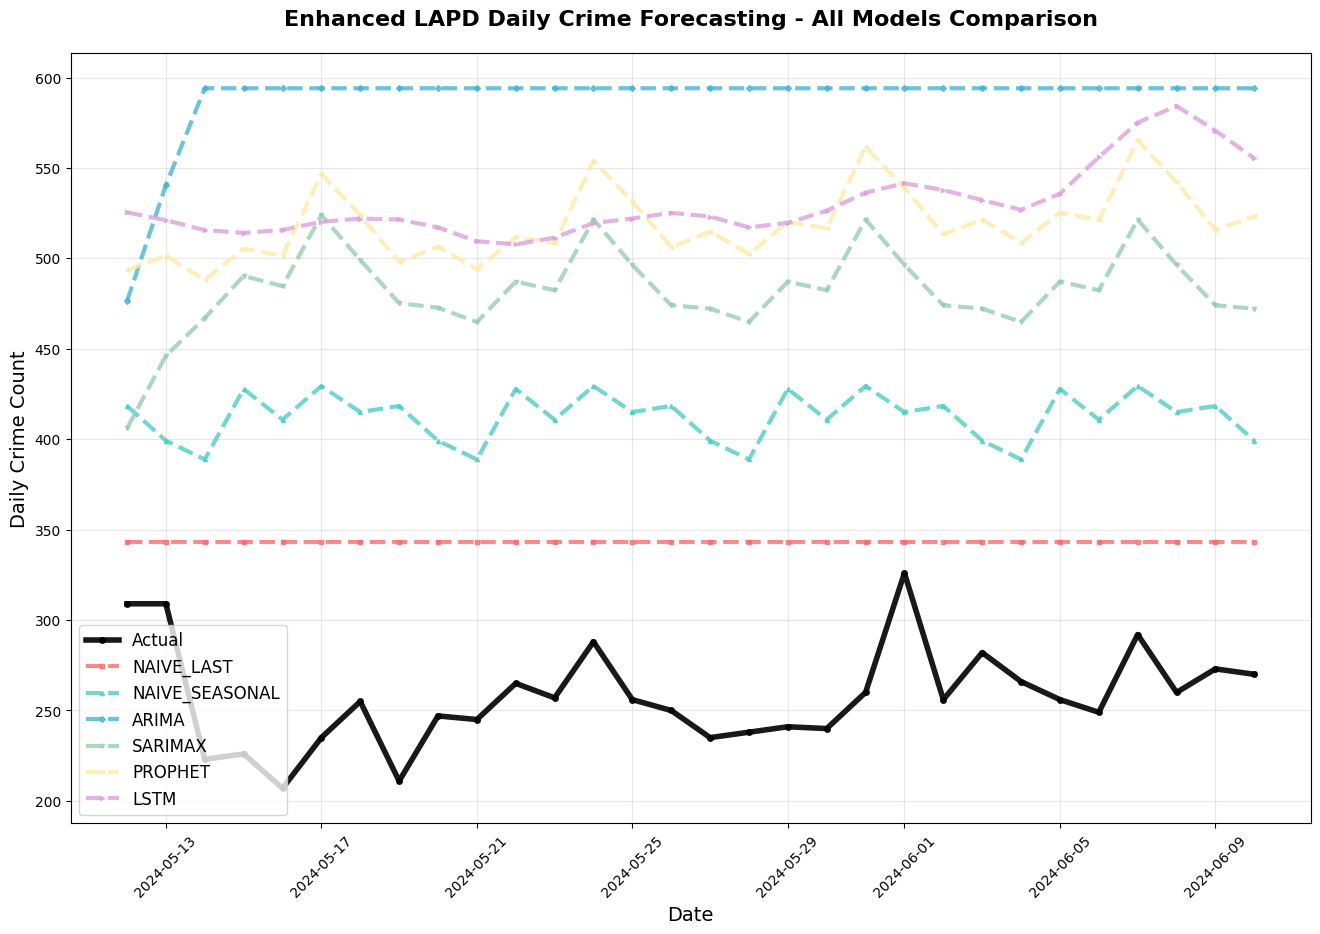

In [52]:

# ------------------------------ Main Execution ----------------------------
if __name__ == "__main__":
    print("🚀 Starting Enhanced LAPD Crime Forecasting...")

    RAW_PATH = "/content/Crime_Data_from_2020_to_Present.csv.zip"

    result = run_enhanced_lapd_forecasting(
        df_or_path=RAW_PATH,
        out_dir="/content/figs_ts_enhanced",
        horizon=30,
        eval_days=365,  # Full year evaluation
        rolling_splits=5,  # More robust CV
        run_models=["naive_last", "naive_seasonal", "arima", "sarimax", "prophet", "lstm"],
        cv_strategy="expanding",
        rolling_train_days=None,
        do_gridsearch=True,
        verbose=True
    )

    if result:
        print("\n✅ Enhanced forecasting completed successfully!")
        print(f"📈 Best performing model: {result['metrics_summary'].iloc[0]['model'].upper()}")
        print(f"📁 Results saved in: {result['paths']['charts']}")
    else:
        print("❌ Forecasting failed!")

# Additional utility functions for analysis
def analyze_residuals(actual, predicted, model_name):
    """Analyze residuals for model diagnostics"""
    residuals = actual - predicted

    plt.figure(figsize=(15, 10))

    # Residuals plot
    plt.subplot(2, 2, 1)
    plt.plot(residuals, marker='o', alpha=0.7)
    plt.title(f'{model_name} - Residuals Over Time')
    plt.xlabel('Time')
    plt.ylabel('Residuals')
    plt.grid(True, alpha=0.3)

    # Histogram of residuals
    plt.subplot(2, 2, 2)
    plt.hist(residuals, bins=20, alpha=0.7, edgecolor='black')
    plt.title(f'{model_name} - Residuals Distribution')
    plt.xlabel('Residual Value')
    plt.ylabel('Frequency')
    plt.grid(True, alpha=0.3)

    # Q-Q plot (if scipy available)
    try:
        from scipy import stats
        plt.subplot(2, 2, 3)
        stats.probplot(residuals, dist="norm", plot=plt)
        plt.title(f'{model_name} - Q-Q Plot')
        plt.grid(True, alpha=0.3)
    except ImportError:
        pass

    # Actual vs Predicted scatter
    plt.subplot(2, 2, 4)
    plt.scatter(actual, predicted, alpha=0.7)
    plt.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 'r--', lw=2)
    plt.title(f'{model_name} - Actual vs Predicted')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    return plt

def feature_importance_analysis(y, lookback=90):
    """Analyze which features are most important for prediction"""
    features_df = _add_time_features(y)
    features_df = features_df.fillna(method='bfill').fillna(method='ffill')

    # Simple correlation analysis
    correlations = features_df.corr()['crime_count'].abs().sort_values(ascending=False)

    print("🔍 Feature Importance (Correlation with Crime Count):")
    for feature, corr in correlations.head(10).items():
        if feature != 'crime_count':
            print(f"  {feature}: {corr:.3f}")

    return correlations

ideas to add to the report:
they aren't updated to the latest results!!!

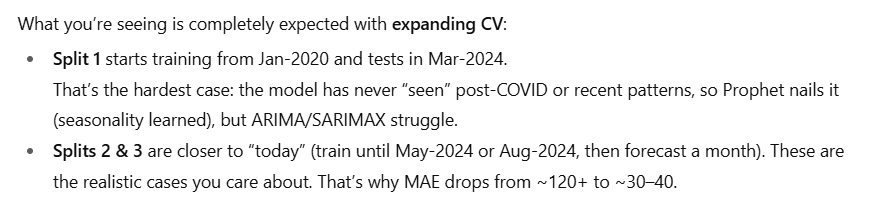